In [5]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit


In [6]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [9]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [11]:
def hybrid_ernn_loss(y, e_hybrid, sigma, tau):
    """
    Hybrid ERNN AGD NLL Loss
    y        : observed returns (tensor), shape (T,)
    e_hybrid : hybrid expectile estimate (tensor), shape (T,)
               = psi * CARE_component + (1-psi) * FNN_component
    sigma    : scale parameter (scalar)
    tau      : expectile level in (0,1)
    """
    diff = y - e_hybrid
    omega = torch.abs(tau - (diff < 0).float()) * diff**2
    nll = (torch.log(sigma)
           + torch.log(torch.sqrt(torch.tensor(torch.pi / tau))
                       + torch.sqrt(torch.tensor(torch.pi / (1 - tau))))
           - torch.log(torch.tensor(2.0))
           + omega / sigma**2)
    return nll.mean()


def compute_hybrid_location_self_si(y, X, gamma1, gamma2, gamma3, fnn_model, psi):
    """
    Self-lagged hybrid ERNN location -- SI (self-interaction) functional form.
    The CARE component uses the previous pure CARE output as its autoregressive input.
    SI form: e_t = gamma1 * e_{t-1} + gamma2 * |y_{t-1}| + gamma3 * e_{t-1} * |y_{t-1}|

    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    gamma1 : expectile persistence, constrained to (0,1)
    gamma2 : magnitude impact, constrained to >0
    gamma3 : interaction term, constrained to >0
    psi    : mixing weight, constrained to (0,1)
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)  # shape (T,)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CARE component -- SI self-lagged
        abs_y    = torch.abs(y[t-1])
        care_t   = (gamma1 * e_care_list[t-1]
                  + gamma2 * abs_y
                  + gamma3 * e_care_list[t-1] * abs_y)
        e_care_list.append(care_t)

        # Hybrid combination
        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care

In [13]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

## TUning

In [12]:
def compute_hybrid_location_self_si(y, X, gamma1, gamma2, gamma3, fnn_model, psi):
    """
    Self-lagged hybrid ERNN location -- SI (self-interaction) functional form.
    The CARE component uses the previous pure CARE output as its autoregressive input.
    SI form: e_t = gamma1 * e_{t-1} + gamma2 * |y_{t-1}| + gamma3 * e_{t-1} * |y_{t-1}|
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        abs_y  = torch.abs(y[t-1])
        care_t = (gamma1 * e_care_list[t-1]
                + gamma2 * abs_y
                + gamma3 * e_care_list[t-1] * abs_y)
        e_care_list.append(care_t)

        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care


class HybridERNN_SI(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))
        self.gamma3_raw = nn.Parameter(torch.tensor(0.3))     # interaction term
        self.psi_raw    = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw  = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = torch.nn.functional.softplus(self.gamma2_raw)
        gamma3 = torch.nn.functional.softplus(self.gamma3_raw)
        psi    = torch.sigmoid(self.psi_raw)
        sigma  = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged SI: uses previous pure CARE output
        e_hybrid, e_care = compute_hybrid_location_self_si(
            y, X, gamma1, gamma2, gamma3, self.fnn, psi)

        return e_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective(trial, tau):
    # Optuna only tunes architecture and training hyperparameters
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridERNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        crp, crp_penalty = compute_crp(y_val, e_val, tau)

        gamma1 = torch.sigmoid(model.gamma1_raw).item()
        gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        psi    = torch.sigmoid(model.psi_raw).item()
        sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('gamma1',      gamma1)
    trial.set_user_attr('gamma2',      gamma2)
    trial.set_user_attr('gamma3',      gamma3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"tau={tau} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"gamma1={gamma1:.4f} | gamma2={gamma2:.4f} | gamma3={gamma3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    """
    Rank all completed trials by NLL and CRP_penalty separately.
    Select trial with lowest sum of ranks.
    Tiebreak: raw NLL, then raw CRP_penalty, then trial number.
    """
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each tau level
# -------------------------
tau_levels           = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed            = 2026
best_configs_ernn_si_self = {}  # distinct name for SI self-lagged

for i, tau in enumerate(tau_levels):
    print(f"\n{'='*60}")
    print(f"Tuning ERNN SI Self-lagged for tau = {tau} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, t=tau: objective(trial, tau=t),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for tau={tau}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'tau':         tau,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'gamma1':      t.user_attrs['gamma1'],
            'gamma2':      t.user_attrs['gamma2'],
            'gamma3':      t.user_attrs['gamma3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'ernn_si_self_ranking_tau_{tau}.csv', index=False)
    print(f"  Full ranking saved to ernn_si_self_ranking_tau_{tau}.csv")

    best_configs_ernn_si_self[tau] = best_trial.params.copy()
    best_configs_ernn_si_self[tau]['tau'] = tau

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridERNN_SI(X_train.shape[1], best_configs_ernn_si_self[tau])

    if best_configs_ernn_si_self[tau]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_ernn_si_self[tau]['lr'],
                                     weight_decay=best_configs_ernn_si_self[tau]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_ernn_si_self[tau]['lr'],
                                      weight_decay=best_configs_ernn_si_self[tau]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_ernn_si_self[tau]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            e_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_ernn_si_self[tau].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_ernn_loss(y_val, e_val_final, sigma_val_final, tau).item()
        final_crp, final_crp_penalty = compute_crp(y_val, e_val_final, tau)

        est_gamma1 = torch.sigmoid(best_model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(best_model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(best_model.gamma3_raw).item()
        est_psi    = torch.sigmoid(best_model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_ernn_si_self[tau]['est_psi']    = est_psi
    best_configs_ernn_si_self[tau]['est_sigma']  = est_sigma
    best_configs_ernn_si_self[tau]['est_gamma1'] = est_gamma1
    best_configs_ernn_si_self[tau]['est_gamma2'] = est_gamma2
    best_configs_ernn_si_self[tau]['est_gamma3'] = est_gamma3
    best_configs_ernn_si_self[tau]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:    {est_psi:.4f}")
    print(f"Estimated sigma:  {est_sigma:.4f}")
    print(f"Estimated gamma1: {est_gamma1:.4f}")
    print(f"Estimated gamma2: {est_gamma2:.4f}")
    print(f"Estimated gamma3: {est_gamma3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- ERNN SI SELF-LAGGED")
print("="*60)
for tau, config in best_configs_ernn_si_self.items():
    print(f"tau={tau}: {config}")

[I 2026-07-07 00:27:28,556] A new study created in memory with name: no-name-0ce8e979-bb09-45a3-b00d-83e95d89cdeb



Tuning ERNN SI Self-lagged for tau = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=1.8465 | CRP=0.1766 | CRP_penalty=0.6780 | tau=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | gamma1=0.7998 | gamma2=0.8540 | gamma3=0.8540
[I 2026-07-07 00:27:32,144] Trial 0 finished with value: 1.8464511632919312 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 1.8464511632919312.
  Trial 1: NLL=1.8299 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5063 | sigma=0.9548 | gamma1=0.7985 | gamma2=0.8483 | gamma3=0.8462
[I 2026-07-07 00:27:50,329] Trial 1 finished with value: 1.8299404382705688 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'laye

[I 2026-07-07 01:26:12,590] A new study created in memory with name: no-name-d5d46aac-2ea5-4c30-9d2c-43341d26739b


...

  Trial 0: NLL=0.4225 | CRP=0.2208 | CRP_penalty=0.6072 | tau=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5152 | sigma=0.3128 | gamma1=0.7705 | gamma2=0.7163 | gamma3=0.6575
[I 2026-07-07 14:35:48,951] Trial 0 finished with value: 0.4225331246852875 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 0.4225331246852875.
  Trial 1: NLL=0.7172 | CRP=0.6181 | CRP_penalty=0.1458 | tau=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5149 | sigma=0.4202 | gamma1=0.7855 | gamma2=0.7878 | gamma3=0.7431
[I 2026-07-07 14:36:09,123] Trial 1 finished with value: 0.7171754837036133 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 

[I 2026-07-10 00:48:20,868] A new study created in memory with name: no-name-2f5b81a6-d6b7-4b71-8a65-dab210769f49



Best trial (rank-based): #176
  NLL rank: 10 | CRP rank: 4 | Sum: 14
Final NLL:          -2.4179
Final CRP:          1.0596
Final CRP penalty:  0.0036
Best params: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.039061295713491206, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.04554288942227808, 'optimizer': 'adamw', 'batch_size': 128, 'weight_decay': 6.393990744853923e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 145}
Estimated psi:    0.7382
Estimated sigma:  0.0135
Estimated gamma1: 0.6046
Estimated gamma2: 0.0897
Estimated gamma3: 0.1361

Tuning ERNN SI Self-lagged for tau = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=0.6325 | CRP=2.1192 | CRP_penalty=1.2526 | tau=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5177 | sigma=0.2892 | gamma1=0.7521 | gamma2=0.6977 | gamma3=0.6279
[I 2026-07-10 00:48:43,052] Trial 0 finished with value: 0.6325122714042664 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 0.6325122714042664.
  Trial 1: NLL=1.8292 | CRP=3.6203 | CRP_penalty=6.8660 | tau=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5019 | sigma=0.9572 | gamma1=0.8009 | gamma2=0.8579 | gamma3=0.8569
[I 2026-07-10 00:49:03,325] Trial 1 finished with value: 1.829203724861145 and parameters: {'n_hidden_layers': 1, 'activation': 'e


Training final model for tau = 0.025 (SI self-lagged)
  Epoch 50: train=0.0493, val=-0.0005
  Epoch 100: train=-1.7716, val=-1.9995
  Epoch 150: train=-2.0573, val=-2.3119
  Early stopping at epoch 198
  Test loss: -2.4564 | gamma1=0.4005 | gamma2=0.0889 | gamma3=0.1621 | psi=0.7285 | sigma=0.0115

Training final model for tau = 0.05 (SI self-lagged)
  Epoch 50: train=-0.3273, val=-0.3776
  Epoch 100: train=-1.7803, val=-1.9560
  Epoch 150: train=-2.1672, val=-2.3605
  Epoch 200: train=-2.2173, val=-2.3857
  Test loss: -2.4850 | gamma1=0.3725 | gamma2=0.0700 | gamma3=0.1131 | psi=0.9192 | sigma=0.0136

Training final model for tau = 0.25 (SI self-lagged)
  Epoch 50: train=-0.4327, val=-0.4872
  Epoch 100: train=-1.7862, val=-1.8900
  Epoch 150: train=-2.1084, val=-2.2908
  Epoch 200: train=-2.0371, val=-2.5464
  Test loss: -2.6517 | gamma1=0.4846 | gamma2=0.1135 | gamma3=0.1708 | psi=0.7585 | sigma=0.0215

Training final model for tau = 0.5 (SI self-lagged)
  Epoch 50: train=-0.4148, 

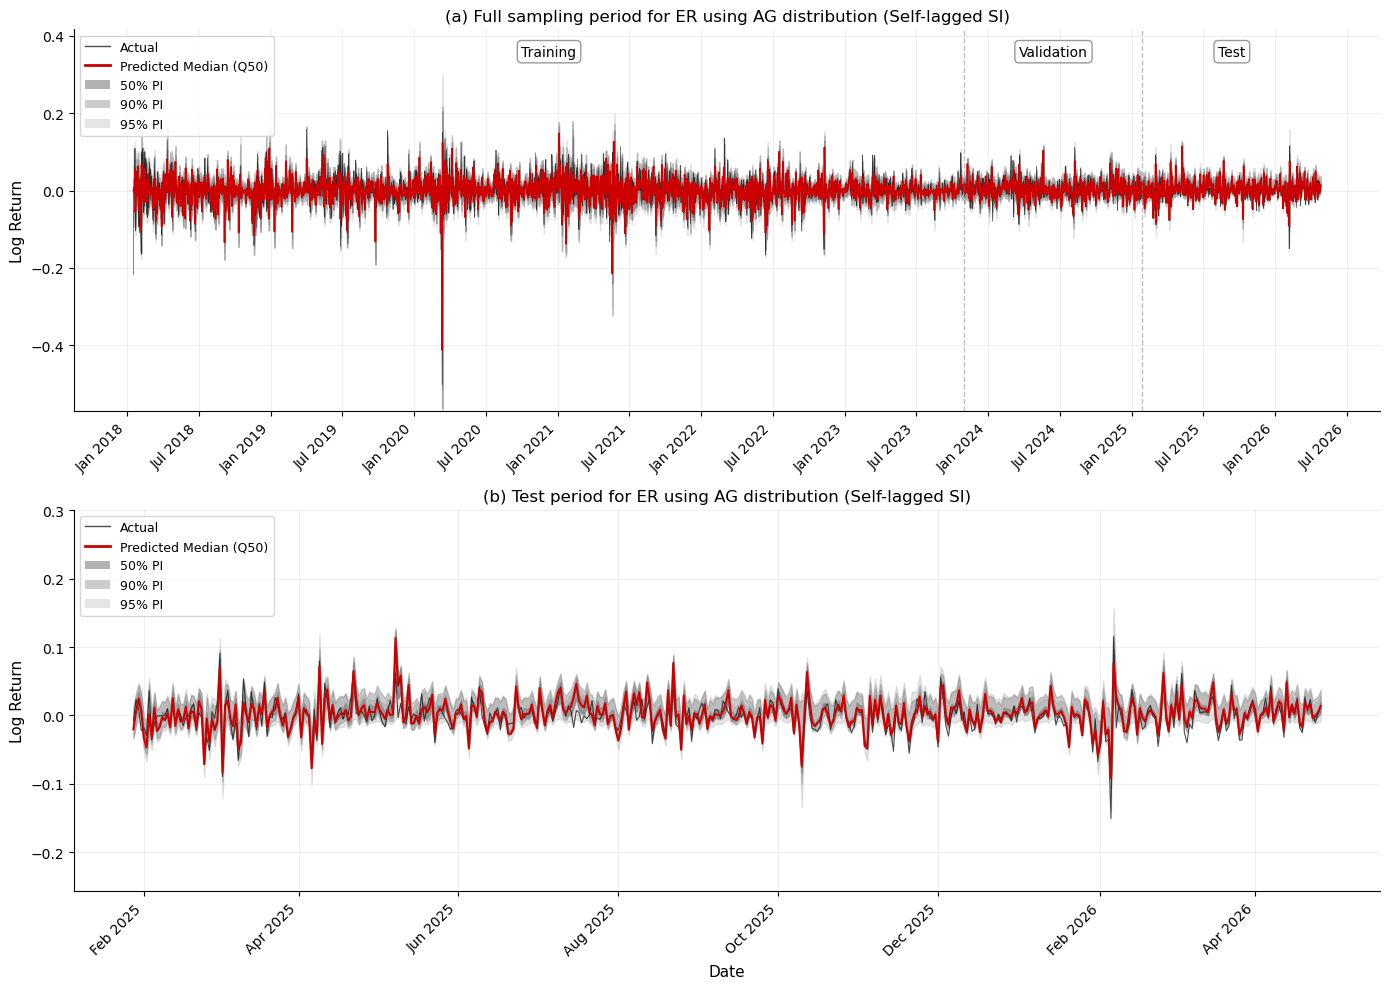

Full period plot saved to hybrid_ernn_self_si_predictions_full.png
Test period plot saved to hybrid_ernn_self_si_predictions_test.png

CROSSOVER ANALYSIS -- ERNN Self SI (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           5      1.10% <-- TAIL
  (0.050, 0.250):         118     25.99%
  (0.250, 0.500):          86     18.94%
  (0.500, 0.750):           0      0.00%
  (0.750, 0.950):           2      0.44%
  (0.950, 0.975):         229     50.44% <-- TAIL
  ------------------------------------------
  Total violations:         440  (16.15% of all pairs)
  Tail violations:          234  (25.77% of tail pairs)


In [14]:
def train_final_model_ernn_si(tau, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridERNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        e_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_ernn_loss(y_test, e_test, sigma_test, tau)

    with torch.no_grad():
        est_gamma1 = torch.sigmoid(model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        est_psi    = torch.sigmoid(model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | "
          f"gamma1={est_gamma1:.4f} | gamma2={est_gamma2:.4f} | "
          f"gamma3={est_gamma3:.4f} | psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'ernn_si_self_history_tau_{tau}.csv', index=False)

    return model, train_losses, val_losses, e_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all tau levels
# -------------------------
tau_levels           = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_ernn_si_self = {}

for tau in tau_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for tau = {tau} (SI self-lagged)")
    print(f"{'='*60}")
    config = best_configs_ernn_si_self[tau]
    model, train_losses, val_losses, e_test_pred = train_final_model_ernn_si(
        tau, config, y_train, X_train, y_val, X_val, y_test, X_test)
    results_ernn_si_self[tau] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'e_test':       e_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel(results, train_df, val_df, test_df, tau_levels, feature_cols,
                   title_suffix='ER using AG distribution (Self-lagged SI)',
                   save_fname='hybrid_ernn_self_si_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()
        with torch.no_grad():
            e_all, _ = model(y_all, X_all)
            all_preds[tau] = e_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- SI self-lagged
# -------------------------
all_preds_ernn_si_self, train_size, val_size = plot_two_panel(
    results_ernn_si_self, train_df, val_df, test_df, tau_levels, feature_cols,
    title_suffix='ER using AG distribution (Self-lagged SI)',
    save_fname='hybrid_ernn_self_si_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='ERNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_ernn_si_self, tau_levels, train_size, val_size,
    model_name='ERNN Self SI'
)

In [16]:
import numpy as np


def compute_ase(y_true, e_pred, tau):
    """
    Asymmetric Squared Error for expectile evaluation.
    ASE = mean(|tau - 1(y < e_hat)| * (y - e_hat)^2)
    """
    y         = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    e         = e_pred if isinstance(e_pred, np.ndarray) else np.array(e_pred)
    indicator = (y < e).astype(float)
    ase       = np.mean(np.abs(tau - indicator) * (y - e)**2)
    return ase


def compute_test_metrics_ernn(results, tau_levels, y_test, X_test, model_name='ERNN'):
    """
    Compute average NLL and ASE on test set across all tau levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'tau':>6} {'NLL':>10} {'ASE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    ase_list = []

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()

        with torch.no_grad():
            e_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_ernn_loss(y_test, e_test, sigma_test, tau).item()

        e_test_np = e_test.numpy()
        y_test_np = y_test.numpy()

        ase = compute_ase(y_test_np, e_test_np, tau)

        nll_list.append(test_nll)
        ase_list.append(ase)

        print(f"  {tau:>6} {test_nll:>10.4f} {ase:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(ase_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average ASE: {np.mean(ase_list):.6f}")

    return np.mean(nll_list), np.mean(ase_list)


# -------------------------
# Test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

tau_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- ERNN SI self-lagged
# -------------------------
avg_nll_ernn_si_self, avg_ase_ernn_si_self = compute_test_metrics_ernn(
    results_ernn_si_self, tau_levels, y_test, X_test,
    model_name='ERNN SI Self-lagged'
)


TEST SET METRICS -- ERNN SI Self-lagged
     tau        NLL            ASE
  ----------------------------------
   0.025    -2.4564       0.000018
    0.05    -2.4850       0.000042
    0.25    -2.6517       0.000074
     0.5    -2.7248       0.000089
    0.75    -2.6550       0.000074
    0.95    -2.4481       0.000050
   0.975    -2.4644       0.000026
  ----------------------------------
    Mean    -2.5551       0.000053

  --> Average NLL: -2.5551
  --> Average ASE: 0.000053


# Cross over dealing

In [19]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Joint ERNN SI Self-lagged
# One model estimates all seven expectile levels
# ============================================================

tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]


class HybridERNN_SI_Self_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(tau_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets
        self.gamma1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )
        self.gamma2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.gamma3_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']

            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(config['dropout'])
                )

            prev_dim = hidden_dim

        # Median expectile plus six raw spacings
        layers.append(
            nn.Linear(prev_dim, self.n_levels)
        )

        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_expectiles(self, raw_fnn):
        median = raw_fnn[:, 0]
        delta = (
            F.softplus(raw_fnn[:, 1:])
            + self.eps
        )

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        return torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

    def forward(
        self,
        y,
        X,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )
        gamma2 = F.softplus(
            self.gamma2_raw
        )
        gamma3 = F.softplus(
            self.gamma3_raw
        )
        psi = torch.sigmoid(
            self.psi_raw
        )
        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        raw_fnn = self.fnn(X)

        fnn_expectiles = (
            self.reconstruct_fnn_expectiles(
                raw_fnn
            )
        )

        e_hybrid, e_care = (
            compute_hybrid_location_self_si_joint(
                y=y,
                fnn_expectiles=fnn_expectiles,
                gamma1=gamma1,
                gamma2=gamma2,
                gamma3=gamma3,
                psi=psi,
                initial_care=initial_care,
                initial_y=initial_y
            )
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            fnn_expectiles
        )


def compute_hybrid_location_self_si_joint(
    y,
    fnn_expectiles,
    gamma1,
    gamma2,
    gamma3,
    psi,
    initial_care=None,
    initial_y=None
):
    """
    Self-lagged self-interaction CARE recursion:

    e^S_{k,t}
    = gamma1_k e^S_{k,t-1}
    + gamma2_k |y_{t-1}|
    + gamma3_k e^S_{k,t-1}|y_{t-1}|

    e^H_{k,t}
    = psi_k e^S_{k,t}
    + (1-psi_k) f_{k,t}
    """
    T = len(y)
    n_levels = fnn_expectiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    e_hybrid_list = []
    e_care_list = []

    has_initial_state = (
        initial_care is not None
        and initial_y is not None
    )

    if (
        (initial_care is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_care and initial_y '
            'must be supplied together.'
        )

    previous_care = (
        initial_care
        if has_initial_state
        else zero_row
    )

    for t in range(T):
        if t == 0 and not has_initial_state:
            e_care_list.append(zero_row)
            e_hybrid_list.append(zero_row)
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        abs_y = torch.abs(previous_y)

        care_t = (
            gamma1 * previous_care
            + gamma2 * abs_y
            + gamma3 * previous_care * abs_y
        )

        hybrid_t = (
            psi * care_t
            + (1 - psi) * fnn_expectiles[t]
        )

        e_care_list.append(care_t)
        e_hybrid_list.append(hybrid_t)

        # Self-lagged: use previous pure CARE output
        previous_care = care_t

    e_care = torch.stack(
        e_care_list,
        dim=0
    )
    e_hybrid = torch.stack(
        e_hybrid_list,
        dim=0
    )

    return e_hybrid, e_care


# ============================================================
# Joint AGD loss, ASE and crossover
# ============================================================

def hybrid_ernn_joint_loss(
    y,
    e_hybrid,
    sigma,
    levels=tau_levels
):
    """
    Average AGD negative log-likelihood across
    all observations and seven expectile levels.
    """
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )
    omega = weight * u.pow(2)

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau
            )
            + torch.sqrt(
                torch.pi / (1 - tau)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + omega / sigma.pow(2).unsqueeze(0)
    )

    return nll.mean()


def compute_ase_joint(
    y,
    e_hybrid,
    levels=tau_levels
):
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )

    ase_by_level = (
        weight * u.pow(2)
    ).mean(dim=0)

    return (
        ase_by_level,
        ase_by_level.mean()
    )


def compute_crossover_joint(e_hybrid):
    violations = (
        e_hybrid[:, :-1]
        > e_hybrid[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    T = len(e_hybrid)

    total_count = int(
        pair_counts.sum().item()
    )
    total_rate = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x)
            for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate': total_rate,
        'tail_count': tail_count,
        'tail_rate': tail_rate
    }


# ============================================================
# Fit one joint model
# ============================================================

def fit_joint_ernn_si_self(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridERNN_SI_Self_Joint(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        e_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        # t=0 is only the initialisation row
        train_loss = hybrid_ernn_joint_loss(
            y_train[1:],
            e_train[1:],
            sigma
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Continue validation from training CARE state
        model.eval()
        with torch.no_grad():
            _, sigma_val, care_train, _ = model(
                y_train,
                X_train
            )

            e_val, _, _, _ = model(
                y_val,
                X_val,
                initial_care=care_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_ernn_joint_loss(
                y_val,
                e_val,
                sigma_val
            )

        scheduler.step(
            val_loss.item()
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


def evaluate_joint_ernn_si_self(model):
    model.eval()

    with torch.no_grad():
        _, sigma, care_train, _ = model(
            y_train,
            X_train
        )

        e_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_care=care_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_ernn_joint_loss(
            y_val,
            e_val,
            sigma
        ).item()

        ase_levels, mean_ase = (
            compute_ase_joint(
                y_val,
                e_val
            )
        )

        final_cross = (
            compute_crossover_joint(e_val)
        )
        fnn_cross = (
            compute_crossover_joint(fnn_val)
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        )
        gamma2 = F.softplus(
            model.gamma2_raw
        )
        gamma3 = F.softplus(
            model.gamma3_raw
        )
        psi = torch.sigmoid(
            model.psi_raw
        )
        sigma = (
            F.softplus(model.sigma_raw)
            + model.eps
        )

    return {
        'mean_nll': mean_nll,
        'ase_by_level': ase_levels.tolist(),
        'mean_ase': mean_ase.item(),
        'final_crossover': final_cross,
        'fnn_crossover': fnn_cross,
        'gamma1': gamma1.tolist(),
        'gamma2': gamma2.tolist(),
        'gamma3': gamma3.tolist(),
        'psi': psi.tolist(),
        'sigma': sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_ernn_si_self_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    model = fit_joint_ernn_si_self(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_ernn_si_self(
        model
    )

    for name in [
        'mean_nll',
        'mean_ase',
        'ase_by_level',
        'gamma1',
        'gamma2',
        'gamma3',
        'psi',
        'sigma'
    ]:
        trial.set_user_attr(
            name,
            metrics[name]
        )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['mean_nll']:.6f} | "
        f"ASE={metrics['mean_ase']:.8f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Search is guided by validation NLL.
    # Final selection uses NLL rank + ASE rank.
    return metrics['mean_nll']


# ============================================================
# Rank by validation NLL and ASE
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if (
            t.state
            == optuna.trial.TrialState.COMPLETE
            and t.value is not None
            and np.isfinite(t.value)
            and 'mean_nll' in t.user_attrs
            and 'mean_ase' in t.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._ase = t.user_attrs['mean_ase']

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._nll
        ),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._ase
        ),
        start=1
    ):
        t._rank_ase = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_ase,
            t._nll,
            t._ase,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one 800-trial joint study
# ============================================================

print('\n' + '=' * 70)
print(
    'Tuning Joint ERNN SI Self-lagged '
    'for all seven tau levels'
)
print('=' * 70)

sampler = TPESampler(seed=2026)

study_ernn_si_self_joint = (
    optuna.create_study(
        direction='minimize',
        sampler=sampler
    )
)

study_ernn_si_self_joint.optimize(
    objective_ernn_si_self_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial_ernn_si_self, all_trials_ernn_si_self = (
    select_best_trial_by_rank_joint(
        study_ernn_si_self_joint
    )
)


# ============================================================
# Save trial ranking
# ============================================================

ranking_records = []

for t in all_trials_ernn_si_self:
    record = {
        'trial': t.number,
        'mean_nll': t._nll,
        'mean_ase': t._ase,
        'rank_nll': t._rank_nll,
        'rank_ase': t._rank_ase,
        'sum_rank': (
            t._rank_nll + t._rank_ase
        ),
        'final_crossover_count':
            t.user_attrs[
                'final_crossover_count'
            ],
        'final_crossover_rate':
            t.user_attrs[
                'final_crossover_rate'
            ],
        'tail_crossover_count':
            t.user_attrs[
                'tail_crossover_count'
            ],
        'tail_crossover_rate':
            t.user_attrs[
                'tail_crossover_rate'
            ],
        'fnn_crossover_count':
            t.user_attrs[
                'fnn_crossover_count'
            ]
    }

    for k, tau in enumerate(tau_levels):
        suffix = f'tau_{tau}'

        record[f'ase_{suffix}'] = (
            t.user_attrs['ase_by_level'][k]
        )
        record[f'gamma1_{suffix}'] = (
            t.user_attrs['gamma1'][k]
        )
        record[f'gamma2_{suffix}'] = (
            t.user_attrs['gamma2'][k]
        )
        record[f'gamma3_{suffix}'] = (
            t.user_attrs['gamma3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df_ernn_si_self = pd.DataFrame(
    ranking_records
)

ranking_df_ernn_si_self = (
    ranking_df_ernn_si_self.sort_values(
        ['sum_rank', 'mean_nll', 'mean_ase']
    )
)

ranking_df_ernn_si_self.to_csv(
    'joint_ernn_si_self_ranking.csv',
    index=False
)


# ============================================================
# Refit and save selected model
# ============================================================

best_config_ernn_si_self = (
    best_trial_ernn_si_self.params.copy()
)

best_model_ernn_si_self_joint = (
    fit_joint_ernn_si_self(
        config=best_config_ernn_si_self,
        max_epochs=200,
        seed=2026
    )
)

best_metrics_ernn_si_self_joint = (
    evaluate_joint_ernn_si_self(
        best_model_ernn_si_self_joint
    )
)

torch.save(
    {
        'model_state_dict':
            best_model_ernn_si_self_joint.state_dict(),
        'config':
            best_config_ernn_si_self,
        'tau_levels':
            tau_levels,
        'validation_metrics':
            best_metrics_ernn_si_self_joint
    },
    'joint_ernn_si_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- JOINT ERNN SI SELF-LAGGED')
print('=' * 70)
print(
    f'Best trial: {best_trial_ernn_si_self.number}'
)
print(
    f"Validation NLL: "
    f"{best_metrics_ernn_si_self_joint['mean_nll']:.6f}"
)
print(
    f"Validation ASE: "
    f"{best_metrics_ernn_si_self_joint['mean_ase']:.8f}"
)
print(
    f"Final hybrid crossover: "
    f"{best_metrics_ernn_si_self_joint['final_crossover']['total_count']} "
    f"("
    f"{best_metrics_ernn_si_self_joint['final_crossover']['total_rate']:.2%}"
    f")"
)
print(
    f"Tail crossover: "
    f"{best_metrics_ernn_si_self_joint['final_crossover']['tail_count']} "
    f"("
    f"{best_metrics_ernn_si_self_joint['final_crossover']['tail_rate']:.2%}"
    f")"
)
print(
    f"FNN crossover count: "
    f"{best_metrics_ernn_si_self_joint['fnn_crossover']['total_count']}"
)
print(
    f'Best architecture: {best_config_ernn_si_self}'
)

[I 2026-07-28 14:03:07,539] A new study created in memory with name: no-name-ee9d4457-59df-4fd8-97f6-944bc7001c8d



Tuning Joint ERNN SI Self-lagged for all seven tau levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.301424 | ASE=0.00233009 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-28 14:03:29,589] Trial 0 finished with value: 1.3014237880706787 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3014237880706787.
Trial 1: NLL=0.266581 | ASE=0.00018905 | Final crossover=0.15% | FNN crossover=0.00%
[I 2026-07-28 14:03:50,107] Trial 1 finished with value: 0.2665809392929077 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2665809392929077.
Trial 2: NLL=1.3805

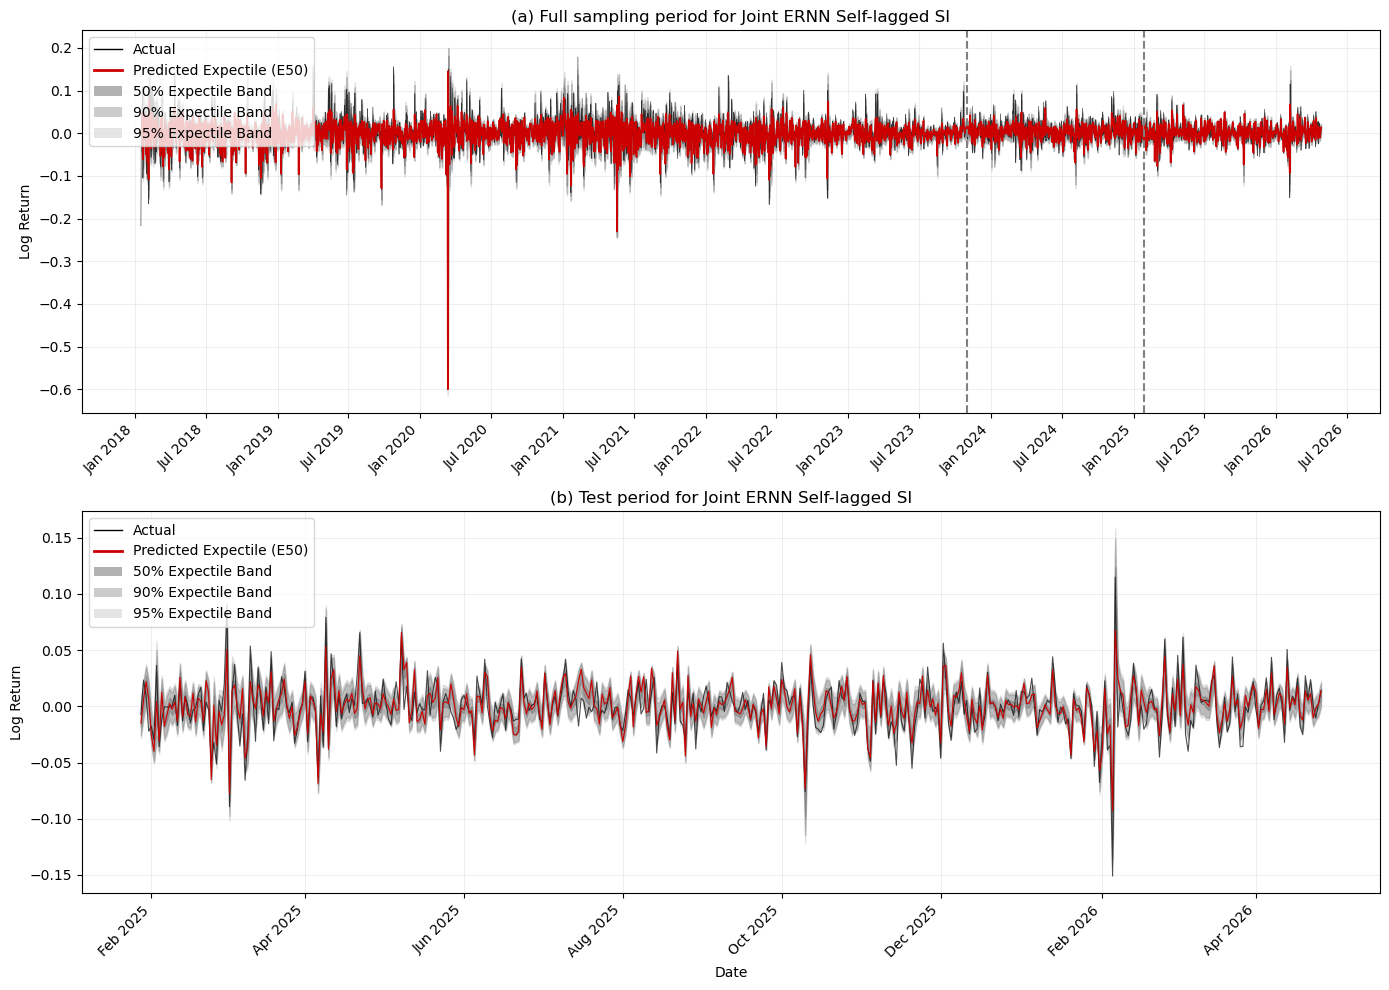

Plot saved to hybrid_ernn_self_si_joint_predictions.png

TEST METRICS -- JOINT ERNN SI SELF-LAGGED
       tau         NLL        ASE
0.02500000 -2.62879062 0.00001586
0.05000000 -2.66488481 0.00002613
0.25000000 -2.71359158 0.00007122
0.50000000 -2.72503877 0.00008054
0.75000000 -2.79896092 0.00005905
0.95000000 -2.73043776 0.00002295
0.97500000 -2.67986035 0.00001446

Average NLL: -2.705938
Average ASE: 0.00004146

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 25 (5.51%)
(0.500, 0.750): 14 (3.08%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 3 (0.66%) <-- TAIL

Total violations: 42 (1.54%)
Tail violations: 3 (0.33%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint ERNN SI Self-lagged -- plotting and test evaluation
# Run directly after the ERNN self-lagged tuning code
# ============================================================

X_test_e = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_e = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_ernn_si_self_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    e_train, sigma, care_train, fnn_train = model(
        y_train,
        X_train
    )

    e_val, _, care_val, fnn_val = model(
        y_val,
        X_val,
        initial_care=care_train[-1],
        initial_y=y_train[-1]
    )

    e_test, _, _, fnn_test = model(
        y_test_e,
        X_test_e,
        initial_care=care_val[-1],
        initial_y=y_val[-1]
    )

e_train_np = e_train.numpy()
e_val_np   = e_val.numpy()
e_test_np  = e_test.numpy()

e_all = np.concatenate(
    [e_train_np, e_val_np, e_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

all_preds_ernn_si_self = {
    tau: e_all[:, k]
    for k, tau in enumerate(tau_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_ernn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_ernn_self_si_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Expectile (E50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% Expectile Band'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint ERNN Self-lagged SI'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint ERNN Self-lagged SI'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_ernn_joint(
    all_preds_ernn_si_self,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and ASE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    e_test,
    sigma,
    tau_levels
):
    records = []

    for k, tau in enumerate(tau_levels):
        y = y_test
        e = e_test[:, k]
        sigma_k = sigma[k]

        u = y - e
        weight = torch.abs(
            torch.tensor(tau)
            - (u < 0).float()
        )
        omega = weight * u.pow(2)

        constant = (
            np.log(
                np.sqrt(np.pi / tau)
                + np.sqrt(np.pi / (1 - tau))
            )
            - np.log(2.0)
        )

        nll = (
            torch.log(sigma_k)
            + constant
            + omega / sigma_k.pow(2)
        ).mean().item()

        ase = omega.mean().item()

        records.append({
            'tau': tau,
            'NLL': nll,
            'ASE': ase
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT ERNN SI SELF-LAGGED')
    print('=' * 60)
    print(
        results.to_string(
            index=False,
            float_format=lambda x: f'{x:.8f}'
        )
    )
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average ASE: {results['ASE'].mean():.8f}")

    results.to_csv(
        'joint_ernn_si_self_test_metrics.csv',
        index=False
    )

    return results


test_metrics_ernn_si_self = compute_test_metrics_joint(
    y_test_e,
    e_test,
    sigma,
    tau_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    e_pred,
    levels,
    model_name
):
    e = e_pred.numpy()
    T = len(e)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(e[:, k] > e[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    e_test,
    tau_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    tau_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 1b


In [22]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT ERNN SI Self-LAGGED
# Complete-output non-crossing through positive adjacent spacing
# ============================================================

M1B_DISTRIBUTION = 'ernn'   # 'qrnn' or 'ernn'
M1B_FORM = 'si'           # 's' or 'si'
M1B_LAG = 'self'             # 'self' or 'cross'
M1B_N_TRIALS = 800
M1B_MAX_EPOCHS = 800
M1B_BASE_SEED = 2026

m1b_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
m1b_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67',
]
m1b_model_tag = (
    f'method1b_joint_{M1B_DISTRIBUTION}_{M1B_FORM}_{M1B_LAG}'
)


def m1b_validate_inputs():
    required = ('y_train', 'X_train', 'y_val', 'X_val')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            'Run the notebook data preparation first. Missing: '
            + ', '.join(missing)
        )

    for y_name, x_name in (
        ('y_train', 'X_train'),
        ('y_val', 'X_val'),
    ):
        y_value = globals()[y_name]
        x_value = globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(
            x_value, torch.Tensor
        ):
            raise TypeError(f'{y_name} and {x_name} must be tensors.')
        if y_value.ndim != 1 or x_value.ndim != 2:
            raise ValueError(f'{y_name} must be (T,) and {x_name} (T,p).')
        if len(y_value) != len(x_value):
            raise ValueError(f'{y_name} and {x_name} lengths differ.')


class Method1BJointHybrid(nn.Module):
    """Central hybrid forecast plus six jointly learned positive gaps."""

    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6

        # Identifiable statistical/mixing parameters for the median only.
        self.persistence_raw = nn.Parameter(torch.tensor(1.386))
        self.news1_raw = nn.Parameter(torch.tensor(0.3))
        if M1B_FORM == 'si':
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One loss scale per final level.
        self.sigma_raw = nn.Parameter(torch.full((7,), 0.5))

        layers = []
        previous_dim = input_dim
        for index in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{index}']
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in m1b_spacing_names
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def _activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }[name]

    def _positive_spacing(self, features, reference, name):
        spacing_input = torch.cat(
            [features, reference.unsqueeze(1)], dim=1
        )
        raw_spacing = self.spacing_heads[name](spacing_input).squeeze(1)
        return F.softplus(raw_spacing) + self.eps

    def _median_recursion(
        self,
        y,
        median_fnn,
        initial_state=None,
        initial_y=None,
    ):
        if (initial_state is None) != (initial_y is None):
            raise ValueError(
                'initial_state and initial_y must be supplied together.'
            )

        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = (
            F.softplus(self.news2_raw)
            if M1B_FORM == 'si'
            else None
        )
        psi = torch.sigmoid(self.psi_raw)

        has_state = initial_state is not None
        previous_state = (
            initial_state if has_state else y.new_zeros(())
        )

        statistical_values = []
        hybrid_values = []

        for time_index in range(len(y)):
            if time_index == 0 and not has_state:
                zero = y.new_zeros(())
                statistical_values.append(zero)
                hybrid_values.append(zero)
                continue

            previous_y = (
                initial_y if time_index == 0 else y[time_index - 1]
            )
            absolute_return = torch.abs(previous_y)

            statistical = (
                persistence * previous_state
                + news1 * absolute_return
            )
            if M1B_FORM == 'si':
                statistical = (
                    statistical
                    + news2 * previous_state * absolute_return
                )

            hybrid = psi * statistical + (1 - psi) * median_fnn[
                time_index
            ]
            statistical_values.append(statistical)
            hybrid_values.append(hybrid)

            previous_state = (
                statistical if M1B_LAG == 'self' else hybrid
            )

        return (
            torch.stack(hybrid_values),
            torch.stack(statistical_values),
        )

    def forward(
        self,
        y,
        X,
        initial_state=None,
        initial_y=None,
    ):
        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)
        median, statistical = self._median_recursion(
            y,
            median_fnn,
            initial_state=initial_state,
            initial_y=initial_y,
        )

        # Outward reconstruction; references remain attached so that
        # all seven losses jointly train the median and inner spacings.
        delta34 = self._positive_spacing(features, median, 'delta34')
        level3 = median - delta34
        delta23 = self._positive_spacing(features, level3, 'delta23')
        level2 = level3 - delta23
        delta12 = self._positive_spacing(features, level2, 'delta12')
        level1 = level2 - delta12

        delta45 = self._positive_spacing(features, median, 'delta45')
        level5 = median + delta45
        delta56 = self._positive_spacing(features, level5, 'delta56')
        level6 = level5 + delta56
        delta67 = self._positive_spacing(features, level6, 'delta67')
        level7 = level6 + delta67

        forecasts = torch.stack(
            [level1, level2, level3, median, level5, level6, level7],
            dim=1,
        )
        spacings = torch.stack(
            [delta12, delta23, delta34, delta45, delta56, delta67],
            dim=1,
        )
        sigma = F.softplus(self.sigma_raw) + self.eps
        continuation_state = (
            statistical if M1B_LAG == 'self' else median
        )
        return forecasts, sigma, continuation_state, statistical, median, spacings


def m1b_joint_nll(y, forecasts, sigma):
    levels = forecasts.new_tensor(m1b_levels)
    residual = y.unsqueeze(1) - forecasts

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(forecasts.dtype)
        check_loss = residual * (levels.unsqueeze(0) - indicator)
        nll = (
            -torch.log(levels * (1 - levels)).unsqueeze(0)
            + torch.log(sigma).unsqueeze(0)
            + check_loss / sigma.unsqueeze(0)
        )
    else:
        weight = torch.abs(
            levels.unsqueeze(0)
            - (residual < 0).to(forecasts.dtype)
        )
        constant = (
            torch.log(
                torch.sqrt(torch.pi / levels)
                + torch.sqrt(torch.pi / (1 - levels))
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma).unsqueeze(0)
            + constant.unsqueeze(0)
            + weight * residual.square() / sigma.square().unsqueeze(0)
        )

    return nll.mean()


def m1b_secondary_metric(y, forecasts):
    levels = forecasts.new_tensor(m1b_levels)
    if M1B_DISTRIBUTION == 'qrnn':
        hit_rate = (y.unsqueeze(1) <= forecasts).float().mean(dim=0)
        by_level = torch.abs(hit_rate - levels)
        return by_level, by_level.mean(), hit_rate

    residual = y.unsqueeze(1) - forecasts
    weight = torch.abs(
        levels.unsqueeze(0)
        - (residual < 0).to(forecasts.dtype)
    )
    by_level = (weight * residual.square()).mean(dim=0)
    return by_level, by_level.mean(), None


def m1b_crossover(forecasts):
    violations = forecasts[:, :-1] > forecasts[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = forecasts.shape[0]
    total = int(pair_counts.sum().item())
    tail = int(pair_counts[0].item() + pair_counts[-1].item())
    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total,
        'total_rate': total / (sample_size * 6),
        'tail_count': tail,
        'tail_rate': tail / (sample_size * 2),
    }


def m1b_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        ),
    }
    for index in range(config['n_hidden_layers']):
        config[f'hidden_dim_{index}'] = trial.suggest_int(
            f'hidden_dim_{index}', 32, 256
        )
    return config


def m1b_fit(config, max_epochs=M1B_MAX_EPOCHS, seed=M1B_BASE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = Method1BJointHybrid(X_train.shape[1], config)
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_forecasts, sigma, _, _, _, _ = model(y_train, X_train)
        train_loss = m1b_joint_nll(
            y_train[1:], train_forecasts[1:], sigma
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, train_state, _, _, _ = model(y_train, X_train)
            validation_forecasts, validation_sigma, _, _, _, _ = model(
                y_val,
                X_val,
                initial_state=train_state[-1],
                initial_y=y_train[-1],
            )
            validation_loss = m1b_joint_nll(
                y_val, validation_forecasts, validation_sigma
            )

        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss.item())
        if validation_loss.item() < best_loss:
            best_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def m1b_evaluate(model):
    model.eval()
    with torch.no_grad():
        _, _, train_state, _, _, _ = model(y_train, X_train)
        forecasts, sigma, _, _, _, spacings = model(
            y_val,
            X_val,
            initial_state=train_state[-1],
            initial_y=y_train[-1],
        )
        mean_nll = m1b_joint_nll(y_val, forecasts, sigma).item()
        by_level, secondary, hit_rate = m1b_secondary_metric(
            y_val, forecasts
        )

        metrics = {
            'mean_nll': mean_nll,
            'secondary': secondary.item(),
            'secondary_by_level': by_level.tolist(),
            'crossover': m1b_crossover(forecasts),
            'spacing_mean': spacings.mean(dim=0).tolist(),
            'spacing_min': spacings.min(dim=0).values.tolist(),
            'spacing_max': spacings.max(dim=0).values.tolist(),
            'spacing_std': spacings.std(
                dim=0, unbiased=False
            ).tolist(),
            'near_zero_count': (
                spacings <= 1e-5
            ).sum(dim=0).tolist(),
            'persistence': torch.sigmoid(
                model.persistence_raw
            ).item(),
            'news1': F.softplus(model.news1_raw).item(),
            'news2': (
                F.softplus(model.news2_raw).item()
                if M1B_FORM == 'si'
                else np.nan
            ),
            'psi': torch.sigmoid(model.psi_raw).item(),
            'sigma': (
                F.softplus(model.sigma_raw) + model.eps
            ).tolist(),
        }
        if hit_rate is not None:
            metrics['hit_rate'] = hit_rate.tolist()
        return metrics


def m1b_objective(trial):
    config = m1b_suggest_config(trial)
    model = m1b_fit(config)
    if model is None:
        return float('inf')
    metrics = m1b_evaluate(model)
    for name, value in metrics.items():
        trial.set_user_attr(name, value)
    metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
    print(
        f"Trial {trial.number}: NLL={metrics['mean_nll']:.6f} | "
        f"{metric_name}={metrics['secondary']:.8f} | "
        f"crossover={metrics['crossover']['total_rate']:.2%}"
    )
    return metrics['mean_nll']


def m1b_select_by_rank(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'secondary' in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError('No valid Method 1b trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['mean_nll'], trial.number),
    )
    secondary_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['secondary'], trial.number),
    )
    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, 1)
    }
    rank_secondary = {
        trial.number: rank
        for rank, trial in enumerate(secondary_order, 1)
    }
    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_secondary[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['secondary'],
            trial.number,
        ),
    )
    return best, trials, rank_nll, rank_secondary


m1b_validate_inputs()
print('\n' + '=' * 72)
print(
    f'Tuning Method 1b Joint {M1B_DISTRIBUTION.upper()} '
    f'{M1B_FORM.upper()} {M1B_LAG.title()}-lagged'
)
print('=' * 72)

m1b_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=M1B_BASE_SEED),
)
m1b_study.optimize(
    m1b_objective,
    n_trials=M1B_N_TRIALS,
    show_progress_bar=True,
)

(
    m1b_best_trial,
    m1b_all_trials,
    m1b_rank_nll,
    m1b_rank_secondary,
) = m1b_select_by_rank(m1b_study)

m1b_ranking_records = []
for trial in m1b_all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        ('mean_hre' if M1B_DISTRIBUTION == 'qrnn' else 'mean_ase'):
            trial.user_attrs['secondary'],
        'rank_nll': m1b_rank_nll[trial.number],
        'rank_secondary': m1b_rank_secondary[trial.number],
        'sum_rank': (
            m1b_rank_nll[trial.number]
            + m1b_rank_secondary[trial.number]
        ),
        'crossover_count': trial.user_attrs['crossover']['total_count'],
        'crossover_rate': trial.user_attrs['crossover']['total_rate'],
        'tail_count': trial.user_attrs['crossover']['tail_count'],
        'tail_rate': trial.user_attrs['crossover']['tail_rate'],
        'persistence': trial.user_attrs['persistence'],
        'news1': trial.user_attrs['news1'],
        'news2': trial.user_attrs['news2'],
        'psi': trial.user_attrs['psi'],
    }
    for index, level in enumerate(m1b_levels):
        metric_label = 'hre' if M1B_DISTRIBUTION == 'qrnn' else 'ase'
        record[f'{metric_label}_{level:.3f}'] = trial.user_attrs[
            'secondary_by_level'
        ][index]
        record[f'sigma_{level:.3f}'] = trial.user_attrs['sigma'][index]
    record.update(trial.params)
    m1b_ranking_records.append(record)

m1b_ranking_df = pd.DataFrame(m1b_ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'trial']
)
m1b_ranking_filename = f'{m1b_model_tag}_ranking.csv'
m1b_ranking_df.to_csv(m1b_ranking_filename, index=False)

m1b_best_config = m1b_best_trial.params.copy()
m1b_best_model = m1b_fit(m1b_best_config)
if m1b_best_model is None:
    raise RuntimeError('Selected Method 1b configuration failed to refit.')
m1b_best_metrics = m1b_evaluate(m1b_best_model)

m1b_checkpoint_filename = f'{m1b_model_tag}_best.pt'
torch.save(
    {
        'model_state_dict': m1b_best_model.state_dict(),
        'config': m1b_best_config,
        'levels': m1b_levels,
        'distribution': M1B_DISTRIBUTION,
        'form': M1B_FORM,
        'lag': M1B_LAG,
        'validation_metrics': m1b_best_metrics,
    },
    m1b_checkpoint_filename,
)

m1b_metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
print('\n' + '=' * 72)
print('METHOD 1B TUNING COMPLETE')
print('=' * 72)
print(f'Best trial: #{m1b_best_trial.number}')
print(f"Mean validation NLL: {m1b_best_metrics['mean_nll']:.6f}")
print(
    f"Mean validation {m1b_metric_name}: "
    f"{m1b_best_metrics['secondary']:.8f}"
)
print(
    f"Final crossover: {m1b_best_metrics['crossover']['total_count']} "
    f"({m1b_best_metrics['crossover']['total_rate']:.2%})"
)
print(f'Saved ranking: {m1b_ranking_filename}')
print(f'Saved model: {m1b_checkpoint_filename}')



[I 2026-08-20 11:55:02,103] A new study created in memory with name: no-name-27c2ec3e-c7ae-4e54-8b22-e857ed8c6eb9



Tuning Method 1b Joint ERNN SI Self-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.000082 | ASE=0.00029856 | crossover=0.00%
[I 2026-08-20 11:57:25,311] Trial 0 finished with value: 1.0000817775726318 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.0000817775726318.
Trial 1: NLL=-2.377596 | ASE=0.00007772 | crossover=0.00%
[I 2026-08-20 11:59:40,285] Trial 1 finished with value: -2.377596378326416 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -2.377596378326416.
Trial 2: NLL=1.326464 | ASE=0.00231969 | crossover=0.00%
[I 2026-08-20 12:

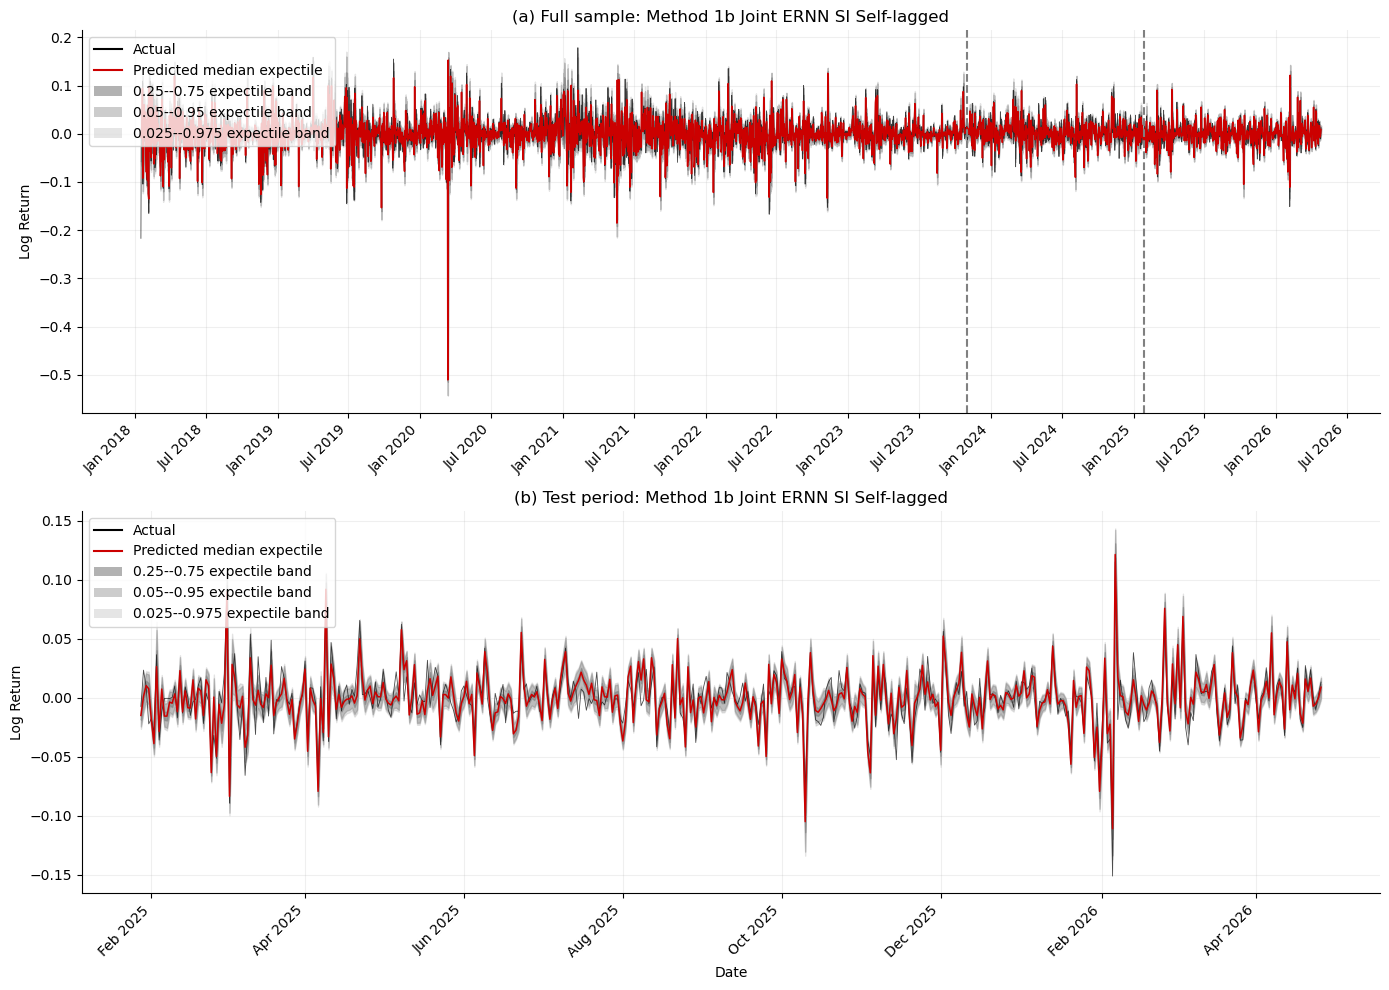

Plot saved to: method1b_joint_ernn_si_self_predictions.png

TEST METRICS -- METHOD 1B JOINT ERNN SI SELF-LAGGED
 level       NLL      ASE    sigma
 0.025 -2.701646 0.000014 0.008417
 0.050 -2.783591 0.000022 0.010247
 0.250 -2.912818 0.000056 0.015282
 0.500 -2.954554 0.000064 0.016391
 0.750 -2.947389 0.000053 0.014725
 0.950 -2.835478 0.000021 0.009676
 0.975 -2.752024 0.000013 0.007981

Average NLL: -2.841071
Average ASE: 0.00003472

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
 Lower  Upper  Violations  Rate
 0.025  0.050           0   0.0
 0.050  0.250           0   0.0
 0.250  0.500           0   0.0
 0.500  0.750           0   0.0
 0.750  0.950           0   0.0
 0.950  0.975           0   0.0

Total violations: 0
Tail violations: 0

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Level  Upper_Level  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero_Rate
delta12        0.025        0.050    0.002132       0.000942       0.009026   0.000

In [24]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B -- ERNN SI
# Self-LAGGED
# ============================================================

m1b_plot_pairs = list(zip(m1b_levels[:-1], m1b_levels[1:]))
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

if 'm1b_best_model' not in globals():
    m1b_plot_checkpoint_filename = f'{m1b_model_tag}_best.pt'
    m1b_plot_checkpoint = torch.load(
        m1b_plot_checkpoint_filename,
        map_location='cpu',
        weights_only=False,
    )
    m1b_best_model = Method1BJointHybrid(
        X_train.shape[1], m1b_plot_checkpoint['config']
    )
    m1b_best_model.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

m1b_best_model.eval()

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values, dtype=torch.float32
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values, dtype=torch.float32
)

with torch.no_grad():
    (
        m1b_plot_forecasts_all,
        m1b_plot_sigma,
        _,
        _,
        _,
        m1b_plot_spacings_all,
    ) = m1b_best_model(m1b_plot_y_all, m1b_plot_X_all)

m1b_plot_forecasts_np = m1b_plot_forecasts_all.cpu().numpy()
m1b_plot_spacings_np = m1b_plot_spacings_all.cpu().numpy()
m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_forecasts_test = m1b_plot_forecasts_all[
    m1b_plot_test_start:
]
m1b_plot_spacings_test = m1b_plot_spacings_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_forecasts_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check the split.'
    )


def m1b_draw_panel(axis, dates, actual, forecasts):
    axis.plot(dates, actual, color='#000000', linewidth=0.6, alpha=0.7)
    axis.plot(
        dates, forecasts[:, 3], color='#CC0000', linewidth=1.1
    )
    axis.fill_between(
        dates, forecasts[:, 0], forecasts[:, 6],
        color='#808080', alpha=0.20,
    )
    axis.fill_between(
        dates, forecasts[:, 1], forecasts[:, 5],
        color='#808080', alpha=0.40,
    )
    axis.fill_between(
        dates, forecasts[:, 2], forecasts[:, 4],
        color='#808080', alpha=0.60,
    )
    axis.set_ylabel('Log Return')
    axis.grid(True, alpha=0.2)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


m1b_plot_distribution_label = M1B_DISTRIBUTION.upper()
m1b_plot_form_label = M1B_FORM.upper()
m1b_plot_lag_label = M1B_LAG.title()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_draw_panel(
    axes[0], df.index, df['log_return'].values, m1b_plot_forecasts_np
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    f'(a) Full sample: Method 1b Joint {m1b_plot_distribution_label} '
    f'{m1b_plot_form_label} {m1b_plot_lag_label}-lagged'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_draw_panel(
    axes[1],
    test_df.index,
    test_df['log_return'].values,
    m1b_plot_forecasts_np[m1b_plot_test_start:],
)
axes[1].set_title(
    f'(b) Test period: Method 1b Joint '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label}-lagged'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

if M1B_DISTRIBUTION == 'qrnn':
    median_label = 'Predicted Median (Q50)'
    band_labels = ['50% PI', '90% PI', '95% PI']
else:
    median_label = 'Predicted median expectile'
    band_labels = [
        '0.25--0.75 expectile band',
        '0.05--0.95 expectile band',
        '0.025--0.975 expectile band',
    ]

m1b_legend = [
    Line2D([0], [0], color='#000000', label='Actual'),
    Line2D([0], [0], color='#CC0000', label=median_label),
    Patch(facecolor='#808080', alpha=0.60, label=band_labels[0]),
    Patch(facecolor='#808080', alpha=0.40, label=band_labels[1]),
    Patch(facecolor='#808080', alpha=0.20, label=band_labels[2]),
]
for axis in axes:
    axis.legend(handles=m1b_legend, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(), rotation=45, ha='right'
    )

plt.tight_layout()
m1b_plot_png = f'{m1b_model_tag}_predictions.png'
plt.savefig(m1b_plot_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Plot saved to: {m1b_plot_png}')


# ============================================================
# Test metrics by level
# ============================================================

m1b_plot_metric_rows = []
for index, level in enumerate(m1b_levels):
    forecast = m1b_plot_forecasts_test[:, index]
    sigma = m1b_plot_sigma[index]
    residual = m1b_plot_y_test - forecast

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(residual.dtype)
        check_loss = residual * (level - indicator)
        nll = (
            -torch.log(residual.new_tensor(level * (1 - level)))
            + torch.log(sigma)
            + check_loss / sigma
        ).mean().item()
        hit_rate = (
            m1b_plot_y_test <= forecast
        ).float().mean().item()
        secondary = abs(hit_rate - level)
        row = {
            'level': level,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': secondary,
            'sigma': sigma.item(),
        }
    else:
        weight = torch.abs(
            residual.new_tensor(level)
            - (residual < 0).to(residual.dtype)
        )
        weighted_squared_error = weight * residual.square()
        constant = (
            torch.log(
                torch.sqrt(residual.new_tensor(torch.pi / level))
                + torch.sqrt(
                    residual.new_tensor(torch.pi / (1 - level))
                )
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma)
            + constant
            + weighted_squared_error / sigma.square()
        ).mean().item()
        secondary = weighted_squared_error.mean().item()
        row = {
            'level': level,
            'NLL': nll,
            'ASE': secondary,
            'sigma': sigma.item(),
        }

    m1b_plot_metric_rows.append(row)

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_metric_column = (
    'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
)
print('\n' + '=' * 72)
print(
    f'TEST METRICS -- METHOD 1B JOINT '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label.upper()}-LAGGED'
)
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f"\nAverage NLL: {m1b_plot_metrics_df['NLL'].mean():.6f}")
print(
    f'Average {m1b_plot_metric_column}: '
    f"{m1b_plot_metrics_df[m1b_plot_metric_column].mean():.8f}"
)


# ============================================================
# Crossover and learned-spacing diagnostics
# ============================================================

m1b_plot_crossover_rows = []
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    count = int((
        m1b_plot_forecasts_test[:, index]
        > m1b_plot_forecasts_test[:, index + 1]
    ).sum().item())
    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': count,
        'Rate': count / len(m1b_plot_y_test),
    })

m1b_plot_crossover_df = pd.DataFrame(m1b_plot_crossover_rows)
m1b_plot_total = int(m1b_plot_crossover_df['Violations'].sum())
m1b_plot_tail = int(
    m1b_plot_crossover_df.iloc[0]['Violations']
    + m1b_plot_crossover_df.iloc[-1]['Violations']
)
print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)
print(m1b_plot_crossover_df.to_string(index=False))
print(f'\nTotal violations: {m1b_plot_total}')
print(f'Tail violations: {m1b_plot_tail}')

m1b_plot_spacing_rows = []
for index, (name, pair) in enumerate(zip(
    m1b_spacing_names, m1b_plot_pairs
)):
    spacing = m1b_plot_spacings_test[:, index]
    m1b_plot_spacing_rows.append({
        'Spacing': name,
        'Lower_Level': pair[0],
        'Upper_Level': pair[1],
        'Mean_Delta': spacing.mean().item(),
        'Minimum_Delta': spacing.min().item(),
        'Maximum_Delta': spacing.max().item(),
        'Delta_Std': spacing.std(unbiased=False).item(),
        'Near_Zero_Count': int((spacing <= 1e-5).sum().item()),
        'Near_Zero_Rate': (
            spacing <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_spacing_df = pd.DataFrame(m1b_plot_spacing_rows)
print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_spacing_df.to_string(index=False))


# ============================================================
# Detailed predictions and saved outputs
# ============================================================

m1b_plot_predictions_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
    'Actual': test_df['log_return'].values,
})
m1b_plot_prefix = 'Q' if M1B_DISTRIBUTION == 'qrnn' else 'E'
for index, level in enumerate(m1b_levels):
    m1b_plot_predictions_df[f'{m1b_plot_prefix}_{level:.3f}'] = (
        m1b_plot_forecasts_np[m1b_plot_test_start:, index]
    )
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    m1b_plot_predictions_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_spacings_np[m1b_plot_test_start:, index]

m1b_plot_metrics_file = f'{m1b_model_tag}_test_metrics.csv'
m1b_plot_crossover_file = f'{m1b_model_tag}_crossover.csv'
m1b_plot_spacing_file = f'{m1b_model_tag}_delta_summary.csv'
m1b_plot_predictions_file = f'{m1b_model_tag}_test_predictions.csv'

m1b_plot_metrics_df.to_csv(m1b_plot_metrics_file, index=False)
m1b_plot_crossover_df.to_csv(m1b_plot_crossover_file, index=False)
m1b_plot_spacing_df.to_csv(m1b_plot_spacing_file, index=False)
m1b_plot_predictions_df.to_csv(m1b_plot_predictions_file, index=False)

print('\nSaved Method 1b outputs:')
for filename in (
    m1b_plot_png,
    m1b_plot_metrics_file,
    m1b_plot_crossover_file,
    m1b_plot_spacing_file,
    m1b_plot_predictions_file,
):
    print(f'  {filename}')



# Cross over dealing2

In [24]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Method 2 -- Sequential ERNN SI Self-lagged
# ============================================================

m2_ernn_self_si_tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_ernn_self_si_order = [
    0.500,
    0.750, 0.950, 0.975,
    0.250, 0.050, 0.025
]

m2_ernn_self_si_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_ernn_self_si_direction = {
    0.500: 'median',
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_ERNN_SELF_SI_DELTA = 1e-6
M2_ERNN_SELF_SI_SCALE = 1e-3
M2_ERNN_SELF_SI_PSI_EPS = 1e-4


# ============================================================
# Smooth positive adjustment
# ============================================================

def m2_ernn_self_si_scaled_softplus(
    value,
    scale=M2_ERNN_SELF_SI_SCALE
):
    return (
        scale
        * F.softplus(value / scale)
    )


# ============================================================
# Method 2 ERNN SI self-lagged model
# ============================================================

class M2SequentialERNNSISelf(nn.Module):
    def __init__(
        self,
        input_dim,
        config,
        direction='median'
    ):
        super().__init__()

        self.direction = direction
        self.eps = 1e-6

        self.gamma1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.gamma2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.gamma3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        fnn_input_dim = (
            input_dim
            if direction == 'median'
            else input_dim + 1
        )

        layers = []
        previous_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):
            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        reference=None,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )

        gamma2 = F.softplus(
            self.gamma2_raw
        )

        gamma3 = F.softplus(
            self.gamma3_raw
        )

        psi = (
            (1.0 - M2_ERNN_SELF_SI_PSI_EPS)
            * torch.sigmoid(self.psi_raw)
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        if self.direction == 'median':
            fnn_input = X

        else:
            if reference is None:
                raise ValueError(
                    'A reference prediction is required '
                    'for a nonmedian level.'
                )

            fnn_input = torch.cat(
                [
                    X,
                    reference.reshape(-1, 1)
                ],
                dim=1
            )

        raw_fnn = (
            self.fnn(fnn_input)
            .squeeze(-1)
        )

        (
            e_hybrid,
            e_care,
            constrained_fnn
        ) = m2_ernn_self_si_location(
            y=y,
            raw_fnn=raw_fnn,
            gamma1=gamma1,
            gamma2=gamma2,
            gamma3=gamma3,
            psi=psi,
            reference=reference,
            direction=self.direction,
            initial_care=initial_care,
            initial_y=initial_y
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            constrained_fnn
        )


# ============================================================
# Self-lagged SI hybrid location
# ============================================================

def m2_ernn_self_si_location(
    y,
    raw_fnn,
    gamma1,
    gamma2,
    gamma3,
    psi,
    reference=None,
    direction='median',
    initial_care=None,
    initial_y=None
):
    T = len(y)
    zero = y.new_tensor(0.0)

    hybrid_list = []
    care_list = []
    fnn_list = []

    if (
        (initial_care is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_care and initial_y '
            'must be supplied together.'
        )

    has_initial_state = (
        initial_care is not None
    )

    previous_care = (
        initial_care
        if has_initial_state
        else zero
    )

    for t in range(T):
        if (
            t == 0
            and not has_initial_state
        ):
            hybrid_list.append(zero)
            care_list.append(zero)
            fnn_list.append(raw_fnn[t])
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        absolute_return = torch.abs(
            previous_y
        )

        # Self-lagged SI CARE recursion
        care_t = (
            gamma1 * previous_care
            + gamma2 * absolute_return
            + gamma3
            * previous_care
            * absolute_return
        )

        if direction == 'median':
            fnn_t = raw_fnn[t]

        elif direction == 'upper':
            fnn_lower_bound = (
                reference[t]
                + M2_ERNN_SELF_SI_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_lower_bound
                + m2_ernn_self_si_scaled_softplus(
                    raw_fnn[t]
                    - fnn_lower_bound
                )
            )

        elif direction == 'lower':
            fnn_upper_bound = (
                reference[t]
                - M2_ERNN_SELF_SI_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_upper_bound
                - m2_ernn_self_si_scaled_softplus(
                    fnn_upper_bound
                    - raw_fnn[t]
                )
            )

        else:
            raise ValueError(
                "direction must be 'median', "
                "'upper' or 'lower'."
            )

        hybrid_t = (
            psi * care_t
            + (1.0 - psi) * fnn_t
        )

        hybrid_list.append(hybrid_t)
        care_list.append(care_t)
        fnn_list.append(fnn_t)

        # Self-lagged update:
        # previous pure CARE output
        previous_care = care_t

    return (
        torch.stack(hybrid_list),
        torch.stack(care_list),
        torch.stack(fnn_list)
    )


# ============================================================
# Level-specific AGD loss and ASE
# ============================================================

def m2_ernn_self_si_loss(
    y,
    e_hybrid,
    sigma,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    asymmetric_squared_error = (
        weight * residual.pow(2)
    )

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau_tensor
            )
            + torch.sqrt(
                torch.pi
                / (1.0 - tau_tensor)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma)
        + constant
        + asymmetric_squared_error
        / sigma.pow(2)
    )

    return nll.mean()


def m2_ernn_self_si_compute_ase(
    y,
    e_hybrid,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    return (
        weight * residual.pow(2)
    ).mean().item()


# ============================================================
# Optuna configuration
# ============================================================

def m2_ernn_self_si_suggest_config(
    trial
):
    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),
        'activation':
            trial.suggest_categorical(
                'activation',
                [
                    'relu',
                    'elu',
                    'gelu',
                    'tanh'
                ]
            ),
        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),
        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),
        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),
        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),
        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),
        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),
        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),
        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ============================================================
# Fit one expectile level
# ============================================================

def m2_ernn_self_si_fit(
    config,
    tau,
    direction,
    reference_train=None,
    reference_val=None,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = M2SequentialERNNSISelf(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            e_train,
            sigma,
            _,
            _
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        train_loss = m2_ernn_self_si_loss(
            y=y_train[1:],
            e_hybrid=e_train[1:],
            sigma=sigma,
            tau=tau
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                _,
                sigma_val,
                care_train,
                _
            ) = model(
                y=y_train,
                X=X_train,
                reference=reference_train
            )

            (
                e_val,
                _,
                _,
                _
            ) = model(
                y=y_val,
                X=X_val,
                reference=reference_val,
                initial_care=care_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_ernn_self_si_loss(
                y=y_val,
                e_hybrid=e_val,
                sigma=sigma_val,
                tau=tau
            )

        scheduler.step(
            val_loss.item()
        )

        if (
            val_loss.item()
            < best_val_loss
        ):
            best_val_loss = (
                val_loss.item()
            )

            patience_counter = 0

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ============================================================
# Evaluate one fitted level
# ============================================================

def m2_ernn_self_si_evaluate(
    model,
    tau,
    reference_train=None,
    reference_val=None
):
    model.eval()

    with torch.no_grad():
        (
            e_train,
            sigma,
            care_train,
            fnn_train
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        (
            e_val,
            _,
            care_val,
            fnn_val
        ) = model(
            y=y_val,
            X=X_val,
            reference=reference_val,
            initial_care=care_train[-1],
            initial_y=y_train[-1]
        )

        val_nll = m2_ernn_self_si_loss(
            y=y_val,
            e_hybrid=e_val,
            sigma=sigma,
            tau=tau
        ).item()

        val_ase = (
            m2_ernn_self_si_compute_ase(
                y=y_val,
                e_hybrid=e_val,
                tau=tau
            )
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        ).item()

        gamma2 = F.softplus(
            model.gamma2_raw
        ).item()

        gamma3 = F.softplus(
            model.gamma3_raw
        ).item()

        psi = (
            (1.0 - M2_ERNN_SELF_SI_PSI_EPS)
            * torch.sigmoid(model.psi_raw)
        ).item()

        sigma_value = (
            F.softplus(model.sigma_raw)
            + model.eps
        ).item()

    return {
        'val_nll': val_nll,
        'val_ase': val_ase,
        'train_prediction':
            e_train.detach(),
        'val_prediction':
            e_val.detach(),
        'train_care':
            care_train.detach(),
        'val_care':
            care_val.detach(),
        'train_fnn':
            fnn_train.detach(),
        'val_fnn':
            fnn_val.detach(),
        'gamma1': gamma1,
        'gamma2': gamma2,
        'gamma3': gamma3,
        'psi': psi,
        'sigma': sigma_value
    }


# ============================================================
# Objective factory
# ============================================================

def m2_ernn_self_si_make_objective(
    tau,
    direction,
    reference_train,
    reference_val,
    seed
):
    def objective(trial):
        config = (
            m2_ernn_self_si_suggest_config(
                trial
            )
        )

        model = m2_ernn_self_si_fit(
            config=config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=seed
        )

        if model is None:
            return float('inf')

        metrics = (
            m2_ernn_self_si_evaluate(
                model=model,
                tau=tau,
                reference_train=reference_train,
                reference_val=reference_val
            )
        )

        trial.set_user_attr(
            'val_nll',
            metrics['val_nll']
        )

        trial.set_user_attr(
            'val_ase',
            metrics['val_ase']
        )

        for parameter in [
            'gamma1',
            'gamma2',
            'gamma3',
            'psi',
            'sigma'
        ]:
            trial.set_user_attr(
                parameter,
                metrics[parameter]
            )

        print(
            f"Trial {trial.number}: "
            f"tau={tau:.3f} | "
            f"NLL={metrics['val_nll']:.6f} | "
            f"ASE={metrics['val_ase']:.8f}"
        )

        return metrics['val_nll']

    return objective


# ============================================================
# Rank using validation NLL and ASE
# ============================================================

def m2_ernn_self_si_select_trial(
    study
):
    trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'val_nll'
            in trial.user_attrs
            and 'val_ase'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for trial in trials:
        trial._nll = (
            trial.user_attrs['val_nll']
        )

        trial._ase = (
            trial.user_attrs['val_ase']
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._nll
        ),
        start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._ase
        ),
        start=1
    ):
        trial._rank_ase = rank

    best_trial = min(
        trials,
        key=lambda item: (
            item._rank_nll
            + item._rank_ase,
            item._nll,
            item._ase,
            item.number
        )
    )

    return best_trial, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_ernn_self_si_best_configs = {}
m2_ernn_self_si_final_models = {}
m2_ernn_self_si_train_predictions = {}
m2_ernn_self_si_val_predictions = {}
m2_ernn_self_si_validation_metrics = {}
m2_ernn_self_si_studies = {}

for level_index, tau in enumerate(
    m2_ernn_self_si_order
):
    direction = (
        m2_ernn_self_si_direction[
            tau
        ]
    )

    reference_tau = (
        m2_ernn_self_si_reference[
            tau
        ]
    )

    if reference_tau is None:
        reference_train = None
        reference_val = None
    else:
        reference_train = (
            m2_ernn_self_si_train_predictions[
                reference_tau
            ].detach()
        )

        reference_val = (
            m2_ernn_self_si_val_predictions[
                reference_tau
            ].detach()
        )

    current_seed = 2026 + level_index

    print('\n' + '=' * 70)
    print(
        'METHOD 2 -- TUNING ERNN SI SELF-LAGGED '
        f'FOR TAU = {tau}'
    )
    print(
        f'Direction: {direction} | '
        f'Reference: {reference_tau}'
    )
    print('=' * 70)

    sampler = TPESampler(
        seed=current_seed
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    objective = (
        m2_ernn_self_si_make_objective(
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            seed=current_seed
        )
    )

    study.optimize(
        objective,
        n_trials=200,
        show_progress_bar=True
    )

    (
        best_trial,
        valid_trials
    ) = m2_ernn_self_si_select_trial(
        study
    )

    # Save ranking
    ranking_records = []

    for trial in valid_trials:
        record = {
            'tau': tau,
            'trial': trial.number,
            'val_nll': trial._nll,
            'val_ase': trial._ase,
            'rank_nll':
                trial._rank_nll,
            'rank_ase':
                trial._rank_ase,
            'sum_rank':
                trial._rank_nll
                + trial._rank_ase,
            'gamma1':
                trial.user_attrs['gamma1'],
            'gamma2':
                trial.user_attrs['gamma2'],
            'gamma3':
                trial.user_attrs['gamma3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    ).sort_values(
        [
            'sum_rank',
            'val_nll',
            'val_ase'
        ]
    )

    ranking_df.to_csv(
        (
            'method2_sequential_ernn_si_self_'
            f'ranking_tau_{tau}.csv'
        ),
        index=False
    )

    best_config = (
        best_trial.params.copy()
    )

    # Refit selected model
    final_model = (
        m2_ernn_self_si_fit(
            config=best_config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=current_seed
        )
    )

    final_metrics = (
        m2_ernn_self_si_evaluate(
            model=final_model,
            tau=tau,
            reference_train=reference_train,
            reference_val=reference_val
        )
    )

    m2_ernn_self_si_best_configs[
        tau
    ] = best_config

    m2_ernn_self_si_final_models[
        tau
    ] = final_model

    m2_ernn_self_si_train_predictions[
        tau
    ] = final_metrics[
        'train_prediction'
    ]

    m2_ernn_self_si_val_predictions[
        tau
    ] = final_metrics[
        'val_prediction'
    ]

    m2_ernn_self_si_validation_metrics[
        tau
    ] = {
        'val_nll':
            final_metrics['val_nll'],
        'val_ase':
            final_metrics['val_ase'],
        'gamma1':
            final_metrics['gamma1'],
        'gamma2':
            final_metrics['gamma2'],
        'gamma3':
            final_metrics['gamma3'],
        'psi':
            final_metrics['psi'],
        'sigma':
            final_metrics['sigma'],
        'direction':
            direction,
        'reference_tau':
            reference_tau,
        'best_trial':
            best_trial.number
    }

    m2_ernn_self_si_studies[
        tau
    ] = study

    print(
        f'\nSelected tau={tau:.3f}: '
        f"NLL={final_metrics['val_nll']:.6f} | "
        f"ASE={final_metrics['val_ase']:.8f}"
    )


# ============================================================
# Validation crossover check
# ============================================================

m2_ernn_self_si_val_matrix = torch.stack(
    [
        m2_ernn_self_si_val_predictions[
            tau
        ]
        for tau
        in m2_ernn_self_si_tau_levels
    ],
    dim=1
)

m2_ernn_self_si_val_crossovers = (
    m2_ernn_self_si_val_matrix[:, :-1]
    > m2_ernn_self_si_val_matrix[:, 1:]
)

m2_ernn_self_si_val_pair_counts = (
    m2_ernn_self_si_val_crossovers
    .sum(dim=0)
)

m2_ernn_self_si_val_total_crossovers = int(
    m2_ernn_self_si_val_pair_counts
    .sum()
    .item()
)

m2_ernn_self_si_val_tail_crossovers = int(
    (
        m2_ernn_self_si_val_pair_counts[0]
        + m2_ernn_self_si_val_pair_counts[-1]
    ).item()
)


# ============================================================
# Save all seven models
# ============================================================

m2_ernn_self_si_saved_models = {}

for tau in m2_ernn_self_si_tau_levels:
    m2_ernn_self_si_saved_models[
        str(tau)
    ] = {
        'state_dict':
            m2_ernn_self_si_final_models[
                tau
            ].state_dict(),
        'config':
            m2_ernn_self_si_best_configs[
                tau
            ],
        'direction':
            m2_ernn_self_si_direction[
                tau
            ],
        'reference_tau':
            m2_ernn_self_si_reference[
                tau
            ]
    }

torch.save(
    {
        'tau_levels':
            m2_ernn_self_si_tau_levels,
        'estimation_order':
            m2_ernn_self_si_order,
        'models':
            m2_ernn_self_si_saved_models,
        'validation_metrics':
            m2_ernn_self_si_validation_metrics,
        'validation_crossover_count':
            m2_ernn_self_si_val_total_crossovers,
        'validation_tail_count':
            m2_ernn_self_si_val_tail_crossovers,
        'delta':
            M2_ERNN_SELF_SI_DELTA,
        'softplus_scale':
            M2_ERNN_SELF_SI_SCALE
    },
    'method2_sequential_ernn_si_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

m2_ernn_self_si_average_val_nll = np.mean(
    [
        m2_ernn_self_si_validation_metrics[
            tau
        ]['val_nll']
        for tau
        in m2_ernn_self_si_tau_levels
    ]
)

m2_ernn_self_si_average_val_ase = np.mean(
    [
        m2_ernn_self_si_validation_metrics[
            tau
        ]['val_ase']
        for tau
        in m2_ernn_self_si_tau_levels
    ]
)

print('\n' + '=' * 70)
print(
    'METHOD 2 TUNING COMPLETE -- '
    'ERNN SI SELF-LAGGED'
)
print('=' * 70)

print(
    f'Average validation NLL: '
    f'{m2_ernn_self_si_average_val_nll:.6f}'
)

print(
    f'Average validation ASE: '
    f'{m2_ernn_self_si_average_val_ase:.8f}'
)

print(
    f'Validation crossover count: '
    f'{m2_ernn_self_si_val_total_crossovers}'
)

print(
    f'Validation tail crossover count: '
    f'{m2_ernn_self_si_val_tail_crossovers}'
)

print(
    'Checkpoint saved to '
    'method2_sequential_ernn_si_self_best.pt'
)

[I 2026-08-06 16:23:11,815] A new study created in memory with name: no-name-32af82bf-267a-4b37-ba97-90f2fa6d6fc3



METHOD 2 -- TUNING ERNN SI SELF-LAGGED FOR TAU = 0.5
Direction: median | Reference: None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.500 | NLL=0.802467 | ASE=0.00147053
[I 2026-08-06 16:23:34,952] Trial 0 finished with value: 0.8024671673774719 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8024671673774719.
Trial 1: tau=0.500 | NLL=-0.227706 | ASE=0.00023024
[I 2026-08-06 16:23:59,642] Trial 1 finished with value: -0.22770589590072632 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22770589590072632.
Trial 2: tau=0.500 | NLL=0.897809 | ASE=0.00536112
[I 2026-08-06 16:24:03,568] Tri

[I 2026-08-06 17:30:42,187] A new study created in memory with name: no-name-3b6c3a2e-1b50-441f-a265-a726358d5888


...

Trial 0: tau=0.050 | NLL=0.504479 | ASE=0.00009542
[I 2026-08-07 11:49:20,312] Trial 0 finished with value: 0.5044788122177124 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5044788122177124.
Trial 1: tau=0.050 | NLL=-0.768189 | ASE=0.00009462
[I 2026-08-07 11:50:04,779] Trial 1 finished with value: -0.7681894302368164 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7681894302368164.
Trial 2: tau=0.050

[I 2026-08-09 14:37:57,700] A new study created in memory with name: no-name-71e6184b-6352-4364-a91c-399ab4adbf66



Selected tau=0.050: NLL=-2.259202 | ASE=0.00008230

METHOD 2 -- TUNING ERNN SI SELF-LAGGED FOR TAU = 0.025
Direction: lower | Reference: 0.05


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.025 | NLL=0.645594 | ASE=0.00006801
[I 2026-08-09 14:38:43,074] Trial 0 finished with value: 0.6455938220024109 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6455938220024109.
Trial 1: tau=0.025 | NLL=1.552244 | ASE=0.00006801
[I 2026-08-09 14:39:28,326] Trial 1 finished with value: 1.552243947982788 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6455938220024109.
Tr

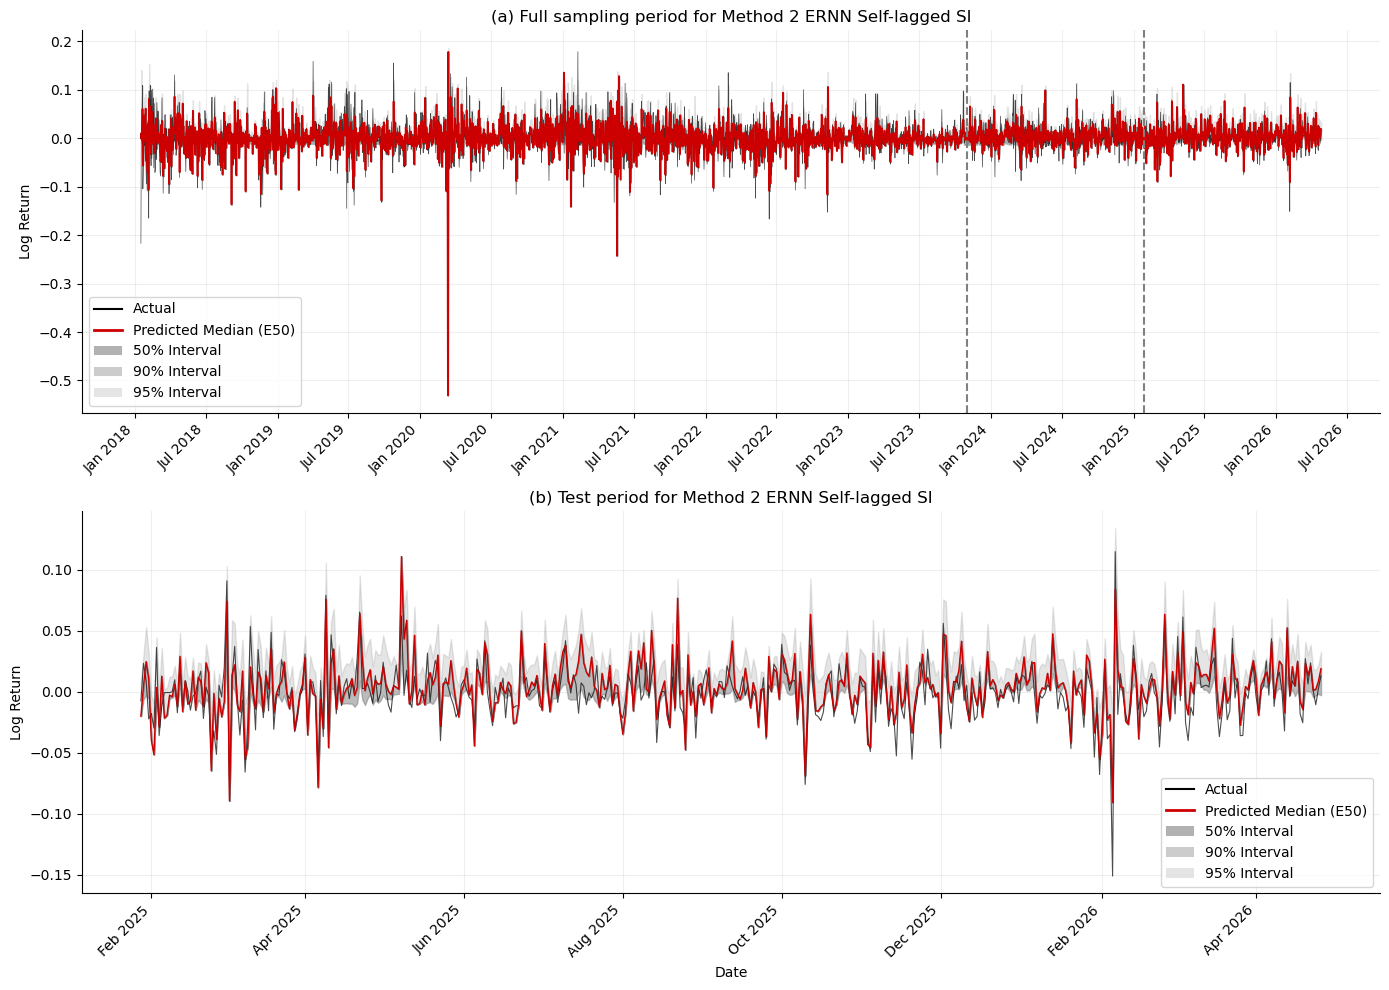

Plot saved to method2_sequential_ernn_si_self_predictions.png

TEST METRICS -- METHOD 2 ERNN SI SELF-LAGGED
  tau       NLL      ASE
0.025 -2.171055 0.000054
0.050 -2.377552 0.000058
0.250 -2.635696 0.000120
0.500 -2.732185 0.000095
0.750 -2.778815 0.000071
0.950 -2.269765 0.000051
0.975 -2.362959 0.000023

Average NLL: -2.475432
Average ASE: 0.00006731

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_ernn_si_self_test_metrics.csv


In [27]:
# ============================================================
# Plot and evaluate Method 2
# Sequential ERNN SI Self-lagged
# ============================================================

import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Load checkpoint if models are not in memory
# ============================================================

if 'm2_ernn_self_si_final_models' not in globals():
    checkpoint = torch.load(
        'method2_sequential_ernn_si_self_best.pt',
        map_location='cpu',
        weights_only=False
    )

    m2_ernn_self_si_final_models = {}

    for tau in checkpoint['estimation_order']:
        saved_model = checkpoint[
            'models'
        ][str(tau)]

        model = M2SequentialERNNSISelf(
            input_dim=X_train.shape[1],
            config=saved_model['config'],
            direction=saved_model['direction']
        )

        model.load_state_dict(
            saved_model['state_dict']
        )

        model.eval()

        m2_ernn_self_si_final_models[
            tau
        ] = model


# ============================================================
# Full-sample predictions
# ============================================================

m2_ernn_self_si_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_ernn_self_si_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

m2_ernn_self_si_all_predictions = {}
m2_ernn_self_si_all_care = {}
m2_ernn_self_si_all_fnn = {}
m2_ernn_self_si_all_sigma = {}

for tau in m2_ernn_self_si_order:
    model = m2_ernn_self_si_final_models[
        tau
    ]

    reference_tau = (
        m2_ernn_self_si_reference[tau]
    )

    if reference_tau is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_ernn_self_si_all_predictions[
                reference_tau
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            prediction,
            sigma,
            care_output,
            fnn_output
        ) = model(
            y=m2_ernn_self_si_y_all,
            X=m2_ernn_self_si_X_all,
            reference=reference_prediction
        )

    m2_ernn_self_si_all_predictions[
        tau
    ] = prediction.detach()

    m2_ernn_self_si_all_care[
        tau
    ] = care_output.detach()

    m2_ernn_self_si_all_fnn[
        tau
    ] = fnn_output.detach()

    m2_ernn_self_si_all_sigma[
        tau
    ] = sigma.detach()


m2_ernn_self_si_all_preds_np = {
    tau: prediction.cpu().numpy()
    for tau, prediction
    in m2_ernn_self_si_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_ernn_self_si_test_start = (
    len(train_df) + len(val_df)
)

m2_ernn_self_si_all_dates = df.index
m2_ernn_self_si_test_dates = test_df.index

m2_ernn_self_si_y_all_np = (
    df['log_return'].values
)

m2_ernn_self_si_y_test_np = (
    test_df['log_return'].values
)

test_slice = slice(
    m2_ernn_self_si_test_start,
    None
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (E50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% Interval'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# Full sample
ax = axes[0]

ax.plot(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.025],
    m2_ernn_self_si_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.050],
    m2_ernn_self_si_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.250],
    m2_ernn_self_si_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--'
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--'
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 ERNN Self-lagged SI'
)

ax.set_ylabel('Log Return')
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.2)


# Test sample
ax2 = axes[1]

ax2.plot(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.500
    ][test_slice],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.025
    ][test_slice],
    m2_ernn_self_si_all_preds_np[
        0.975
    ][test_slice],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.050
    ][test_slice],
    m2_ernn_self_si_all_preds_np[
        0.950
    ][test_slice],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.250
    ][test_slice],
    m2_ernn_self_si_all_preds_np[
        0.750
    ][test_slice],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 ERNN Self-lagged SI'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(handles=legend_elements)
ax2.grid(True, alpha=0.2)


for axis, interval in zip(
    axes,
    [6, 2]
):
    axis.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )

    axis.xaxis.set_major_locator(
        mdates.MonthLocator(
            interval=interval
        )
    )

    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

m2_ernn_self_si_plot_name = (
    'method2_sequential_ernn_si_self_predictions.png'
)

plt.savefig(
    m2_ernn_self_si_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to '
    f'{m2_ernn_self_si_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_ernn_self_si_y_test = (
    m2_ernn_self_si_y_all[
        m2_ernn_self_si_test_start:
    ]
)

metric_rows = []

for tau in m2_ernn_self_si_tau_levels:
    prediction_test = (
        m2_ernn_self_si_all_predictions[
            tau
        ][m2_ernn_self_si_test_start:]
    )

    sigma = (
        m2_ernn_self_si_all_sigma[tau]
    )

    test_nll = m2_ernn_self_si_loss(
        y=m2_ernn_self_si_y_test,
        e_hybrid=prediction_test,
        sigma=sigma,
        tau=tau
    ).item()

    test_ase = (
        m2_ernn_self_si_compute_ase(
            y=m2_ernn_self_si_y_test,
            e_hybrid=prediction_test,
            tau=tau
        )
    )

    metric_rows.append({
        'tau': tau,
        'NLL': test_nll,
        'ASE': test_ase
    })


m2_ernn_self_si_metrics_df = (
    pd.DataFrame(metric_rows)
)

average_nll = (
    m2_ernn_self_si_metrics_df[
        'NLL'
    ].mean()
)

average_ase = (
    m2_ernn_self_si_metrics_df[
        'ASE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'ERNN SI SELF-LAGGED'
)
print('=' * 68)

print(
    m2_ernn_self_si_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: {average_nll:.6f}'
)

print(
    f'Average ASE: {average_ase:.8f}'
)


# ============================================================
# Crossover analysis
# ============================================================

adjacent_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

total_violations = 0
tail_violations = 0
crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower, upper in adjacent_pairs:
    lower_test = (
        m2_ernn_self_si_all_predictions[
            lower
        ][m2_ernn_self_si_test_start:]
    )

    upper_test = (
        m2_ernn_self_si_all_predictions[
            upper
        ][m2_ernn_self_si_test_start:]
    )

    violations = int(
        (
            lower_test > upper_test
        ).sum().item()
    )

    rate = (
        violations / len(lower_test)
    )

    total_violations += violations

    if (lower, upper) in tail_pairs:
        tail_violations += violations

    crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (lower, upper) in tail_pairs
        else ''
    )

    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


total_rate = (
    total_violations
    / (
        len(m2_ernn_self_si_y_test)
        * 6
    )
)

tail_rate = (
    tail_violations
    / (
        len(m2_ernn_self_si_y_test)
        * 2
    )
)

print(
    f'\nTotal violations: '
    f'{total_violations} '
    f'({100 * total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{tail_violations} '
    f'({100 * tail_rate:.2f}%)'
)


# ============================================================
# Save results
# ============================================================

m2_ernn_self_si_metrics_df.to_csv(
    'method2_sequential_ernn_si_self_test_metrics.csv',
    index=False
)

pd.DataFrame(
    crossover_rows
).to_csv(
    'method2_sequential_ernn_si_self_crossover.csv',
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_ernn_si_self_test_metrics.csv'
)

# Cross over dealing 3

In [30]:
"""Method 3, Specification 1: Hybrid ERNN SI self-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_ernn_si_self_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid ERNN, symmetric indirect form, self-lagged recursion.
MODELS_TO_RUN = [("ernn", "si", "self")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_ernn_si_self_validation_summary.csv", index=False
        )
    print("\nMethod 3 ERNN SI self-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 14:48:12,842] A new study created in memory with name: no-name-0ea2bfc3-a537-43c1-a54d-4968f040f6c2



METHOD 3 SPACING: ERNN SI SELF
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 14:48:57,718] Trial 0 finished with value: 0.8024671673774719 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8024671673774719.
[I 2026-08-16 14:49:38,048] Trial 1 finished with value: -0.22770589590072632 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22770589590072632.
[I 2026-08-16 14:49:44,982] Trial 2 finished with value: 0.8978094458580017 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': Tru

[I 2026-08-16 17:32:32,586] A new study created in memory with name: no-name-3f545a4c-fe84-4937-8e6e-047dc1d53679


...

[I 2026-08-16 18:09:01,232] Trial 0 finished with value: 0.504104495048523 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.504104495048523.
[I 2026-08-16 18:09:05,896] Trial 1 finished with value: -0.7730656266212463 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7730656266212463.
[I 2026-08-16 18:09:08,590] Trial 2 finished with value: 1.4520741701126099 and parameters: {'n_hidden_layers': 2, 'activat

[I 2026-08-16 18:14:21,660] A new study created in memory with name: no-name-a3d97622-6aa8-4d54-91d1-f52c7b42289b


Selected trial #161 | val NLL=-2.528287 | calibration=0.000049 | mean delta=0.011684
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 18:14:28,408] Trial 0 finished with value: 0.6449094414710999 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6449094414710999.
[I 2026-08-16 18:14:34,610] Trial 1 finished with value: 1.5522116422653198 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6449094414710999.
[I 2026-08-16 18:14:36,514] Trial 2 finished with value: 1.696600317955017 and parameters: {'n_hidden_l


METHOD 3 ERNN SI SELF-LAGGED -- TEST RESULTS
                model  test_T  average_nll  average_ase  crossover  tail
Method 3 ERNN SI Self     454    -2.727165     0.000052          0     0

Per-level results:
  tau       nll      ase    sigma
0.025 -2.666577 0.000020 0.007608
0.050 -2.719462 0.000030 0.010126
0.250 -2.816882 0.000068 0.016848
0.500 -2.655391 0.000115 0.022203
0.750 -2.820273 0.000077 0.015469
0.950 -2.723725 0.000033 0.008773
0.975 -2.687845 0.000019 0.007168

Learned-spacing diagnostics:
  tau  reference_tau direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
0.025           0.05     lower    0.004778   0.003131   0.008070  0.000801                0             0.0
0.050           0.25     lower    0.009927   0.007090   0.016946  0.001409                0             0.0
0.250           0.50     lower    0.012181   0.005852   0.020753  0.002528                0             0.0
0.750           0.50     upper    0.002156   0.000148 

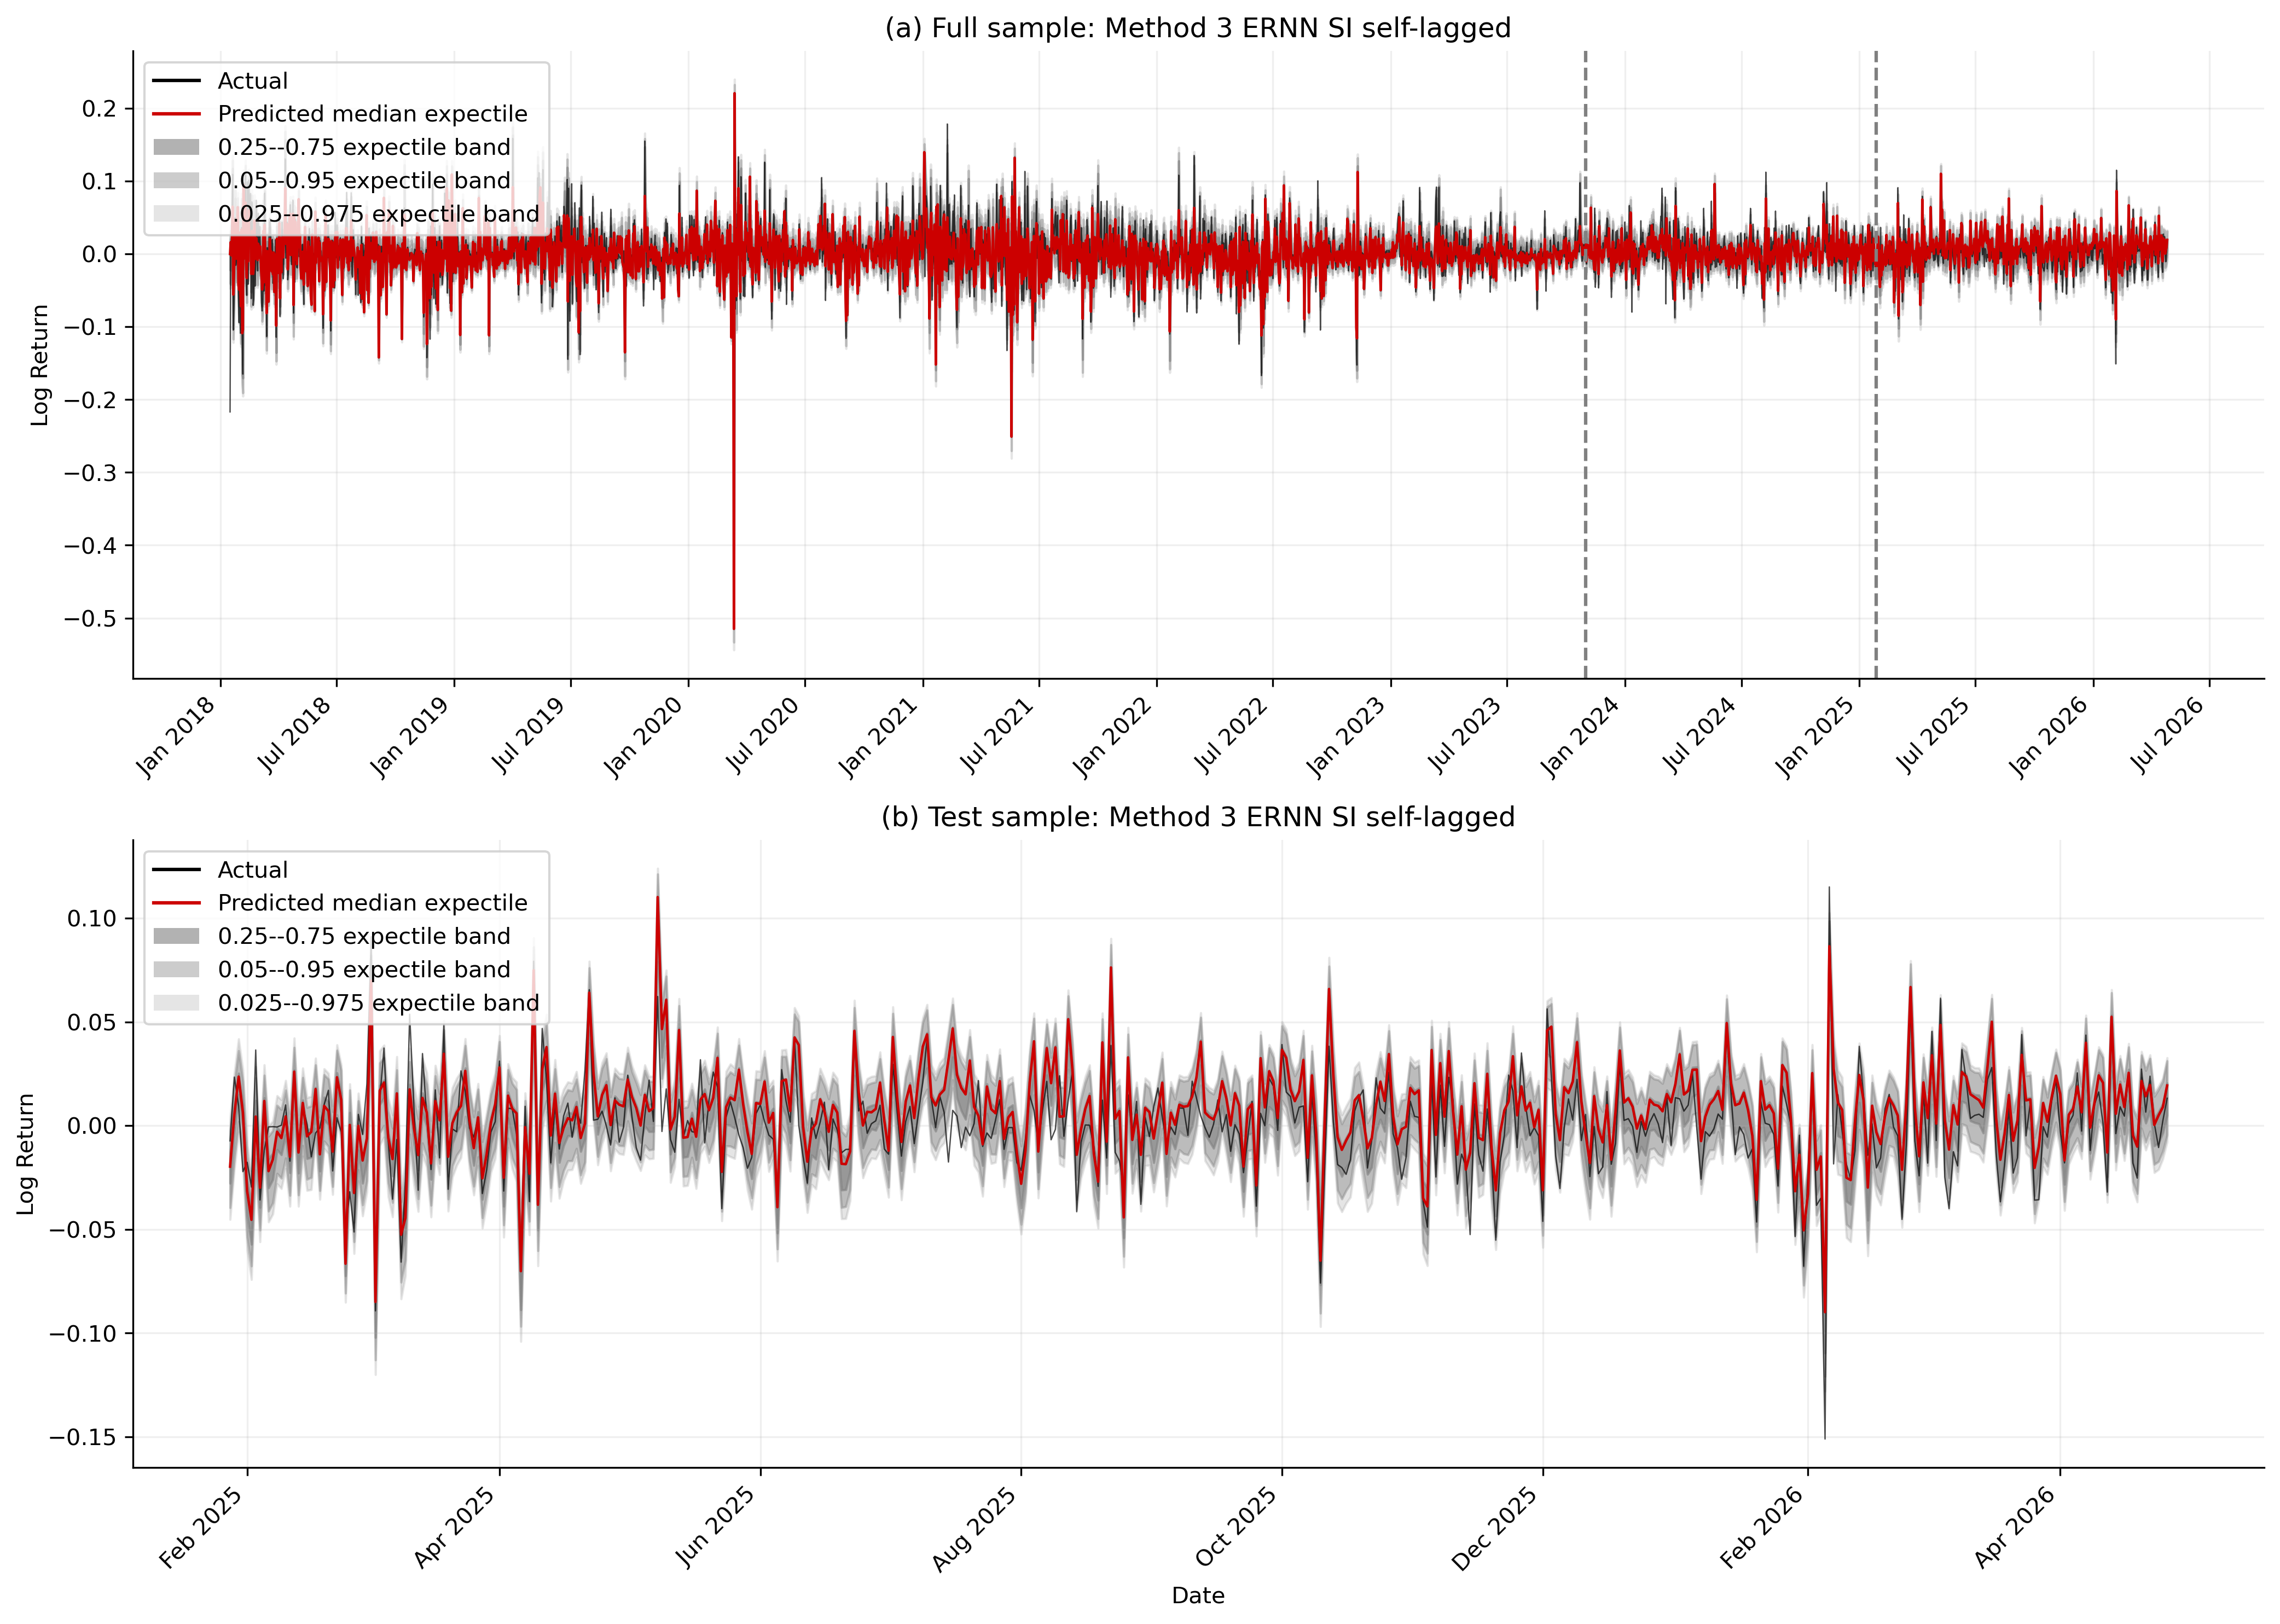

In [31]:
"""Plot and evaluate Method 3 ERNN SI self-lagged on the test sample.

This cell is self-contained: it reloads the prepared dataset and the saved
Method 3 checkpoint, so it does not rerun Optuna tuning.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

PSI_MARGIN = 1e-4
MODEL_DIR = Path("method3_spacing_ernn_si_self_results") / "ernn_si_self"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_ernn_si_self_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_ernn_si_self.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_ernn_si_self_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_ernn_si_self_test_summary.csv"
CROSSOVER_PATH = MODEL_DIR / "method3_spacing_ernn_si_self_crossover.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_ernn_si_self_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_ernn_si_self_test_predictions.csv"


class Method3SpacingPlotModel(nn.Module):
    """Checkpoint-compatible Method 3 model used only for evaluation."""

    def __init__(self, input_dim, config, direction=None):
        super().__init__()
        self.direction = direction
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append({
                "relu": nn.ReLU(),
                "elu": nn.ELU(),
                "gelu": nn.GELU(),
                "tanh": nn.Tanh(),
            }[config["activation"]])
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, reference=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6
        if self.direction is not None:
            if reference is None:
                raise ValueError("A non-median model requires its adjacent reference.")
            reference = reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = (
                reference + delta
                if self.direction == "upper"
                else reference - delta
            )
            return prediction, raw_delta, delta, sigma

        previous_statistical = y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions = []
        for t in range(len(y)):
            if t == 0:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                statistical_t = self._statistical_update(
                    previous_statistical, y[t - 1]
                )
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            predictions.append(hybrid_t)
            # SI self-lagged recursion uses the previous pure CARE output.
            previous_statistical = statistical_t
        return torch.stack(predictions), fnn_median, None, sigma


if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Finish Method 3 tuning first."
    )

df = pd.read_csv("BTCUSDT_full_features.csv", index_col="Date", parse_dates=True)
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]
feature_cols = [
    "Volatility", "RSI_14", "ATR_14", "ETH_LogReturns",
    "blocksize", "cost_per_transaction", "difficulty", "hash_rate",
    "n_payments_per_block", "n_transactions_per_block",
    "n_transactions_total", "avgblocksize",
]

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "ernn":
    raise ValueError("The checkpoint is not an ERNN checkpoint.")
if checkpoint.get("form") != "si" or checkpoint.get("lag") != "self":
    raise ValueError("The checkpoint is not the ERNN SI self-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingPlotModel(
        input_dim=len(feature_cols),
        config=checkpoint["configs"][level],
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index
if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(
        dates, values(0.025), values(0.975), color="#808080", alpha=0.20
    )
    axis.fill_between(
        dates, values(0.050), values(0.950), color="#808080", alpha=0.40
    )
    axis.fill_between(
        dates, values(0.250), values(0.750), color="#808080", alpha=0.60
    )
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, df["log_return"].to_numpy())
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 ERNN SI self-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(
    axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start
)
axes[1].set_title("(b) Test sample: Method 3 ERNN SI self-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median expectile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 expectile band"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 expectile band"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 expectile band"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)


def agd_nll(y, expectile, sigma, tau):
    residual = y - expectile
    tau_tensor = torch.tensor(tau, dtype=y.dtype, device=y.device)
    weight = torch.abs(tau_tensor - (residual < 0).to(y.dtype))
    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau_tensor)
            + torch.sqrt(torch.pi / (1.0 - tau_tensor))
        )
        - np.log(2.0)
    )
    return (
        torch.log(sigma)
        + constant
        + weight * residual.square() / sigma.square()
    ).mean()


def asymmetric_squared_error(y, expectile, tau):
    residual = y - expectile
    weight = torch.where(
        residual >= 0,
        torch.full_like(residual, tau),
        torch.full_like(residual, 1.0 - tau),
    )
    return (weight * residual.square()).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    metric_rows.append({
        "tau": level,
        "nll": agd_nll(y_test, prediction_test, sigmas[level], level).item(),
        "ase": asymmetric_squared_error(y_test, prediction_test, level).item(),
        "sigma": sigmas[level].item(),
    })
metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

crossover_rows = []
for index, (lower, upper) in enumerate(zip(LEVELS[:-1], LEVELS[1:])):
    count = int(pair_counts[index].item())
    crossover_rows.append({
        "lower_tau": lower,
        "upper_tau": upper,
        "violations": count,
        "rate": count / len(y_test),
        "tail_pair": (lower, upper) in {(0.025, 0.050), (0.950, 0.975)},
    })
crossover_df = pd.DataFrame(crossover_rows)
crossover_df.to_csv(CROSSOVER_PATH, index=False)

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "tau": level,
        "reference_tau": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 ERNN SI Self",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_ase": metrics_df["ase"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"e_{level:.3f}"] = (
        predictions[level][test_start:].cpu().numpy()
    )
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)

print("\nMETHOD 3 ERNN SI SELF-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nCrossover results:")
print(crossover_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")


# Conversion

In [33]:
# Load the Method 3 definitions without running Optuna tuning

import json

NOTEBOOK_PATH = "20260706 - ERNN Hybrid - SI self lagged.ipynb"

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as file:
    notebook_content = json.load(file)

method3_source = None

for cell in notebook_content["cells"]:
    source = "".join(cell.get("source", []))

    if (
        "Method 3, Specification 1: Hybrid ERNN SI self-lagged"
        in source
        and "def train_config" in source
        and "def run_one_model" in source
    ):
        method3_source = source
        break

if method3_source is None:
    raise RuntimeError(
        "The Method 3 definition cell could not be found."
    )

# Remove the command that starts the 200-trial tuning
method3_source = method3_source.rsplit(
    'if __name__ == "__main__":',
    1
)[0]

# Load classes, functions and constants only
exec(method3_source, globals())

print("Method 3 definitions loaded successfully.")
print("Optuna tuning was not run.")

Method 3 definitions loaded successfully.
Optuna tuning was not run.



Top-10 configurations selected for target level 0.025:
Architecture  1: trial=190, sum rank=7
Architecture  2: trial=198, sum rank=8
Architecture  3: trial=175, sum rank=17
Architecture  4: trial=102, sum rank=18
Architecture  5: trial=176, sum rank=20
Architecture  6: trial=162, sum rank=30
Architecture  7: trial=177, sum rank=35
Architecture  8: trial=196, sum rank=35
Architecture  9: trial=194, sum rank=38
Architecture 10: trial=171, sum rank=40

Tau point 1/100: tau=0.001000
  Trial 190: coverage=0.006623, mean delta=0.02469448
  Saved progress: 1/1000
  Trial 198: coverage=0.006623, mean delta=0.02876559
  Saved progress: 2/1000
  Trial 175: coverage=0.011038, mean delta=0.02204071
  Saved progress: 3/1000
  Trial 102: coverage=0.050773, mean delta=0.00763381
  Saved progress: 4/1000
  Trial 176: coverage=0.017660, mean delta=0.01790886
  Saved progress: 5/1000
  Trial 162: coverage=0.017660, mean delta=0.01990203
  Saved progress: 6/1000
  Trial 177: coverage=0.015453, mean delt

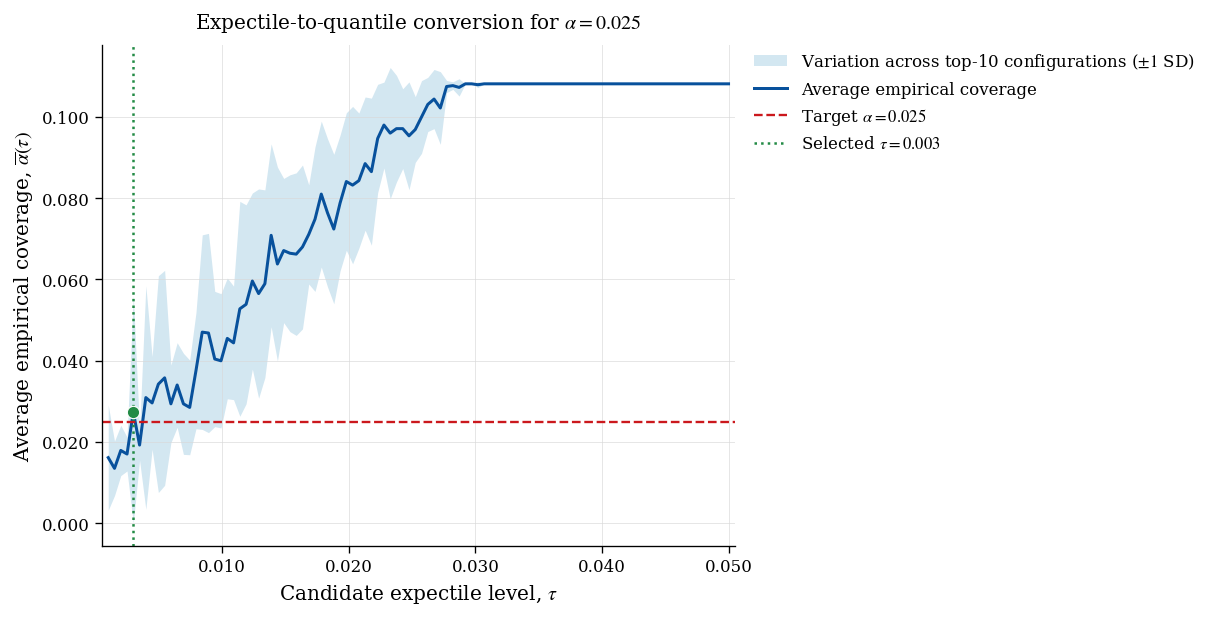


100-POINT CONVERSION COMPLETED
Target quantile alpha: 0.025
Candidate tau interval: [0.001, 0.050]
Number of tau points: 100
Architectures per tau point: 10
Total model refits: 1000
Selected expectile tau: 0.00297980
Average coverage at selected tau: 0.02737307
Absolute coverage error: 0.00237307

Raw results saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.025_100points_raw.csv

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.025_100points_summary.csv

Selected conversion saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.025_100points_estimated_tau.csv

Paper-style plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.025_100points_paper.png


In [37]:
# ============================================================
# EXPECTILE-TO-QUANTILE CONVERSION
# METHOD 3 — HYBRID ERNN SI SELF-LAGGED
# TARGET QUANTILE LEVEL: alpha = 0.025
#
# 100 equally spaced tau values × top 10 architectures
# Total: 1,000 model refits
#
# The Optuna search is NOT repeated.
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without rerunning Optuna
# ------------------------------------------------------------

required_method3_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
    "BASE_SEED",
    "ESTIMATION_ORDER",
    "REFERENCE_LEVEL",
    "DIRECTION",
]

missing_method3_definitions = [
    name
    for name in required_method3_definitions
    if name not in globals()
]

if missing_method3_definitions:

    NOTEBOOK_PATH = (
        "20260706 - ERNN Hybrid - SI self lagged.ipynb"
    )

    if not Path(NOTEBOOK_PATH).exists():
        raise FileNotFoundError(
            f"Notebook not found:\n{NOTEBOOK_PATH}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:

        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN SI self-lagged"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 definition cell "
            "could not be located."
        )

    # Remove the command that starts Optuna.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    # Load only the classes, functions and constants.
    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 definitions loaded. "
        "Optuna tuning was not run."
    )


# Check that the prepared data are available
required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data tensors are unavailable:\n"
        + ", ".join(missing_data)
        + "\nRun the data-preparation cells first."
    )


# ------------------------------------------------------------
# 2. Conversion settings
# ------------------------------------------------------------

TARGET_ALPHA = 0.025
TARGET_LEVEL = 0.025

REFERENCE_LEVEL_FOR_TARGET = 0.050
TARGET_DIRECTION = "lower"

N_ARCHITECTURES = 10
N_TAU_POINTS = 100

TAU_LOWER = 0.001
TAU_UPPER = 0.050

# Exactly 100 equally spaced candidate expectile levels
TAU_GRID = np.linspace(
    TAU_LOWER,
    TAU_UPPER,
    N_TAU_POINTS,
)

# Original Method 3 seed for level 0.025
CONVERSION_SEED = 2032

MODEL_DIR = (
    Path("method3_spacing_ernn_si_self_results")
    / "ernn_si_self"
)

CHECKPOINT_PATH = (
    MODEL_DIR
    / "method3_spacing_ernn_si_self_best.pt"
)

RANKING_PATH = (
    MODEL_DIR
    / f"ranking_level_{TARGET_LEVEL:.3f}.csv"
)

CONVERSION_DIR = MODEL_DIR / "conversion"

CONVERSION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# New filenames prevent the old 50-point results
# from being mixed with the new 100-point results.
RAW_RESULTS_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.025_100points_raw.csv"
)

SUMMARY_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.025_100points_summary.csv"
)

ESTIMATE_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.025_100points_estimated_tau.csv"
)

PLOT_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.025_100points_paper.png"
)


if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Method 3 checkpoint not found:\n"
        f"{CHECKPOINT_PATH}"
    )

if not RANKING_PATH.exists():
    raise FileNotFoundError(
        f"Method 3 ranking file not found:\n"
        f"{RANKING_PATH}"
    )


# ------------------------------------------------------------
# 3. Retrieve the top-10 saved configurations
# ------------------------------------------------------------

ranking_df = pd.read_csv(
    RANKING_PATH
)

ranking_df = ranking_df.sort_values(
    [
        "sum_rank",
        "nll",
        "calibration_penalty",
    ]
).reset_index(drop=True)

top10_df = ranking_df.head(
    N_ARCHITECTURES
).copy()


def convert_csv_boolean(value):
    """Convert a Boolean value loaded from CSV."""

    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return str(value).strip().lower() in {
        "true",
        "1",
        "yes",
    }


def configuration_from_row(row):
    """Reconstruct an Optuna configuration."""

    n_hidden_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": n_hidden_layers,
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": convert_csv_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(
            row["lr"]
        ),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        n_hidden_layers
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = int(
            row[
                f"hidden_dim_{layer_index}"
            ]
        )

    return config


top10_architectures = []

for architecture_index, row in (
    top10_df.iterrows()
):

    top10_architectures.append(
        {
            "architecture": (
                architecture_index + 1
            ),
            "trial": int(
                row["trial"]
            ),
            "sum_rank": float(
                row["sum_rank"]
            ),
            "config": (
                configuration_from_row(row)
            ),
        }
    )


print(
    "\nTop-10 configurations selected "
    "for target level 0.025:"
)

for architecture in top10_architectures:

    print(
        f"Architecture "
        f"{architecture['architecture']:2d}: "
        f"trial={architecture['trial']:3d}, "
        f"sum rank="
        f"{architecture['sum_rank']:.0f}"
    )


# ------------------------------------------------------------
# 4. Reconstruct the fixed adjacent Method 3 reference
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

if checkpoint.get("distribution") != "ernn":
    raise ValueError(
        "The checkpoint is not an ERNN model."
    )

if (
    checkpoint.get("form") != "si"
    or checkpoint.get("lag") != "self"
):
    raise ValueError(
        "The checkpoint is not the Method 3 "
        "ERNN SI self-lagged model."
    )


saved_train_predictions = {}
saved_val_predictions = {}

for level in ESTIMATION_ORDER:

    reference_level = REFERENCE_LEVEL[level]
    direction = DIRECTION[level]

    reference_train = (
        None
        if reference_level is None
        else saved_train_predictions[
            reference_level
        ]
    )

    reference_val = (
        None
        if reference_level is None
        else saved_val_predictions[
            reference_level
        ]
    )

    saved_model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="ernn",
        form="si",
        lag="self",
        direction=direction,
    )

    saved_model.load_state_dict(
        checkpoint[
            "model_state_dicts"
        ][level]
    )

    saved_model.eval()

    (
        prediction_train,
        prediction_val,
        _,
        _,
        _,
    ) = predict_train_val(
        saved_model,
        direction,
        reference_train,
        reference_val,
    )

    saved_train_predictions[level] = (
        prediction_train.detach()
    )

    saved_val_predictions[level] = (
        prediction_val.detach()
    )


# Fixed adjacent 0.050 reference forecasts
target_reference_train = (
    saved_train_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)

target_reference_val = (
    saved_val_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)


# ------------------------------------------------------------
# 5. Load previously completed 100-point results
# ------------------------------------------------------------

if RAW_RESULTS_PATH.exists():

    conversion_results = pd.read_csv(
        RAW_RESULTS_PATH
    )

    print(
        f"\nLoaded {len(conversion_results)} "
        "previously completed fits."
    )

else:

    conversion_results = pd.DataFrame()


def result_already_exists(
    tau_value,
    trial_number,
):
    """Check whether a tau–architecture fit is saved."""

    if conversion_results.empty:
        return False

    same_tau = np.isclose(
        conversion_results[
            "tau"
        ].to_numpy(dtype=float),
        float(tau_value),
        atol=1e-12,
        rtol=0.0,
    )

    same_trial = (
        conversion_results[
            "trial"
        ].to_numpy(dtype=int)
        == int(trial_number)
    )

    return bool(
        np.any(
            same_tau & same_trial
        )
    )


# ------------------------------------------------------------
# 6. Run 100 tau points × 10 configurations
# ------------------------------------------------------------

model_specification = (
    "ernn",
    "si",
    "self",
)

total_required_fits = (
    N_TAU_POINTS
    * N_ARCHITECTURES
)

for tau_index, candidate_tau in enumerate(
    TAU_GRID,
    start=1,
):

    candidate_tau = float(
        candidate_tau
    )

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Tau point "
        f"{tau_index}/{N_TAU_POINTS}: "
        f"tau={candidate_tau:.6f}"
    )

    for architecture in top10_architectures:

        trial_number = architecture["trial"]

        if result_already_exists(
            candidate_tau,
            trial_number,
        ):
            print(
                f"  Trial {trial_number}: "
                "already completed"
            )
            continue

        fitted_model = train_config(
            spec=model_specification,
            config=architecture["config"],
            level=candidate_tau,
            direction=TARGET_DIRECTION,
            q_ref_train=target_reference_train,
            q_ref_val=target_reference_val,
            seed=CONVERSION_SEED,
        )

        if fitted_model is None:
            print(
                f"  Trial {trial_number}: "
                "training failed"
            )
            continue

        (
            _,
            prediction_val,
            _,
            delta_val,
            sigma_val,
        ) = predict_train_val(
            fitted_model,
            TARGET_DIRECTION,
            target_reference_train,
            target_reference_val,
        )

        # Individual configuration-specific coverage
        empirical_alpha = (
            (y_val <= prediction_val)
            .float()
            .mean()
            .item()
        )

        validation_nll = single_level_nll(
            y_val,
            prediction_val,
            sigma_val,
            candidate_tau,
            "ernn",
        ).item()

        validation_ase = ernn_calibration(
            y_val,
            prediction_val,
            candidate_tau,
        )["ase"]

        mean_delta = (
            np.nan
            if delta_val is None
            else delta_val.mean().item()
        )

        result_row = pd.DataFrame(
            [
                {
                    "target_alpha": (
                        TARGET_ALPHA
                    ),
                    "tau": candidate_tau,
                    "architecture": (
                        architecture[
                            "architecture"
                        ]
                    ),
                    "trial": trial_number,
                    "sum_rank": (
                        architecture[
                            "sum_rank"
                        ]
                    ),
                    "empirical_alpha": (
                        empirical_alpha
                    ),
                    "validation_nll": (
                        validation_nll
                    ),
                    "validation_ase": (
                        validation_ase
                    ),
                    "mean_delta": mean_delta,
                }
            ]
        )

        conversion_results = pd.concat(
            [
                conversion_results,
                result_row,
            ],
            ignore_index=True,
        )

        # Save after every fit for resumability
        conversion_results.to_csv(
            RAW_RESULTS_PATH,
            index=False,
        )

        completed_fits = len(
            conversion_results
        )

        print(
            f"  Trial {trial_number}: "
            f"coverage={empirical_alpha:.6f}, "
            f"mean delta={mean_delta:.8f}"
        )

        print(
            f"  Saved progress: "
            f"{completed_fits}/"
            f"{total_required_fits}"
        )


# ------------------------------------------------------------
# 7. Check that all 1,000 fits are complete
# ------------------------------------------------------------

architecture_counts = (
    conversion_results
    .groupby("tau")["trial"]
    .nunique()
)

incomplete_tau_points = []

for candidate_tau in TAU_GRID:

    matching_tau = architecture_counts.index[
        np.isclose(
            architecture_counts.index.to_numpy(
                dtype=float
            ),
            float(candidate_tau),
            atol=1e-12,
            rtol=0.0,
        )
    ]

    if len(matching_tau) == 0:
        incomplete_tau_points.append(
            (
                float(candidate_tau),
                0,
            )
        )

    else:
        count = int(
            architecture_counts.loc[
                matching_tau[0]
            ]
        )

        if count < N_ARCHITECTURES:
            incomplete_tau_points.append(
                (
                    float(candidate_tau),
                    count,
                )
            )


if incomplete_tau_points:

    print(
        "\nIncomplete tau points:"
    )

    for tau_value, count in (
        incomplete_tau_points
    ):
        print(
            f"tau={tau_value:.6f}: "
            f"{count}/{N_ARCHITECTURES}"
        )

    raise RuntimeError(
        "Some conversion fits are incomplete. "
        "Rerun this cell to retry only the "
        "missing fits."
    )


# ------------------------------------------------------------
# 8. Average the ten coverage estimates at every tau
# ------------------------------------------------------------

conversion_summary = (
    conversion_results
    .groupby(
        "tau",
        as_index=False,
    )
    .agg(
        mean_empirical_alpha=(
            "empirical_alpha",
            "mean",
        ),
        sd_empirical_alpha=(
            "empirical_alpha",
            "std",
        ),
        minimum_empirical_alpha=(
            "empirical_alpha",
            "min",
        ),
        maximum_empirical_alpha=(
            "empirical_alpha",
            "max",
        ),
        mean_validation_nll=(
            "validation_nll",
            "mean",
        ),
        mean_validation_ase=(
            "validation_ase",
            "mean",
        ),
        mean_delta=(
            "mean_delta",
            "mean",
        ),
        number_of_architectures=(
            "trial",
            "nunique",
        ),
    )
    .sort_values("tau")
    .reset_index(drop=True)
)


conversion_summary[
    "lower_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "upper_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    + conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "absolute_coverage_error"
] = np.abs(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - TARGET_ALPHA
)

conversion_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 9. Select the closest candidate tau from the grid
# ------------------------------------------------------------

selected_index = conversion_summary[
    "absolute_coverage_error"
].idxmin()

selected_row = conversion_summary.loc[
    selected_index
]

estimated_tau = float(
    selected_row["tau"]
)

estimated_coverage = float(
    selected_row[
        "mean_empirical_alpha"
    ]
)

coverage_error = float(
    selected_row[
        "absolute_coverage_error"
    ]
)


estimated_result = pd.DataFrame(
    [
        {
            "target_alpha": (
                TARGET_ALPHA
            ),
            "estimated_tau": (
                estimated_tau
            ),
            "estimated_mean_coverage": (
                estimated_coverage
            ),
            "absolute_coverage_error": (
                coverage_error
            ),
            "tau_lower": TAU_LOWER,
            "tau_upper": TAU_UPPER,
            "number_of_tau_points": (
                N_TAU_POINTS
            ),
            "number_of_architectures": (
                N_ARCHITECTURES
            ),
            "conversion_sample": (
                "validation"
            ),
            "selection_method": (
                "minimum absolute "
                "coverage error"
            ),
        }
    ]
)

estimated_result.to_csv(
    ESTIMATE_PATH,
    index=False,
)


# ------------------------------------------------------------
# 10. Create a paper-style conversion plot
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    }
)


tau_values = conversion_summary[
    "tau"
].to_numpy(dtype=float)

mean_alpha_values = conversion_summary[
    "mean_empirical_alpha"
].to_numpy(dtype=float)

lower_band = conversion_summary[
    "lower_one_sd"
].to_numpy(dtype=float)

upper_band = conversion_summary[
    "upper_one_sd"
].to_numpy(dtype=float)


figure, axis = plt.subplots(
    figsize=(9.5, 5.8)
)


# Variability across the top-10 configurations
axis.fill_between(
    tau_values,
    lower_band,
    upper_band,
    color="#9ECAE1",
    alpha=0.45,
    linewidth=0,
    label=(
        "Variation across top-10 "
        r"configurations ($\pm1$ SD)"
    ),
)


# Average empirical coverage curve
axis.plot(
    tau_values,
    mean_alpha_values,
    color="#08519C",
    linewidth=1.8,
    label="Average empirical coverage",
)


# Target alpha
axis.axhline(
    TARGET_ALPHA,
    color="#CB181D",
    linestyle="--",
    linewidth=1.4,
    label=rf"Target $\alpha={TARGET_ALPHA:.3f}$",
)


# Selected tau
axis.axvline(
    estimated_tau,
    color="#238B45",
    linestyle=":",
    linewidth=1.5,
    label=rf"Selected $\tau={estimated_tau:.3f}$",
)

axis.scatter(
    estimated_tau,
    estimated_coverage,
    color="#238B45",
    edgecolor="white",
    linewidth=0.7,
    s=55,
    zorder=5,
)


# Labels
axis.set_xlabel(
    r"Candidate expectile level, $\tau$"
)

axis.set_ylabel(
    r"Average empirical coverage, "
    r"$\overline{\alpha}(\tau)$"
)

axis.set_title(
    r"Expectile-to-quantile conversion for "
    r"$\alpha=0.025$",
    pad=10,
)


# Display axes to three decimal places
axis.xaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)


# Clean paper-style appearance
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.tick_params(
    direction="out",
    length=4,
    width=0.8,
)

axis.grid(
    axis="both",
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.65,
)

axis.margins(
    x=0.01,
    y=0.05,
)


# Move legend outside
axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=False,
)


# Leave space for external legend
figure.subplots_adjust(
    right=0.68,
    bottom=0.16,
)


plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("100-POINT CONVERSION COMPLETED")
print("=" * 72)

print(
    f"Target quantile alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Candidate tau interval: "
    f"[{TAU_LOWER:.3f}, "
    f"{TAU_UPPER:.3f}]"
)

print(
    f"Number of tau points: "
    f"{N_TAU_POINTS}"
)

print(
    f"Architectures per tau point: "
    f"{N_ARCHITECTURES}"
)

print(
    f"Total model refits: "
    f"{len(conversion_results)}"
)

print(
    f"Selected expectile tau: "
    f"{estimated_tau:.8f}"
)

print(
    f"Average coverage at selected tau: "
    f"{estimated_coverage:.8f}"
)

print(
    f"Absolute coverage error: "
    f"{coverage_error:.8f}"
)

print(
    f"\nRaw results saved to:\n"
    f"{RAW_RESULTS_PATH}"
)

print(
    f"\nSummary saved to:\n"
    f"{SUMMARY_PATH}"
)

print(
    f"\nSelected conversion saved to:\n"
    f"{ESTIMATE_PATH}"
)

print(
    f"\nPaper-style plot saved to:\n"
    f"{PLOT_PATH}"
)


Top-10 configurations selected for target level 0.050:
Architecture  1: trial=161, sum rank=2
Architecture  2: trial=132, sum rank=6
Architecture  3: trial=179, sum rank=8
Architecture  4: trial=116, sum rank=10
Architecture  5: trial= 56, sum rank=10
Architecture  6: trial=175, sum rank=13
Architecture  7: trial= 50, sum rank=13
Architecture  8: trial= 70, sum rank=15
Architecture  9: trial=117, sum rank=19
Architecture 10: trial=168, sum rank=19

Tau point 1/100: tau=0.001000
  Trial 161: coverage=0.011038, mean delta=0.03641932
  Saved progress: 1/1000
  Trial 132: coverage=0.006623, mean delta=0.04008630
  Saved progress: 2/1000
  Trial 179: coverage=0.013245, mean delta=0.03477826
  Saved progress: 3/1000
  Trial 116: coverage=0.006623, mean delta=0.03972850
  Saved progress: 4/1000
  Trial 56: coverage=0.017660, mean delta=0.02758900
  Saved progress: 5/1000
  Trial 175: coverage=0.015453, mean delta=0.03266715
  Saved progress: 6/1000
  Trial 50: coverage=0.015453, mean delta=0

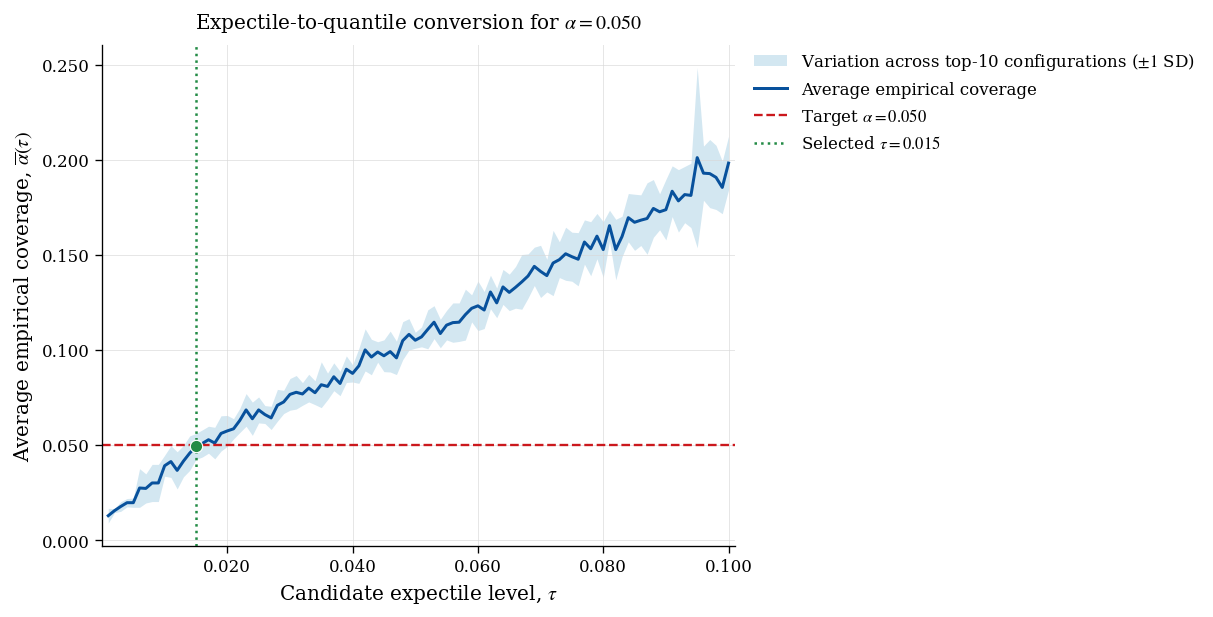


100-POINT CONVERSION COMPLETED
Target quantile alpha: 0.050
Candidate tau interval: [0.001, 0.100]
Number of tau points: 100
Configurations per tau point: 10
Total model refits: 1000
Selected expectile tau: 0.01500000
Average coverage at selected tau: 0.04922737
Absolute coverage error: 0.00077263

Raw results saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.050_100points_raw.csv

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.050_100points_summary.csv

Selected conversion saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.050_100points_estimated_tau.csv

Paper-style plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.050_100points_paper.png


In [39]:
# ============================================================
# EXPECTILE-TO-QUANTILE CONVERSION
# METHOD 3 — HYBRID ERNN SI SELF-LAGGED
# TARGET QUANTILE LEVEL: alpha = 0.050
#
# 100 equally spaced tau values × top 10 configurations
# Total: 1,000 model refits
# Optuna tuning is NOT repeated.
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without rerunning Optuna
# ------------------------------------------------------------

required_method3_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
    "ESTIMATION_ORDER",
    "REFERENCE_LEVEL",
    "DIRECTION",
]

missing_method3_definitions = [
    name
    for name in required_method3_definitions
    if name not in globals()
]

if missing_method3_definitions:

    NOTEBOOK_PATH = (
        "20260706 - ERNN Hybrid - SI self lagged.ipynb"
    )

    if not Path(NOTEBOOK_PATH).exists():
        raise FileNotFoundError(
            f"Notebook not found:\n{NOTEBOOK_PATH}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:

        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN SI self-lagged"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 definition cell "
            "could not be found."
        )

    # Remove the command that starts Optuna tuning.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    # Load only the Method 3 classes and functions.
    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 definitions loaded. "
        "Optuna tuning was not run."
    )


# Check that the prepared data are available
required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data tensors are unavailable:\n"
        + ", ".join(missing_data)
        + "\nRun the data-preparation cells first."
    )


# ------------------------------------------------------------
# 2. Conversion settings for alpha = 0.050
# ------------------------------------------------------------

TARGET_ALPHA = 0.050
TARGET_LEVEL = 0.050

# Method 3 construction:
# e_0.050 = e_0.250 - positive spacing
REFERENCE_LEVEL_FOR_TARGET = 0.250
TARGET_DIRECTION = "lower"

N_ARCHITECTURES = 10
N_TAU_POINTS = 100

TAU_LOWER = 0.001
TAU_UPPER = 0.100

# Exactly 100 equally spaced candidate expectile levels
TAU_GRID = np.linspace(
    TAU_LOWER,
    TAU_UPPER,
    N_TAU_POINTS,
)

# Original Method 3 seed:
# BASE_SEED + index of 0.050 = 2026 + 5
CONVERSION_SEED = 2031


MODEL_DIR = (
    Path("method3_spacing_ernn_si_self_results")
    / "ernn_si_self"
)

CHECKPOINT_PATH = (
    MODEL_DIR
    / "method3_spacing_ernn_si_self_best.pt"
)

RANKING_PATH = (
    MODEL_DIR
    / "ranking_level_0.050.csv"
)

CONVERSION_DIR = MODEL_DIR / "conversion"

CONVERSION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Separate files for the 0.050 conversion
RAW_RESULTS_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.050_100points_raw.csv"
)

SUMMARY_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.050_100points_summary.csv"
)

ESTIMATE_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.050_100points_estimated_tau.csv"
)

PLOT_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.050_100points_paper.png"
)


if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Method 3 checkpoint not found:\n"
        f"{CHECKPOINT_PATH}"
    )

if not RANKING_PATH.exists():
    raise FileNotFoundError(
        f"Method 3 ranking file not found:\n"
        f"{RANKING_PATH}"
    )


# ------------------------------------------------------------
# 3. Retrieve the top-10 saved configurations
# ------------------------------------------------------------

ranking_df = pd.read_csv(
    RANKING_PATH
)

ranking_df = ranking_df.sort_values(
    [
        "sum_rank",
        "nll",
        "calibration_penalty",
    ]
).reset_index(drop=True)

top10_df = ranking_df.head(
    N_ARCHITECTURES
).copy()


def convert_csv_boolean(value):
    """Convert Boolean values loaded from CSV."""

    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return str(value).strip().lower() in {
        "true",
        "1",
        "yes",
    }


def configuration_from_row(row):
    """Reconstruct one saved Optuna configuration."""

    n_hidden_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": n_hidden_layers,
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": convert_csv_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(
            row["lr"]
        ),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        n_hidden_layers
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = int(
            row[
                f"hidden_dim_{layer_index}"
            ]
        )

    return config


top10_architectures = []

for architecture_index, row in (
    top10_df.iterrows()
):

    top10_architectures.append(
        {
            "architecture": (
                architecture_index + 1
            ),
            "trial": int(
                row["trial"]
            ),
            "sum_rank": float(
                row["sum_rank"]
            ),
            "config": (
                configuration_from_row(row)
            ),
        }
    )


print(
    f"\nTop-10 configurations selected "
    f"for target level {TARGET_LEVEL:.3f}:"
)

for architecture in top10_architectures:

    print(
        f"Architecture "
        f"{architecture['architecture']:2d}: "
        f"trial={architecture['trial']:3d}, "
        f"sum rank="
        f"{architecture['sum_rank']:.0f}"
    )


# ------------------------------------------------------------
# 4. Reconstruct the fixed 0.250 Method 3 reference
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

if checkpoint.get("distribution") != "ernn":
    raise ValueError(
        "The checkpoint is not an ERNN model."
    )

if (
    checkpoint.get("form") != "si"
    or checkpoint.get("lag") != "self"
):
    raise ValueError(
        "The checkpoint is not the Method 3 "
        "ERNN SI self-lagged model."
    )


saved_train_predictions = {}
saved_val_predictions = {}

for level in ESTIMATION_ORDER:

    reference_level = REFERENCE_LEVEL[level]
    direction = DIRECTION[level]

    reference_train = (
        None
        if reference_level is None
        else saved_train_predictions[
            reference_level
        ]
    )

    reference_val = (
        None
        if reference_level is None
        else saved_val_predictions[
            reference_level
        ]
    )

    saved_model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="ernn",
        form="si",
        lag="self",
        direction=direction,
    )

    saved_model.load_state_dict(
        checkpoint[
            "model_state_dicts"
        ][level]
    )

    saved_model.eval()

    (
        prediction_train,
        prediction_val,
        _,
        _,
        _,
    ) = predict_train_val(
        saved_model,
        direction,
        reference_train,
        reference_val,
    )

    saved_train_predictions[level] = (
        prediction_train.detach()
    )

    saved_val_predictions[level] = (
        prediction_val.detach()
    )


# Fixed adjacent 0.250 reference forecasts
target_reference_train = (
    saved_train_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)

target_reference_val = (
    saved_val_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)


# ------------------------------------------------------------
# 5. Load previously completed results
# ------------------------------------------------------------

if RAW_RESULTS_PATH.exists():

    conversion_results = pd.read_csv(
        RAW_RESULTS_PATH
    )

    print(
        f"\nLoaded {len(conversion_results)} "
        "previously completed fits."
    )

else:

    conversion_results = pd.DataFrame()


def result_already_exists(
    tau_value,
    trial_number,
):
    """Check whether a tau–architecture fit is saved."""

    if conversion_results.empty:
        return False

    same_tau = np.isclose(
        conversion_results[
            "tau"
        ].to_numpy(dtype=float),
        float(tau_value),
        atol=1e-12,
        rtol=0.0,
    )

    same_trial = (
        conversion_results[
            "trial"
        ].to_numpy(dtype=int)
        == int(trial_number)
    )

    return bool(
        np.any(
            same_tau & same_trial
        )
    )


# ------------------------------------------------------------
# 6. Run 100 tau points × 10 configurations
# ------------------------------------------------------------

model_specification = (
    "ernn",
    "si",
    "self",
)

total_required_fits = (
    N_TAU_POINTS
    * N_ARCHITECTURES
)

for tau_index, candidate_tau in enumerate(
    TAU_GRID,
    start=1,
):

    candidate_tau = float(
        candidate_tau
    )

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Tau point "
        f"{tau_index}/{N_TAU_POINTS}: "
        f"tau={candidate_tau:.6f}"
    )

    for architecture in top10_architectures:

        trial_number = architecture["trial"]

        if result_already_exists(
            candidate_tau,
            trial_number,
        ):
            print(
                f"  Trial {trial_number}: "
                "already completed"
            )
            continue

        fitted_model = train_config(
            spec=model_specification,
            config=architecture["config"],
            level=candidate_tau,
            direction=TARGET_DIRECTION,
            q_ref_train=target_reference_train,
            q_ref_val=target_reference_val,
            seed=CONVERSION_SEED,
        )

        if fitted_model is None:
            print(
                f"  Trial {trial_number}: "
                "training failed"
            )
            continue

        (
            _,
            prediction_val,
            _,
            delta_val,
            sigma_val,
        ) = predict_train_val(
            fitted_model,
            TARGET_DIRECTION,
            target_reference_train,
            target_reference_val,
        )

        # Configuration-specific empirical coverage
        empirical_alpha = (
            (y_val <= prediction_val)
            .float()
            .mean()
            .item()
        )

        validation_nll = single_level_nll(
            y_val,
            prediction_val,
            sigma_val,
            candidate_tau,
            "ernn",
        ).item()

        validation_ase = ernn_calibration(
            y_val,
            prediction_val,
            candidate_tau,
        )["ase"]

        mean_delta = (
            np.nan
            if delta_val is None
            else delta_val.mean().item()
        )

        result_row = pd.DataFrame(
            [
                {
                    "target_alpha": (
                        TARGET_ALPHA
                    ),
                    "tau": candidate_tau,
                    "architecture": (
                        architecture[
                            "architecture"
                        ]
                    ),
                    "trial": trial_number,
                    "sum_rank": (
                        architecture[
                            "sum_rank"
                        ]
                    ),
                    "empirical_alpha": (
                        empirical_alpha
                    ),
                    "validation_nll": (
                        validation_nll
                    ),
                    "validation_ase": (
                        validation_ase
                    ),
                    "mean_delta": mean_delta,
                }
            ]
        )

        conversion_results = pd.concat(
            [
                conversion_results,
                result_row,
            ],
            ignore_index=True,
        )

        # Save after every fit
        conversion_results.to_csv(
            RAW_RESULTS_PATH,
            index=False,
        )

        completed_fits = len(
            conversion_results
        )

        print(
            f"  Trial {trial_number}: "
            f"coverage={empirical_alpha:.6f}, "
            f"mean delta={mean_delta:.8f}"
        )

        print(
            f"  Saved progress: "
            f"{completed_fits}/"
            f"{total_required_fits}"
        )


# ------------------------------------------------------------
# 7. Confirm that all 1,000 fits are complete
# ------------------------------------------------------------

architecture_counts = (
    conversion_results
    .groupby("tau")["trial"]
    .nunique()
)

incomplete_tau_points = []

for candidate_tau in TAU_GRID:

    matching_tau = architecture_counts.index[
        np.isclose(
            architecture_counts.index.to_numpy(
                dtype=float
            ),
            float(candidate_tau),
            atol=1e-12,
            rtol=0.0,
        )
    ]

    if len(matching_tau) == 0:

        incomplete_tau_points.append(
            (
                float(candidate_tau),
                0,
            )
        )

    else:

        number_completed = int(
            architecture_counts.loc[
                matching_tau[0]
            ]
        )

        if number_completed < N_ARCHITECTURES:

            incomplete_tau_points.append(
                (
                    float(candidate_tau),
                    number_completed,
                )
            )


if incomplete_tau_points:

    print(
        "\nIncomplete tau points:"
    )

    for tau_value, number_completed in (
        incomplete_tau_points
    ):

        print(
            f"tau={tau_value:.6f}: "
            f"{number_completed}/"
            f"{N_ARCHITECTURES}"
        )

    raise RuntimeError(
        "Some conversion fits are incomplete. "
        "Rerun this cell to retry only the "
        "missing fits."
    )


# ------------------------------------------------------------
# 8. Average the ten coverage estimates
# ------------------------------------------------------------

conversion_summary = (
    conversion_results
    .groupby(
        "tau",
        as_index=False,
    )
    .agg(
        mean_empirical_alpha=(
            "empirical_alpha",
            "mean",
        ),
        sd_empirical_alpha=(
            "empirical_alpha",
            "std",
        ),
        minimum_empirical_alpha=(
            "empirical_alpha",
            "min",
        ),
        maximum_empirical_alpha=(
            "empirical_alpha",
            "max",
        ),
        mean_validation_nll=(
            "validation_nll",
            "mean",
        ),
        mean_validation_ase=(
            "validation_ase",
            "mean",
        ),
        mean_delta=(
            "mean_delta",
            "mean",
        ),
        number_of_architectures=(
            "trial",
            "nunique",
        ),
    )
    .sort_values("tau")
    .reset_index(drop=True)
)


conversion_summary[
    "lower_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "upper_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    + conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "absolute_coverage_error"
] = np.abs(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - TARGET_ALPHA
)

conversion_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 9. Select the closest candidate tau
# ------------------------------------------------------------

selected_index = conversion_summary[
    "absolute_coverage_error"
].idxmin()

selected_row = conversion_summary.loc[
    selected_index
]

estimated_tau = float(
    selected_row["tau"]
)

estimated_coverage = float(
    selected_row[
        "mean_empirical_alpha"
    ]
)

coverage_error = float(
    selected_row[
        "absolute_coverage_error"
    ]
)


estimated_result = pd.DataFrame(
    [
        {
            "target_alpha": (
                TARGET_ALPHA
            ),
            "estimated_tau": (
                estimated_tau
            ),
            "estimated_mean_coverage": (
                estimated_coverage
            ),
            "absolute_coverage_error": (
                coverage_error
            ),
            "tau_lower": TAU_LOWER,
            "tau_upper": TAU_UPPER,
            "number_of_tau_points": (
                N_TAU_POINTS
            ),
            "number_of_architectures": (
                N_ARCHITECTURES
            ),
            "conversion_sample": (
                "validation"
            ),
            "selection_method": (
                "minimum absolute "
                "coverage error"
            ),
        }
    ]
)

estimated_result.to_csv(
    ESTIMATE_PATH,
    index=False,
)


# ------------------------------------------------------------
# 10. Paper-style plot
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    }
)


tau_values = conversion_summary[
    "tau"
].to_numpy(dtype=float)

mean_alpha_values = conversion_summary[
    "mean_empirical_alpha"
].to_numpy(dtype=float)

lower_band = conversion_summary[
    "lower_one_sd"
].to_numpy(dtype=float)

upper_band = conversion_summary[
    "upper_one_sd"
].to_numpy(dtype=float)


figure, axis = plt.subplots(
    figsize=(9.5, 5.8)
)


axis.fill_between(
    tau_values,
    lower_band,
    upper_band,
    color="#9ECAE1",
    alpha=0.45,
    linewidth=0,
    label=(
        "Variation across top-10 "
        r"configurations ($\pm1$ SD)"
    ),
)


axis.plot(
    tau_values,
    mean_alpha_values,
    color="#08519C",
    linewidth=1.8,
    label="Average empirical coverage",
)


axis.axhline(
    TARGET_ALPHA,
    color="#CB181D",
    linestyle="--",
    linewidth=1.4,
    label=rf"Target $\alpha={TARGET_ALPHA:.3f}$",
)


axis.axvline(
    estimated_tau,
    color="#238B45",
    linestyle=":",
    linewidth=1.5,
    label=rf"Selected $\tau={estimated_tau:.3f}$",
)


axis.scatter(
    estimated_tau,
    estimated_coverage,
    color="#238B45",
    edgecolor="white",
    linewidth=0.7,
    s=55,
    zorder=5,
)


axis.set_xlabel(
    r"Candidate expectile level, $\tau$"
)

axis.set_ylabel(
    r"Average empirical coverage, "
    r"$\overline{\alpha}(\tau)$"
)

axis.set_title(
    rf"Expectile-to-quantile conversion for "
    rf"$\alpha={TARGET_ALPHA:.3f}$",
    pad=10,
)


# Three decimal places
axis.xaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)


# Paper-style axes
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.tick_params(
    direction="out",
    length=4,
    width=0.8,
)

axis.grid(
    axis="both",
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.65,
)

axis.margins(
    x=0.01,
    y=0.05,
)


# Legend outside the plot
axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=False,
)


figure.subplots_adjust(
    right=0.68,
    bottom=0.16,
)


plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("100-POINT CONVERSION COMPLETED")
print("=" * 72)

print(
    f"Target quantile alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Candidate tau interval: "
    f"[{TAU_LOWER:.3f}, "
    f"{TAU_UPPER:.3f}]"
)

print(
    f"Number of tau points: "
    f"{N_TAU_POINTS}"
)

print(
    f"Configurations per tau point: "
    f"{N_ARCHITECTURES}"
)

print(
    f"Total model refits: "
    f"{len(conversion_results)}"
)

print(
    f"Selected expectile tau: "
    f"{estimated_tau:.8f}"
)

print(
    f"Average coverage at selected tau: "
    f"{estimated_coverage:.8f}"
)

print(
    f"Absolute coverage error: "
    f"{coverage_error:.8f}"
)

print(
    f"\nRaw results saved to:\n"
    f"{RAW_RESULTS_PATH}"
)

print(
    f"\nSummary saved to:\n"
    f"{SUMMARY_PATH}"
)

print(
    f"\nSelected conversion saved to:\n"
    f"{ESTIMATE_PATH}"
)

print(
    f"\nPaper-style plot saved to:\n"
    f"{PLOT_PATH}"
)


CONVERSION FOR TARGET alpha=0.250
Candidate tau interval: [0.010, 0.400]
Tau points: 100
Architectures: 10
Total required refits: 1000

Tau 1/100: 0.010000
  Trial 76: coverage=0.059603
  Saved progress: 1/1000
  Trial 68: coverage=0.048565
  Saved progress: 2/1000
  Trial 161: coverage=0.035320
  Saved progress: 3/1000
  Trial 185: coverage=0.030905
  Saved progress: 4/1000
  Trial 118: coverage=0.052980
  Saved progress: 5/1000
  Trial 193: coverage=0.035320
  Saved progress: 6/1000
  Trial 87: coverage=0.052980
  Saved progress: 7/1000
  Trial 115: coverage=0.044150
  Saved progress: 8/1000
  Trial 91: coverage=0.048565
  Saved progress: 9/1000
  Trial 186: coverage=0.026490
  Saved progress: 10/1000

Tau 2/100: 0.013939
  Trial 76: coverage=0.075055
  Saved progress: 11/1000
  Trial 68: coverage=0.090508
  Saved progress: 12/1000
  Trial 161: coverage=0.059603
  Saved progress: 13/1000
  Trial 185: coverage=0.046358
  Saved progress: 14/1000
  Trial 118: coverage=0.052980
  Saved 

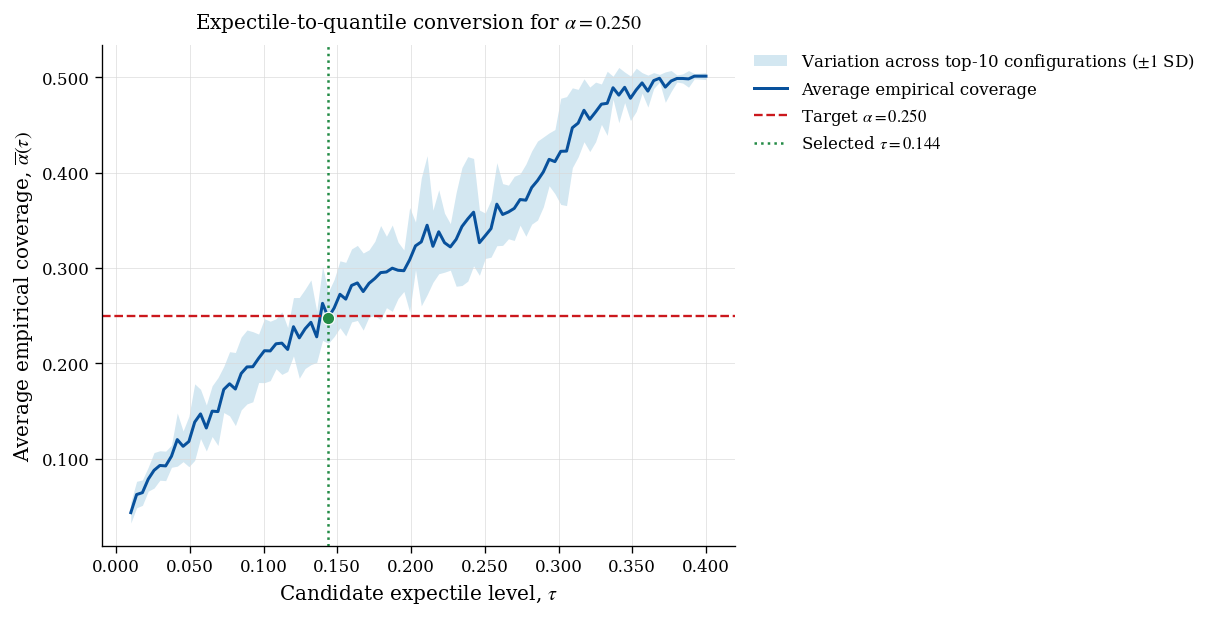


CONVERSION COMPLETED: alpha=0.250
Selected expectile tau: 0.14393939
Average coverage: 0.24790287
Absolute coverage error: 0.00209713

Plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.250_100points_paper.png

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.250_100points_summary.csv


In [41]:
# ============================================================
# REUSABLE METHOD 3 ERNN SI SELF CONVERSION FUNCTION
# AND CONVERSION FOR TARGET alpha = 0.250
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without rerunning Optuna
# ------------------------------------------------------------

required_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
    "ESTIMATION_ORDER",
    "REFERENCE_LEVEL",
    "DIRECTION",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:

    NOTEBOOK_PATH = (
        "20260706 - ERNN Hybrid - SI self lagged.ipynb"
    )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:

        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN SI self-lagged"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 definition cell "
            "could not be found."
        )

    # Remove the call that starts Optuna.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 definitions loaded. "
        "Optuna tuning was not run."
    )


required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "Run the data-preparation cells first. "
        "Missing: "
        + ", ".join(missing_data)
    )


# ------------------------------------------------------------
# 2. Reusable conversion function
# ------------------------------------------------------------

def run_method3_ernn_si_conversion(
    target_alpha,
    target_level,
    reference_level,
    direction,
    tau_lower,
    tau_upper,
    conversion_seed,
    number_of_tau_points=100,
    number_of_architectures=10,
):

    model_dir = (
        Path("method3_spacing_ernn_si_self_results")
        / "ernn_si_self"
    )

    checkpoint_path = (
        model_dir
        / "method3_spacing_ernn_si_self_best.pt"
    )

    ranking_path = (
        model_dir
        / f"ranking_level_{target_level:.3f}.csv"
    )

    conversion_dir = model_dir / "conversion"

    conversion_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    level_tag = f"{target_alpha:.3f}"

    raw_results_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"100points_raw.csv"
        )
    )

    summary_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"100points_summary.csv"
        )
    )

    estimate_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"100points_estimated_tau.csv"
        )
    )

    plot_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"100points_paper.png"
        )
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{checkpoint_path}"
        )

    if not ranking_path.exists():
        raise FileNotFoundError(
            f"Ranking CSV not found:\n"
            f"{ranking_path}"
        )

    tau_grid = np.linspace(
        tau_lower,
        tau_upper,
        number_of_tau_points,
    )

    # --------------------------------------------------------
    # Retrieve the top-10 configurations
    # --------------------------------------------------------

    ranking_df = pd.read_csv(
        ranking_path
    )

    ranking_df = ranking_df.sort_values(
        [
            "sum_rank",
            "nll",
            "calibration_penalty",
        ]
    ).reset_index(drop=True)

    top_df = ranking_df.head(
        number_of_architectures
    ).copy()

    def csv_boolean(value):

        if isinstance(
            value,
            (bool, np.bool_),
        ):
            return bool(value)

        return str(value).strip().lower() in {
            "true",
            "1",
            "yes",
        }

    def extract_config(row):

        n_hidden_layers = int(
            row["n_hidden_layers"]
        )

        config = {
            "n_hidden_layers": n_hidden_layers,
            "activation": str(
                row["activation"]
            ),
            "dropout": float(
                row["dropout"]
            ),
            "layernorm": csv_boolean(
                row["layernorm"]
            ),
            "weight_init": str(
                row["weight_init"]
            ),
            "lr": float(
                row["lr"]
            ),
            "optimizer": str(
                row["optimizer"]
            ),
            "weight_decay": float(
                row["weight_decay"]
            ),
            "gradient_clip": float(
                row["gradient_clip"]
            ),
            "patience": int(
                row["patience"]
            ),
        }

        for layer_index in range(
            n_hidden_layers
        ):
            config[
                f"hidden_dim_{layer_index}"
            ] = int(
                row[
                    f"hidden_dim_{layer_index}"
                ]
            )

        return config

    architectures = []

    for architecture_index, row in (
        top_df.iterrows()
    ):

        architectures.append(
            {
                "architecture": (
                    architecture_index + 1
                ),
                "trial": int(
                    row["trial"]
                ),
                "sum_rank": float(
                    row["sum_rank"]
                ),
                "config": extract_config(
                    row
                ),
            }
        )

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"CONVERSION FOR TARGET "
        f"alpha={target_alpha:.3f}"
    )

    print(
        "=" * 72
    )

    print(
        f"Candidate tau interval: "
        f"[{tau_lower:.3f}, "
        f"{tau_upper:.3f}]"
    )

    print(
        f"Tau points: "
        f"{number_of_tau_points}"
    )

    print(
        f"Architectures: "
        f"{number_of_architectures}"
    )

    print(
        f"Total required refits: "
        f"{number_of_tau_points * number_of_architectures}"
    )

    # --------------------------------------------------------
    # Reconstruct the fixed adjacent reference
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    if checkpoint.get("distribution") != "ernn":
        raise ValueError(
            "The checkpoint is not an ERNN model."
        )

    if (
        checkpoint.get("form") != "si"
        or checkpoint.get("lag") != "self"
    ):
        raise ValueError(
            "The checkpoint is not ERNN SI "
            "self-lagged."
        )

    if reference_level is None:

        target_reference_train = None
        target_reference_val = None

    else:

        saved_train_predictions = {}
        saved_val_predictions = {}

        for level in ESTIMATION_ORDER:

            adjacent_level = REFERENCE_LEVEL[level]
            saved_direction = DIRECTION[level]

            adjacent_train = (
                None
                if adjacent_level is None
                else saved_train_predictions[
                    adjacent_level
                ]
            )

            adjacent_val = (
                None
                if adjacent_level is None
                else saved_val_predictions[
                    adjacent_level
                ]
            )

            saved_model = Method3SpacingModel(
                input_dim=X_train.shape[1],
                config=checkpoint[
                    "configs"
                ][level],
                distribution="ernn",
                form="si",
                lag="self",
                direction=saved_direction,
            )

            saved_model.load_state_dict(
                checkpoint[
                    "model_state_dicts"
                ][level]
            )

            saved_model.eval()

            (
                prediction_train,
                prediction_val,
                _,
                _,
                _,
            ) = predict_train_val(
                saved_model,
                saved_direction,
                adjacent_train,
                adjacent_val,
            )

            saved_train_predictions[level] = (
                prediction_train.detach()
            )

            saved_val_predictions[level] = (
                prediction_val.detach()
            )

        target_reference_train = (
            saved_train_predictions[
                reference_level
            ]
        )

        target_reference_val = (
            saved_val_predictions[
                reference_level
            ]
        )

    # --------------------------------------------------------
    # Load any completed results
    # --------------------------------------------------------

    if raw_results_path.exists():

        conversion_results = pd.read_csv(
            raw_results_path
        )

        print(
            f"Loaded {len(conversion_results)} "
            "previously completed fits."
        )

    else:

        conversion_results = pd.DataFrame()

    def result_exists(
        tau_value,
        trial_number,
    ):

        if conversion_results.empty:
            return False

        same_tau = np.isclose(
            conversion_results[
                "tau"
            ].to_numpy(dtype=float),
            float(tau_value),
            atol=1e-12,
            rtol=0.0,
        )

        same_trial = (
            conversion_results[
                "trial"
            ].to_numpy(dtype=int)
            == int(trial_number)
        )

        return bool(
            np.any(
                same_tau & same_trial
            )
        )

    # --------------------------------------------------------
    # Run the conversion fits
    # --------------------------------------------------------

    model_specification = (
        "ernn",
        "si",
        "self",
    )

    total_required = (
        number_of_tau_points
        * number_of_architectures
    )

    for tau_index, candidate_tau in enumerate(
        tau_grid,
        start=1,
    ):

        candidate_tau = float(
            candidate_tau
        )

        print(
            f"\nTau {tau_index}/"
            f"{number_of_tau_points}: "
            f"{candidate_tau:.6f}"
        )

        for architecture in architectures:

            trial_number = (
                architecture["trial"]
            )

            if result_exists(
                candidate_tau,
                trial_number,
            ):

                print(
                    f"  Trial {trial_number}: "
                    "already completed"
                )

                continue

            fitted_model = train_config(
                spec=model_specification,
                config=architecture[
                    "config"
                ],
                level=candidate_tau,
                direction=direction,
                q_ref_train=(
                    target_reference_train
                ),
                q_ref_val=(
                    target_reference_val
                ),
                seed=conversion_seed,
            )

            if fitted_model is None:

                print(
                    f"  Trial {trial_number}: "
                    "training failed"
                )

                continue

            (
                _,
                prediction_val,
                _,
                delta_val,
                sigma_val,
            ) = predict_train_val(
                fitted_model,
                direction,
                target_reference_train,
                target_reference_val,
            )

            empirical_alpha = (
                (y_val <= prediction_val)
                .float()
                .mean()
                .item()
            )

            validation_nll = (
                single_level_nll(
                    y_val,
                    prediction_val,
                    sigma_val,
                    candidate_tau,
                    "ernn",
                ).item()
            )

            validation_ase = (
                ernn_calibration(
                    y_val,
                    prediction_val,
                    candidate_tau,
                )["ase"]
            )

            mean_delta = (
                np.nan
                if delta_val is None
                else delta_val.mean().item()
            )

            result_row = pd.DataFrame(
                [
                    {
                        "target_alpha": (
                            target_alpha
                        ),
                        "tau": candidate_tau,
                        "architecture": (
                            architecture[
                                "architecture"
                            ]
                        ),
                        "trial": trial_number,
                        "sum_rank": (
                            architecture[
                                "sum_rank"
                            ]
                        ),
                        "empirical_alpha": (
                            empirical_alpha
                        ),
                        "validation_nll": (
                            validation_nll
                        ),
                        "validation_ase": (
                            validation_ase
                        ),
                        "mean_delta": (
                            mean_delta
                        ),
                    }
                ]
            )

            conversion_results = pd.concat(
                [
                    conversion_results,
                    result_row,
                ],
                ignore_index=True,
            )

            conversion_results.to_csv(
                raw_results_path,
                index=False,
            )

            print(
                f"  Trial {trial_number}: "
                f"coverage="
                f"{empirical_alpha:.6f}"
            )

            print(
                f"  Saved progress: "
                f"{len(conversion_results)}/"
                f"{total_required}"
            )

    # --------------------------------------------------------
    # Check completion
    # --------------------------------------------------------

    architecture_counts = (
        conversion_results
        .groupby("tau")["trial"]
        .nunique()
    )

    incomplete_points = []

    for candidate_tau in tau_grid:

        matching_tau = (
            architecture_counts.index[
                np.isclose(
                    architecture_counts.index
                    .to_numpy(dtype=float),
                    float(candidate_tau),
                    atol=1e-12,
                    rtol=0.0,
                )
            ]
        )

        if len(matching_tau) == 0:

            incomplete_points.append(
                (
                    float(candidate_tau),
                    0,
                )
            )

        else:

            completed_count = int(
                architecture_counts.loc[
                    matching_tau[0]
                ]
            )

            if (
                completed_count
                < number_of_architectures
            ):

                incomplete_points.append(
                    (
                        float(candidate_tau),
                        completed_count,
                    )
                )

    if incomplete_points:

        print(
            "\nIncomplete tau points:"
        )

        for tau_value, count in (
            incomplete_points
        ):

            print(
                f"tau={tau_value:.6f}: "
                f"{count}/"
                f"{number_of_architectures}"
            )

        raise RuntimeError(
            "Some conversion fits are incomplete. "
            "Rerun this cell to retry them."
        )

    # --------------------------------------------------------
    # Calculate average coverage
    # --------------------------------------------------------

    conversion_summary = (
        conversion_results
        .groupby(
            "tau",
            as_index=False,
        )
        .agg(
            mean_empirical_alpha=(
                "empirical_alpha",
                "mean",
            ),
            sd_empirical_alpha=(
                "empirical_alpha",
                "std",
            ),
            minimum_empirical_alpha=(
                "empirical_alpha",
                "min",
            ),
            maximum_empirical_alpha=(
                "empirical_alpha",
                "max",
            ),
            mean_validation_nll=(
                "validation_nll",
                "mean",
            ),
            mean_validation_ase=(
                "validation_ase",
                "mean",
            ),
            mean_delta=(
                "mean_delta",
                "mean",
            ),
            number_of_architectures=(
                "trial",
                "nunique",
            ),
        )
        .sort_values("tau")
        .reset_index(drop=True)
    )

    conversion_summary[
        "lower_one_sd"
    ] = np.clip(
        conversion_summary[
            "mean_empirical_alpha"
        ]
        - conversion_summary[
            "sd_empirical_alpha"
        ],
        0.0,
        1.0,
    )

    conversion_summary[
        "upper_one_sd"
    ] = np.clip(
        conversion_summary[
            "mean_empirical_alpha"
        ]
        + conversion_summary[
            "sd_empirical_alpha"
        ],
        0.0,
        1.0,
    )

    conversion_summary[
        "absolute_coverage_error"
    ] = np.abs(
        conversion_summary[
            "mean_empirical_alpha"
        ]
        - target_alpha
    )

    conversion_summary.to_csv(
        summary_path,
        index=False,
    )

    # --------------------------------------------------------
    # Select the closest grid point
    # --------------------------------------------------------

    selected_index = (
        conversion_summary[
            "absolute_coverage_error"
        ].idxmin()
    )

    selected_row = (
        conversion_summary.loc[
            selected_index
        ]
    )

    estimated_tau = float(
        selected_row["tau"]
    )

    estimated_coverage = float(
        selected_row[
            "mean_empirical_alpha"
        ]
    )

    coverage_error = float(
        selected_row[
            "absolute_coverage_error"
        ]
    )

    estimated_result = pd.DataFrame(
        [
            {
                "target_alpha": (
                    target_alpha
                ),
                "estimated_tau": (
                    estimated_tau
                ),
                "estimated_mean_coverage": (
                    estimated_coverage
                ),
                "absolute_coverage_error": (
                    coverage_error
                ),
                "tau_lower": tau_lower,
                "tau_upper": tau_upper,
                "number_of_tau_points": (
                    number_of_tau_points
                ),
                "number_of_architectures": (
                    number_of_architectures
                ),
                "conversion_sample": (
                    "validation"
                ),
                "selection_method": (
                    "minimum absolute "
                    "coverage error"
                ),
            }
        ]
    )

    estimated_result.to_csv(
        estimate_path,
        index=False,
    )

    # --------------------------------------------------------
    # Paper-style plot
    # --------------------------------------------------------

    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "stix",
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 12,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.linewidth": 0.8,
            "savefig.dpi": 300,
        }
    )

    tau_values = (
        conversion_summary["tau"]
        .to_numpy(dtype=float)
    )

    mean_alpha_values = (
        conversion_summary[
            "mean_empirical_alpha"
        ].to_numpy(dtype=float)
    )

    lower_band = (
        conversion_summary[
            "lower_one_sd"
        ].to_numpy(dtype=float)
    )

    upper_band = (
        conversion_summary[
            "upper_one_sd"
        ].to_numpy(dtype=float)
    )

    figure, axis = plt.subplots(
        figsize=(9.5, 5.8)
    )

    axis.fill_between(
        tau_values,
        lower_band,
        upper_band,
        color="#9ECAE1",
        alpha=0.45,
        linewidth=0,
        label=(
            "Variation across top-10 "
            r"configurations ($\pm1$ SD)"
        ),
    )

    axis.plot(
        tau_values,
        mean_alpha_values,
        color="#08519C",
        linewidth=1.8,
        label="Average empirical coverage",
    )

    axis.axhline(
        target_alpha,
        color="#CB181D",
        linestyle="--",
        linewidth=1.4,
        label=(
            rf"Target $\alpha="
            rf"{target_alpha:.3f}$"
        ),
    )

    axis.axvline(
        estimated_tau,
        color="#238B45",
        linestyle=":",
        linewidth=1.5,
        label=(
            rf"Selected $\tau="
            rf"{estimated_tau:.3f}$"
        ),
    )

    axis.scatter(
        estimated_tau,
        estimated_coverage,
        color="#238B45",
        edgecolor="white",
        linewidth=0.7,
        s=55,
        zorder=5,
    )

    axis.set_xlabel(
        r"Candidate expectile level, $\tau$"
    )

    axis.set_ylabel(
        r"Average empirical coverage, "
        r"$\overline{\alpha}(\tau)$"
    )

    axis.set_title(
        rf"Expectile-to-quantile conversion for "
        rf"$\alpha={target_alpha:.3f}$",
        pad=10,
    )

    axis.xaxis.set_major_formatter(
        FormatStrFormatter("%.3f")
    )

    axis.yaxis.set_major_formatter(
        FormatStrFormatter("%.3f")
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.tick_params(
        direction="out",
        length=4,
        width=0.8,
    )

    axis.grid(
        color="#D9D9D9",
        linewidth=0.6,
        alpha=0.65,
    )

    axis.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
        frameon=False,
    )

    figure.subplots_adjust(
        right=0.68,
        bottom=0.16,
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    # --------------------------------------------------------
    # Final report
    # --------------------------------------------------------

    print("\n" + "=" * 72)

    print(
        f"CONVERSION COMPLETED: "
        f"alpha={target_alpha:.3f}"
    )

    print("=" * 72)

    print(
        f"Selected expectile tau: "
        f"{estimated_tau:.8f}"
    )

    print(
        f"Average coverage: "
        f"{estimated_coverage:.8f}"
    )

    print(
        f"Absolute coverage error: "
        f"{coverage_error:.8f}"
    )

    print(
        f"\nPlot saved to:\n"
        f"{plot_path}"
    )

    print(
        f"\nSummary saved to:\n"
        f"{summary_path}"
    )

    return {
        "target_alpha": target_alpha,
        "estimated_tau": estimated_tau,
        "estimated_coverage": (
            estimated_coverage
        ),
        "coverage_error": coverage_error,
        "summary": conversion_summary,
        "plot_path": plot_path,
    }


# ------------------------------------------------------------
# 3. Run conversion for target alpha = 0.250
# ------------------------------------------------------------

conversion_0250 = (
    run_method3_ernn_si_conversion(
        target_alpha=0.250,
        target_level=0.250,
        reference_level=0.500,
        direction="lower",
        tau_lower=0.010,
        tau_upper=0.400,
        conversion_seed=2030,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)

In [49]:
# ============================================================
# REPAIR FLOATING-POINT TAU VALUES FOR PLOT 4
# No models are retrained.
# ============================================================

from pathlib import Path
import pandas as pd

RAW_RESULTS_PATH = (
    Path("method3_spacing_ernn_si_self_results")
    / "ernn_si_self"
    / "conversion"
    / "conversion_alpha_0.500_100points_raw.csv"
)

conversion_results = pd.read_csv(
    RAW_RESULTS_PATH
)

# Standardise numerically equivalent tau values
conversion_results["tau"] = (
    conversion_results["tau"]
    .astype(float)
    .round(12)
)

# Remove any genuinely duplicated architecture–tau rows
conversion_results = (
    conversion_results
    .drop_duplicates(
        subset=["tau", "trial"],
        keep="last",
    )
    .sort_values(
        ["tau", "architecture"]
    )
    .reset_index(drop=True)
)

conversion_results.to_csv(
    RAW_RESULTS_PATH,
    index=False,
)

print(
    f"Repaired rows: {len(conversion_results)}"
)

print(
    "Unique tau points:",
    conversion_results["tau"].nunique(),
)

print(
    "Architectures per tau point:"
)

print(
    conversion_results
    .groupby("tau")["trial"]
    .nunique()
    .value_counts()
    .sort_index()
)

Repaired rows: 1000
Unique tau points: 100
Architectures per tau point:
trial
10    100
Name: count, dtype: int64



Top-10 configurations selected for target level 0.500:
Architecture  1: trial=170, sum rank=11
Architecture  2: trial=199, sum rank=13
Architecture  3: trial=180, sum rank=15
Architecture  4: trial=197, sum rank=18
Architecture  5: trial=171, sum rank=20
Architecture  6: trial=198, sum rank=22
Architecture  7: trial=196, sum rank=23
Architecture  8: trial=115, sum rank=26
Architecture  9: trial=176, sum rank=33
Architecture 10: trial=193, sum rank=36

Loaded 1000 previously completed fits.

Tau point 1/100: tau=0.100000
  Trial 170: already completed
  Trial 199: already completed
  Trial 180: already completed
  Trial 197: already completed
  Trial 171: already completed
  Trial 198: already completed
  Trial 196: already completed
  Trial 115: already completed
  Trial 176: already completed
  Trial 193: already completed

Tau point 2/100: tau=0.108081
  Trial 170: already completed
  Trial 199: already completed
  Trial 180: already completed
  Trial 197: already completed
  Trial 

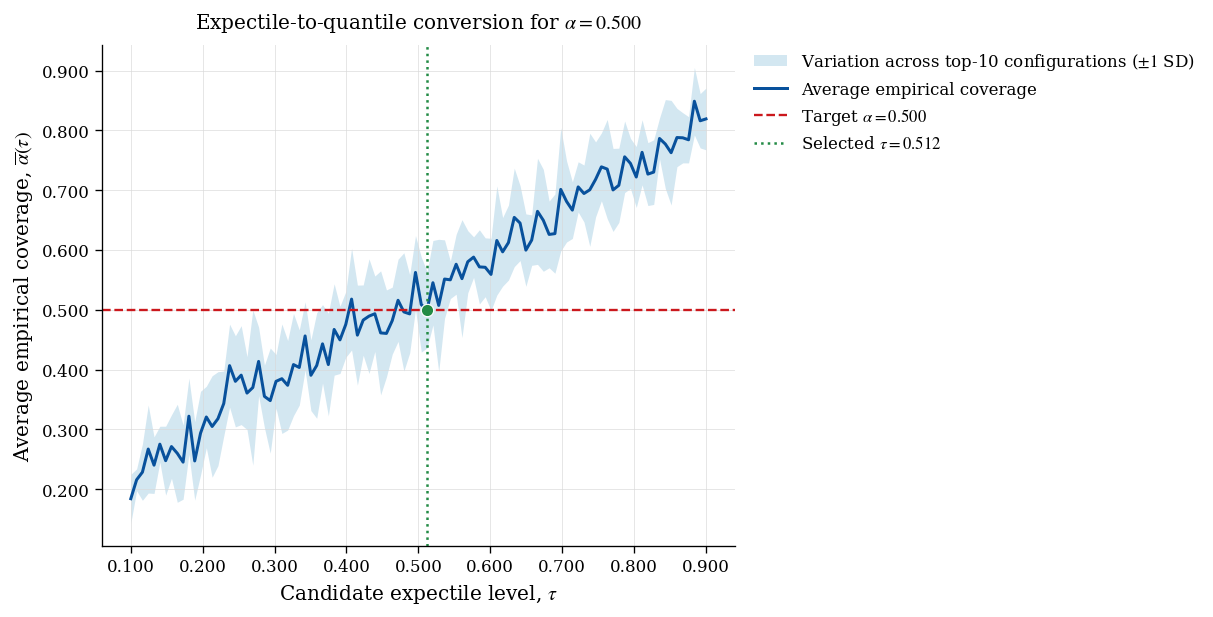


MEDIAN CONVERSION COMPLETED
Target quantile alpha: 0.500
Candidate tau interval: [0.100, 0.900]
Selected expectile tau: 0.51212121
Average coverage at selected tau: 0.50022075
Absolute coverage error: 0.00022075

Raw results saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.500_100points_raw.csv

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.500_100points_summary.csv

Selected conversion saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.500_100points_estimated_tau.csv

Paper-style plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.500_100points_paper.png


In [51]:
# ============================================================
# STANDALONE CONVERSION — PLOT 4
# METHOD 3 HYBRID ERNN SI SELF-LAGGED
# TARGET QUANTILE LEVEL: alpha = 0.500
#
# 100 tau points × top 10 configurations
# Resumes from saved results if interrupted.
# Optuna tuning is NOT repeated.
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without running Optuna
# ------------------------------------------------------------

required_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:

    NOTEBOOK_PATH = (
        "20260706 - ERNN Hybrid - SI self lagged.ipynb"
    )

    if not Path(NOTEBOOK_PATH).exists():
        raise FileNotFoundError(
            f"Notebook not found:\n{NOTEBOOK_PATH}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:

        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN SI self-lagged"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 definition cell "
            "could not be found."
        )

    # Remove the command that starts Optuna tuning.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 definitions loaded. "
        "Optuna tuning was not run."
    )


# Check prepared data
required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data tensors are unavailable:\n"
        + ", ".join(missing_data)
        + "\nRun the data-preparation cells first."
    )


# ------------------------------------------------------------
# 2. Conversion settings
# ------------------------------------------------------------

TARGET_ALPHA = 0.500
TARGET_LEVEL = 0.500

# The median is the central Method 3 hybrid model.
# It does not require an adjacent reference.
TARGET_DIRECTION = None

N_ARCHITECTURES = 10
N_TAU_POINTS = 100

TAU_LOWER = 0.100
TAU_UPPER = 0.900

TAU_GRID = np.linspace(
    TAU_LOWER,
    TAU_UPPER,
    N_TAU_POINTS,
)

# Original Method 3 seed for the median
CONVERSION_SEED = 2026


MODEL_DIR = (
    Path("method3_spacing_ernn_si_self_results")
    / "ernn_si_self"
)

RANKING_PATH = (
    MODEL_DIR
    / "ranking_level_0.500.csv"
)

CONVERSION_DIR = MODEL_DIR / "conversion"

CONVERSION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


RAW_RESULTS_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.500_100points_raw.csv"
)

SUMMARY_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.500_100points_summary.csv"
)

ESTIMATE_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.500_100points_estimated_tau.csv"
)

PLOT_PATH = (
    CONVERSION_DIR
    / "conversion_alpha_0.500_100points_paper.png"
)


if not RANKING_PATH.exists():
    raise FileNotFoundError(
        f"Ranking CSV not found:\n"
        f"{RANKING_PATH}"
    )


# ------------------------------------------------------------
# 3. Retrieve the top-10 median configurations
# ------------------------------------------------------------

ranking_df = pd.read_csv(
    RANKING_PATH
)

ranking_df = ranking_df.sort_values(
    [
        "sum_rank",
        "nll",
        "calibration_penalty",
    ]
).reset_index(drop=True)

top10_df = ranking_df.head(
    N_ARCHITECTURES
).copy()


def convert_csv_boolean(value):

    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return str(value).strip().lower() in {
        "true",
        "1",
        "yes",
    }


def configuration_from_row(row):

    n_hidden_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": n_hidden_layers,
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": convert_csv_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(
            row["lr"]
        ),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        n_hidden_layers
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = int(
            row[
                f"hidden_dim_{layer_index}"
            ]
        )

    return config


top10_architectures = []

for architecture_index, row in (
    top10_df.iterrows()
):

    top10_architectures.append(
        {
            "architecture": (
                architecture_index + 1
            ),
            "trial": int(
                row["trial"]
            ),
            "sum_rank": float(
                row["sum_rank"]
            ),
            "config": (
                configuration_from_row(row)
            ),
        }
    )


print(
    "\nTop-10 configurations selected "
    "for target level 0.500:"
)

for architecture in top10_architectures:

    print(
        f"Architecture "
        f"{architecture['architecture']:2d}: "
        f"trial={architecture['trial']:3d}, "
        f"sum rank="
        f"{architecture['sum_rank']:.0f}"
    )


# ------------------------------------------------------------
# 4. Load partial results, if they exist
# ------------------------------------------------------------

if RAW_RESULTS_PATH.exists():

    conversion_results = pd.read_csv(
        RAW_RESULTS_PATH
    )

    print(
        f"\nLoaded {len(conversion_results)} "
        "previously completed fits."
    )

else:

    conversion_results = pd.DataFrame()


def result_already_exists(
    tau_value,
    trial_number,
):

    if conversion_results.empty:
        return False

    same_tau = np.isclose(
        conversion_results[
            "tau"
        ].to_numpy(dtype=float),
        float(tau_value),
        atol=1e-12,
        rtol=0.0,
    )

    same_trial = (
        conversion_results[
            "trial"
        ].to_numpy(dtype=int)
        == int(trial_number)
    )

    return bool(
        np.any(
            same_tau & same_trial
        )
    )


# ------------------------------------------------------------
# 5. Run/resume the median conversion
# ------------------------------------------------------------

model_specification = (
    "ernn",
    "si",
    "self",
)

total_required_fits = (
    N_TAU_POINTS
    * N_ARCHITECTURES
)

for tau_index, candidate_tau in enumerate(
    TAU_GRID,
    start=1,
):

    candidate_tau = float(
        candidate_tau
    )

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Tau point "
        f"{tau_index}/{N_TAU_POINTS}: "
        f"tau={candidate_tau:.6f}"
    )

    for architecture in top10_architectures:

        trial_number = architecture["trial"]

        if result_already_exists(
            candidate_tau,
            trial_number,
        ):

            print(
                f"  Trial {trial_number}: "
                "already completed"
            )

            continue

        fitted_model = train_config(
            spec=model_specification,
            config=architecture["config"],
            level=candidate_tau,
            direction=None,
            q_ref_train=None,
            q_ref_val=None,
            seed=CONVERSION_SEED,
        )

        if fitted_model is None:

            print(
                f"  Trial {trial_number}: "
                "training failed"
            )

            continue

        (
            _,
            prediction_val,
            _,
            delta_val,
            sigma_val,
        ) = predict_train_val(
            fitted_model,
            direction=None,
            q_reference_train=None,
            q_reference_val=None,
        )

        empirical_alpha = (
            (y_val <= prediction_val)
            .float()
            .mean()
            .item()
        )

        validation_nll = (
            single_level_nll(
                y_val,
                prediction_val,
                sigma_val,
                candidate_tau,
                "ernn",
            ).item()
        )

        validation_ase = (
            ernn_calibration(
                y_val,
                prediction_val,
                candidate_tau,
            )["ase"]
        )

        result_row = pd.DataFrame(
            [
                {
                    "target_alpha": (
                        TARGET_ALPHA
                    ),
                    "tau": candidate_tau,
                    "architecture": (
                        architecture[
                            "architecture"
                        ]
                    ),
                    "trial": trial_number,
                    "sum_rank": (
                        architecture[
                            "sum_rank"
                        ]
                    ),
                    "empirical_alpha": (
                        empirical_alpha
                    ),
                    "validation_nll": (
                        validation_nll
                    ),
                    "validation_ase": (
                        validation_ase
                    ),
                    "mean_delta": np.nan,
                }
            ]
        )

        conversion_results = pd.concat(
            [
                conversion_results,
                result_row,
            ],
            ignore_index=True,
        )

        # Save after every completed fit
        conversion_results.to_csv(
            RAW_RESULTS_PATH,
            index=False,
        )

        print(
            f"  Trial {trial_number}: "
            f"coverage={empirical_alpha:.6f}"
        )

        print(
            f"  Saved progress: "
            f"{len(conversion_results)}/"
            f"{total_required_fits}"
        )


# ------------------------------------------------------------
# 6. Verify completion
# ------------------------------------------------------------

architecture_counts = (
    conversion_results
    .groupby("tau")["trial"]
    .nunique()
)

incomplete_tau_points = []

for candidate_tau in TAU_GRID:

    matching_tau = architecture_counts.index[
        np.isclose(
            architecture_counts.index
            .to_numpy(dtype=float),
            float(candidate_tau),
            atol=1e-12,
            rtol=0.0,
        )
    ]

    if len(matching_tau) == 0:

        incomplete_tau_points.append(
            (
                float(candidate_tau),
                0,
            )
        )

    else:

        completed_count = int(
            architecture_counts.loc[
                matching_tau[0]
            ]
        )

        if completed_count < N_ARCHITECTURES:

            incomplete_tau_points.append(
                (
                    float(candidate_tau),
                    completed_count,
                )
            )


if incomplete_tau_points:

    print(
        "\nIncomplete tau points:"
    )

    for tau_value, count in (
        incomplete_tau_points
    ):

        print(
            f"tau={tau_value:.6f}: "
            f"{count}/{N_ARCHITECTURES}"
        )

    raise RuntimeError(
        "Some conversion fits remain incomplete. "
        "Rerun this cell to retry only those fits."
    )


# ------------------------------------------------------------
# 7. Average the ten coverage estimates
# ------------------------------------------------------------

conversion_summary = (
    conversion_results
    .groupby(
        "tau",
        as_index=False,
    )
    .agg(
        mean_empirical_alpha=(
            "empirical_alpha",
            "mean",
        ),
        sd_empirical_alpha=(
            "empirical_alpha",
            "std",
        ),
        minimum_empirical_alpha=(
            "empirical_alpha",
            "min",
        ),
        maximum_empirical_alpha=(
            "empirical_alpha",
            "max",
        ),
        mean_validation_nll=(
            "validation_nll",
            "mean",
        ),
        mean_validation_ase=(
            "validation_ase",
            "mean",
        ),
        number_of_architectures=(
            "trial",
            "nunique",
        ),
    )
    .sort_values("tau")
    .reset_index(drop=True)
)


conversion_summary[
    "lower_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "upper_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    + conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "absolute_coverage_error"
] = np.abs(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - TARGET_ALPHA
)

conversion_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 8. Select the closest candidate tau
# ------------------------------------------------------------

selected_index = conversion_summary[
    "absolute_coverage_error"
].idxmin()

selected_row = conversion_summary.loc[
    selected_index
]

estimated_tau = float(
    selected_row["tau"]
)

estimated_coverage = float(
    selected_row[
        "mean_empirical_alpha"
    ]
)

coverage_error = float(
    selected_row[
        "absolute_coverage_error"
    ]
)


estimated_result = pd.DataFrame(
    [
        {
            "target_alpha": (
                TARGET_ALPHA
            ),
            "estimated_tau": (
                estimated_tau
            ),
            "estimated_mean_coverage": (
                estimated_coverage
            ),
            "absolute_coverage_error": (
                coverage_error
            ),
            "tau_lower": TAU_LOWER,
            "tau_upper": TAU_UPPER,
            "number_of_tau_points": (
                N_TAU_POINTS
            ),
            "number_of_architectures": (
                N_ARCHITECTURES
            ),
            "conversion_sample": (
                "validation"
            ),
            "selection_method": (
                "minimum absolute "
                "coverage error"
            ),
        }
    ]
)

estimated_result.to_csv(
    ESTIMATE_PATH,
    index=False,
)


# ------------------------------------------------------------
# 9. Paper-style plot
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "savefig.dpi": 300,
    }
)


tau_values = conversion_summary[
    "tau"
].to_numpy(dtype=float)

mean_alpha_values = conversion_summary[
    "mean_empirical_alpha"
].to_numpy(dtype=float)

lower_band = conversion_summary[
    "lower_one_sd"
].to_numpy(dtype=float)

upper_band = conversion_summary[
    "upper_one_sd"
].to_numpy(dtype=float)


figure, axis = plt.subplots(
    figsize=(9.5, 5.8)
)


axis.fill_between(
    tau_values,
    lower_band,
    upper_band,
    color="#9ECAE1",
    alpha=0.45,
    linewidth=0,
    label=(
        "Variation across top-10 "
        r"configurations ($\pm1$ SD)"
    ),
)


axis.plot(
    tau_values,
    mean_alpha_values,
    color="#08519C",
    linewidth=1.8,
    label="Average empirical coverage",
)


axis.axhline(
    TARGET_ALPHA,
    color="#CB181D",
    linestyle="--",
    linewidth=1.4,
    label=rf"Target $\alpha={TARGET_ALPHA:.3f}$",
)


axis.axvline(
    estimated_tau,
    color="#238B45",
    linestyle=":",
    linewidth=1.5,
    label=rf"Selected $\tau={estimated_tau:.3f}$",
)


axis.scatter(
    estimated_tau,
    estimated_coverage,
    color="#238B45",
    edgecolor="white",
    linewidth=0.7,
    s=55,
    zorder=5,
)


axis.set_xlabel(
    r"Candidate expectile level, $\tau$"
)

axis.set_ylabel(
    r"Average empirical coverage, "
    r"$\overline{\alpha}(\tau)$"
)

axis.set_title(
    r"Expectile-to-quantile conversion for "
    r"$\alpha=0.500$",
    pad=10,
)


# Three decimal places
axis.xaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)


axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.tick_params(
    direction="out",
    length=4,
    width=0.8,
)

axis.grid(
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.65,
)


# Legend outside
axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=False,
)


figure.subplots_adjust(
    right=0.68,
    bottom=0.16,
)


plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("MEDIAN CONVERSION COMPLETED")
print("=" * 72)

print(
    f"Target quantile alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Candidate tau interval: "
    f"[{TAU_LOWER:.3f}, "
    f"{TAU_UPPER:.3f}]"
)

print(
    f"Selected expectile tau: "
    f"{estimated_tau:.8f}"
)

print(
    f"Average coverage at selected tau: "
    f"{estimated_coverage:.8f}"
)

print(
    f"Absolute coverage error: "
    f"{coverage_error:.8f}"
)

print(
    f"\nRaw results saved to:\n"
    f"{RAW_RESULTS_PATH}"
)

print(
    f"\nSummary saved to:\n"
    f"{SUMMARY_PATH}"
)

print(
    f"\nSelected conversion saved to:\n"
    f"{ESTIMATE_PATH}"
)

print(
    f"\nPaper-style plot saved to:\n"
    f"{PLOT_PATH}"
)


CONVERSION FOR TARGET alpha=0.750
Candidate tau interval: [0.600, 0.990]
Tau points: 100
Architectures: 10
Total required refits: 1000

Tau 1/100: 0.600000
  Trial 64: coverage=0.582781
  Saved progress: 1/1000
  Trial 91: coverage=0.604856
  Saved progress: 2/1000
  Trial 171: coverage=0.580574
  Saved progress: 3/1000
  Trial 190: coverage=0.582781
  Saved progress: 4/1000
  Trial 194: coverage=0.560706
  Saved progress: 5/1000
  Trial 198: coverage=0.582781
  Saved progress: 6/1000
  Trial 121: coverage=0.624724
  Saved progress: 7/1000
  Trial 187: coverage=0.569536
  Saved progress: 8/1000
  Trial 66: coverage=0.503311
  Saved progress: 9/1000
  Trial 170: coverage=0.578366
  Saved progress: 10/1000

Tau 2/100: 0.603939
  Trial 64: coverage=0.598234
  Saved progress: 11/1000
  Trial 91: coverage=0.629139
  Saved progress: 12/1000
  Trial 171: coverage=0.604856
  Saved progress: 13/1000
  Trial 190: coverage=0.567329
  Saved progress: 14/1000
  Trial 194: coverage=0.602649
  Saved

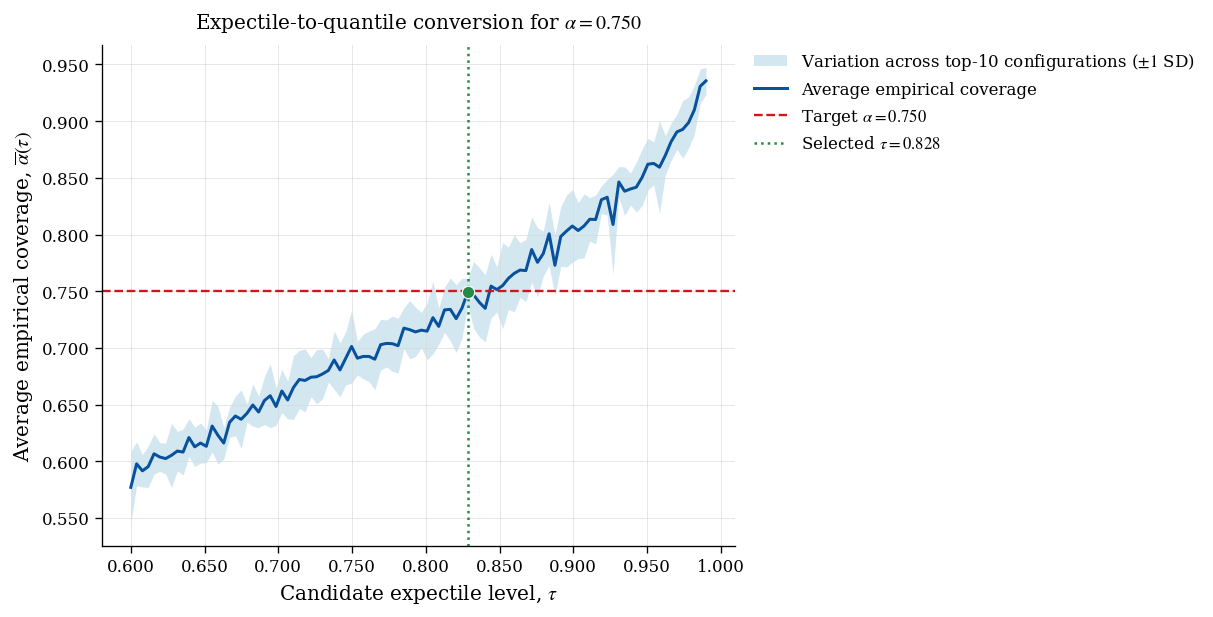


CONVERSION COMPLETED: alpha=0.750
Selected expectile tau: 0.82848485
Average coverage: 0.74944812
Absolute coverage error: 0.00055188

Plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.750_100points_paper.png

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.750_100points_summary.csv


In [53]:
# ============================================================
# PLOT 5: TARGET QUANTILE LEVEL alpha = 0.750
# ============================================================

conversion_0750 = (
    run_method3_ernn_si_conversion(
        target_alpha=0.750,
        target_level=0.750,
        reference_level=0.500,
        direction="upper",
        tau_lower=0.600,
        tau_upper=0.990,
        conversion_seed=2027,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)


CONVERSION FOR TARGET alpha=0.950
Candidate tau interval: [0.900, 0.999]
Tau points: 100
Architectures: 10
Total required refits: 1000

Tau 1/100: 0.900000
  Trial 181: coverage=0.726269
  Saved progress: 1/1000
  Trial 112: coverage=0.838852
  Saved progress: 2/1000
  Trial 183: coverage=0.792494
  Saved progress: 3/1000
  Trial 56: coverage=0.792494
  Saved progress: 4/1000
  Trial 131: coverage=0.701987
  Saved progress: 5/1000
  Trial 135: coverage=0.816777
  Saved progress: 6/1000
  Trial 133: coverage=0.677704
  Saved progress: 7/1000
  Trial 175: coverage=0.779249
  Saved progress: 8/1000
  Trial 55: coverage=0.801324
  Saved progress: 9/1000
  Trial 61: coverage=0.801324
  Saved progress: 10/1000

Tau 2/100: 0.901000
  Trial 181: coverage=0.807947
  Saved progress: 11/1000
  Trial 112: coverage=0.677704
  Saved progress: 12/1000
  Trial 183: coverage=0.830022
  Saved progress: 13/1000
  Trial 56: coverage=0.794702
  Saved progress: 14/1000
  Trial 131: coverage=0.779249
  Save

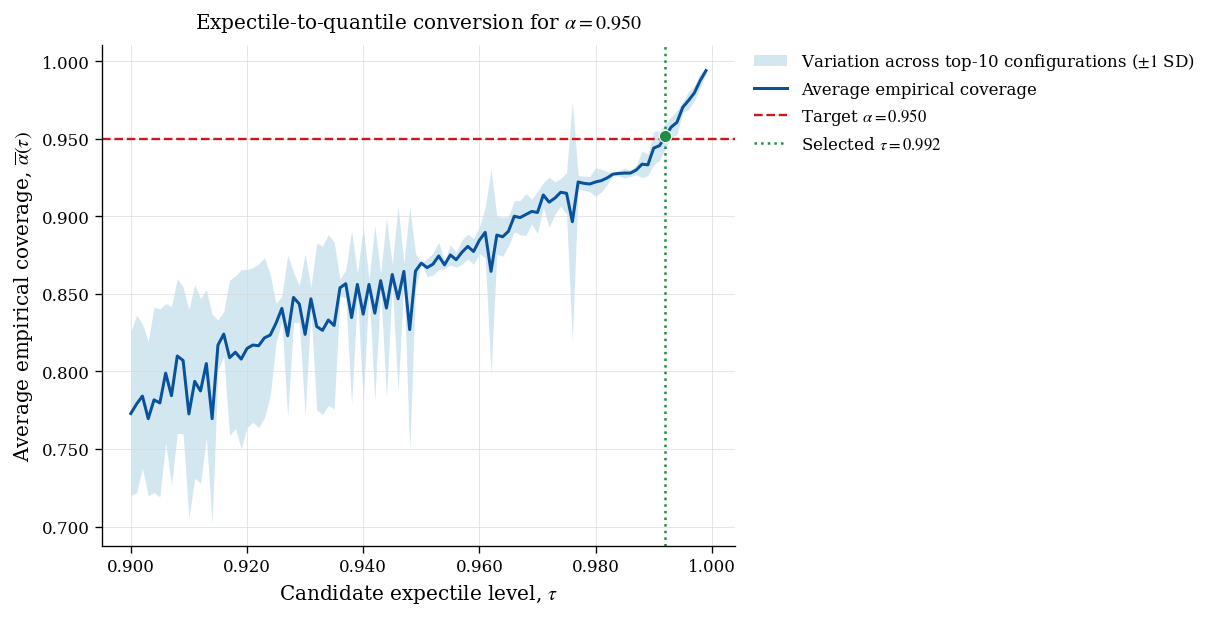


CONVERSION COMPLETED: alpha=0.950
Selected expectile tau: 0.99200000
Average coverage: 0.95143487
Absolute coverage error: 0.00143487

Plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.950_100points_paper.png

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.950_100points_summary.csv


In [55]:
# ============================================================
# PLOT 6: TARGET QUANTILE LEVEL alpha = 0.950
#
# e_0.950 = e_0.750 + positive spacing
# ============================================================

conversion_0950 = (
    run_method3_ernn_si_conversion(
        target_alpha=0.950,
        target_level=0.950,
        reference_level=0.750,
        direction="upper",
        tau_lower=0.900,
        tau_upper=0.999,
        conversion_seed=2028,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)


CONVERSION FOR TARGET alpha=0.975
Candidate tau interval: [0.950, 0.999]
Tau points: 100
Architectures: 10
Total required refits: 1000

Tau 1/100: 0.950000
  Trial 197: coverage=0.869757
  Saved progress: 1/1000
  Trial 133: coverage=0.869757
  Saved progress: 2/1000
  Trial 199: coverage=0.869757
  Saved progress: 3/1000
  Trial 105: coverage=0.869757
  Saved progress: 4/1000
  Trial 188: coverage=0.869757
  Saved progress: 5/1000
  Trial 187: coverage=0.869757
  Saved progress: 6/1000
  Trial 191: coverage=0.869757
  Saved progress: 7/1000
  Trial 120: coverage=0.869757
  Saved progress: 8/1000
  Trial 154: coverage=0.869757
  Saved progress: 9/1000
  Trial 124: coverage=0.869757
  Saved progress: 10/1000

Tau 2/100: 0.950495
  Trial 197: coverage=0.869757
  Saved progress: 11/1000
  Trial 133: coverage=0.869757
  Saved progress: 12/1000
  Trial 199: coverage=0.869757
  Saved progress: 13/1000
  Trial 105: coverage=0.869757
  Saved progress: 14/1000
  Trial 188: coverage=0.869757
  

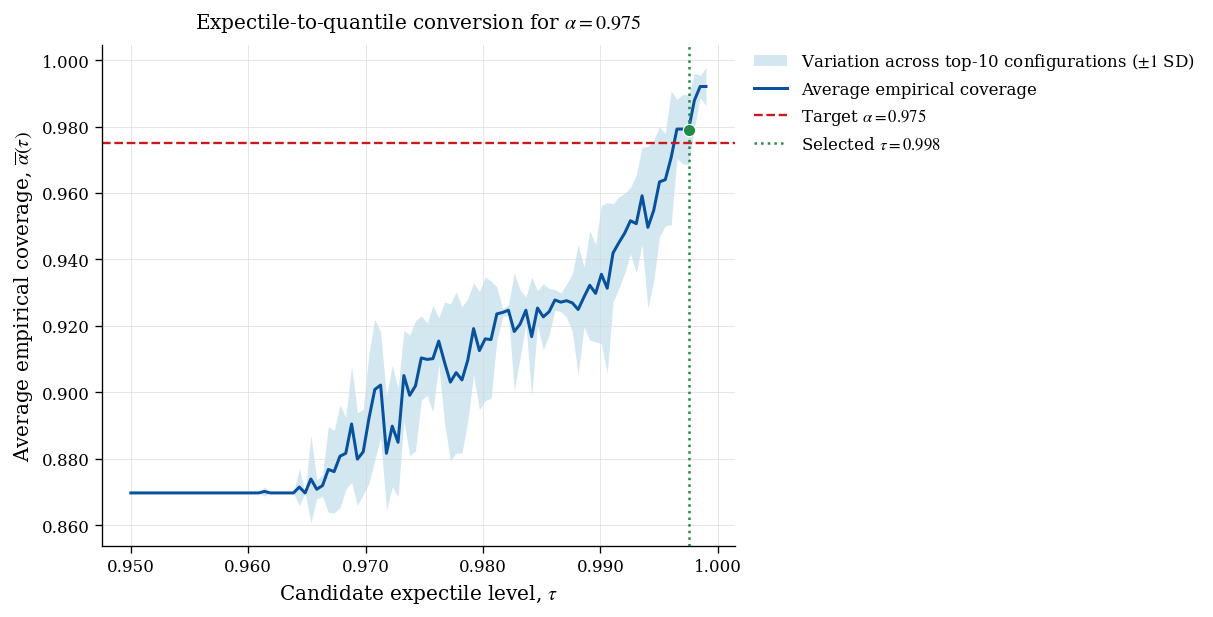


CONVERSION COMPLETED: alpha=0.975
Selected expectile tau: 0.99751515
Average coverage: 0.97902869
Absolute coverage error: 0.00402869

Plot saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.975_100points_paper.png

Summary saved to:
method3_spacing_ernn_si_self_results/ernn_si_self/conversion/conversion_alpha_0.975_100points_summary.csv


In [56]:
# ============================================================
# PLOT 7: TARGET QUANTILE LEVEL alpha = 0.975
#
# e_0.975 = e_0.950 + positive spacing
# ============================================================

conversion_0975 = (
    run_method3_ernn_si_conversion(
        target_alpha=0.975,
        target_level=0.975,
        reference_level=0.950,
        direction="upper",
        tau_lower=0.950,
        tau_upper=0.999,
        conversion_seed=2029,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)

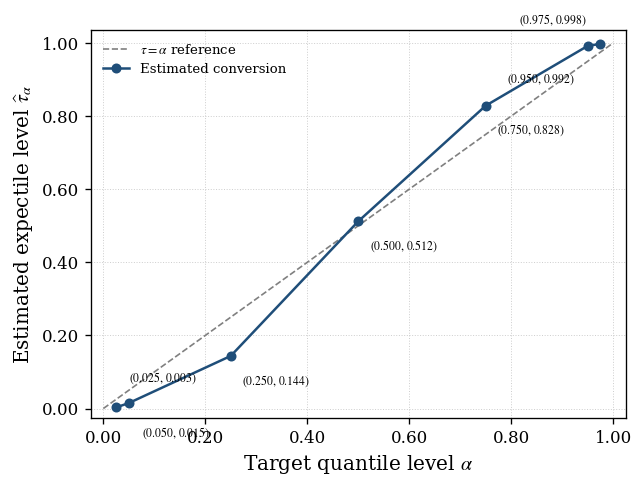

Plot saved to: expectile_quantile_conversion_summary.png


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

alpha = np.array([
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
])

tau_hat = np.array([
    0.002980, 0.015000, 0.143939, 0.512121,
    0.828485, 0.992000, 0.997515
])

fig, ax = plt.subplots(figsize=(5.5, 4.2))

# 45-degree reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.0,
    color="grey",
    label=r"$\tau=\alpha$ reference"
)

# Estimated conversion
ax.plot(
    alpha,
    tau_hat,
    marker="o",
    markersize=5,
    linewidth=1.5,
    color="#1f4e79",
    label="Estimated conversion"
)

# Separate annotation positions to prevent overlap
annotation_settings = {
    0.025: {
        "offset": (8, 13),
        "ha": "left",
        "va": "bottom"
    },
    0.050: {
        "offset": (8, -13),
        "ha": "left",
        "va": "top"
    },
    0.250: {
        "offset": (7, -10),
        "ha": "left",
        "va": "top"
    },
    0.500: {
        "offset": (7, -10),
        "ha": "left",
        "va": "top"
    },
    0.750: {
        "offset": (7, -10),
        "ha": "left",
        "va": "top"
    },
    0.950: {
        "offset": (-8, -15),
        "ha": "right",
        "va": "top"
    },
    0.975: {
        "offset": (-8, 10),
        "ha": "right",
        "va": "bottom"
    }
}

for a, t in zip(alpha, tau_hat):
    settings = annotation_settings[a]

    ax.annotate(
        rf"$({a:.3f},\,{t:.3f})$",
        xy=(a, t),
        xytext=settings["offset"],
        textcoords="offset points",
        horizontalalignment=settings["ha"],
        verticalalignment=settings["va"],
        fontsize=7
    )

ax.set_xlabel(r"Target quantile level $\alpha$")
ax.set_ylabel(
    r"Estimated expectile level $\widehat{\tau}_{\alpha}$"
)

# Add space around tail observations
ax.set_xlim(-0.025, 1.025)
ax.set_ylim(-0.025, 1.035)

ax.xaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)
ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left"
)

fig.tight_layout()

output_path = (
    "expectile_quantile_conversion_summary.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Plot saved to: {output_path}")

# Conversion - Method1b

In [17]:
# ============================================================
# LOAD METHOD 1B ERNN SI-SELF DEFINITIONS
# WITHOUT RERUNNING OPTUNA
# ============================================================

from pathlib import Path
import json

NOTEBOOK_PATH = Path(
    "20260706 - ERNN Hybrid - SI self lagged.ipynb"
)

if not NOTEBOOK_PATH.exists():
    raise FileNotFoundError(
        f"Notebook not found:\n{NOTEBOOK_PATH.resolve()}"
    )

with open(
    NOTEBOOK_PATH,
    "r",
    encoding="utf-8",
) as notebook_file:
    notebook_content = json.load(
        notebook_file
    )

method1b_source = None

for cell in notebook_content["cells"]:
    source = "".join(
        cell.get("source", [])
    )

    if (
        "class Method1BJointHybrid"
        in source
        and "def m1b_fit" in source
        and "def m1b_joint_nll" in source
    ):
        method1b_source = source
        break

if method1b_source is None:
    raise RuntimeError(
        "The Method 1b SI-self definition "
        "cell could not be found."
    )

# Stop before the section that validates inputs,
# starts Optuna and reruns the complete tuning.
run_marker = "\nm1b_validate_inputs()\n"

if run_marker not in method1b_source:
    raise RuntimeError(
        "Could not identify where Method 1b tuning begins."
    )

definition_source = (
    method1b_source.split(
        run_marker,
        1,
    )[0]
)

exec(
    definition_source,
    globals(),
)

print(
    "Method 1b ERNN SI-self definitions loaded."
)

print(
    "Optuna tuning was not rerun."
)

print(
    "Class available:",
    "Method1BJointHybrid" in globals(),
)

Method 1b ERNN SI-self definitions loaded.
Optuna tuning was not rerun.
Class available: True


In [ ]:
# ============================================================
# METHOD 1B ERNN SI-SELF — COORDINATE-WISE CONVERSION
# Reusable function + first level alpha = 0.025
# ============================================================

from pathlib import Path
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. Confirm required Method 1b objects
# ------------------------------------------------------------

required_objects = [
    "Method1BJointHybrid",
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing Method 1b objects:\n"
        + ", ".join(missing_objects)
        + "\nRun the data-preparation and Method 1b "
          "definition cells first."
    )

# Ensure that the generic Method 1b class uses SI-self.
M1B_DISTRIBUTION = "ernn"
M1B_FORM = "si"
M1B_LAG = "self"

ORIGINAL_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

RANKING_PATH = Path(
    "method1b_joint_ernn_si_self_ranking.csv"
)

if not RANKING_PATH.exists():
    raise FileNotFoundError(
        f"Ranking file not found:\n{RANKING_PATH.resolve()}"
    )


# ------------------------------------------------------------
# 2. Candidate-level composite AGD loss
# ------------------------------------------------------------

def method1b_conversion_loss(
    actual,
    forecasts,
    sigma,
    candidate_levels,
):
    tau = forecasts.new_tensor(
        candidate_levels
    )

    residual = (
        actual.unsqueeze(1)
        - forecasts
    )

    weight = torch.abs(
        tau.unsqueeze(0)
        - (residual < 0).to(
            forecasts.dtype
        )
    )

    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau)
            + torch.sqrt(
                torch.pi / (1.0 - tau)
            )
        )
        - np.log(2.0)
    )

    return (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + weight
        * residual.square()
        / sigma.square().unsqueeze(0)
    ).mean()


# ------------------------------------------------------------
# 3. Reconstruct configurations from the ranking CSV
# ------------------------------------------------------------

def method1b_boolean(value):
    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return (
        str(value).lower()
        in {"true", "1", "yes"}
    )


def method1b_config_from_row(row):
    number_of_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": number_of_layers,
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": method1b_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(row["lr"]),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        number_of_layers
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = int(
            row[
                f"hidden_dim_{layer_index}"
            ]
        )

    return config


ranking_si_self = (
    pd.read_csv(RANKING_PATH)
    .sort_values(
        [
            "sum_rank",
            "mean_nll",
            "mean_ase",
            "trial",
        ]
    )
    .reset_index(drop=True)
)

top10_si_self = (
    ranking_si_self
    .head(10)
    .copy()
)

top10_configs_si_self = [
    method1b_config_from_row(row)
    for _, row
    in top10_si_self.iterrows()
]

top10_trials_si_self = (
    top10_si_self[
        "trial"
    ]
    .astype(int)
    .tolist()
)

print(
    "Top-10 Method 1b SI-self trials:",
    top10_trials_si_self,
)


# ------------------------------------------------------------
# 4. Fit one joint model at one candidate tau
# ------------------------------------------------------------

def fit_method1b_si_self_conversion(
    config,
    candidate_levels,
    seed,
    max_epochs=800,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = Method1BJointHybrid(
        input_dim=X_train.shape[1],
        config=config,
    )

    optimizer_class = (
        torch.optim.Adam
        if config["optimizer"] == "adam"
        else torch.optim.AdamW
    )

    optimizer = optimizer_class(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config[
            "weight_decay"
        ],
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=10,
            factor=0.5,
            min_lr=1e-6,
        )
    )

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            train_forecasts,
            train_sigma,
            _,
            _,
            _,
            _,
        ) = model(
            y_train,
            X_train,
        )

        train_loss = (
            method1b_conversion_loss(
                actual=y_train[1:],
                forecasts=(
                    train_forecasts[1:]
                ),
                sigma=train_sigma,
                candidate_levels=(
                    candidate_levels
                ),
            )
        )

        if not torch.isfinite(
            train_loss
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clip"],
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                _,
                _,
                train_state,
                _,
                _,
                _,
            ) = model(
                y_train,
                X_train,
            )

            (
                validation_forecasts,
                validation_sigma,
                _,
                _,
                _,
                _,
            ) = model(
                y_val,
                X_val,
                initial_state=(
                    train_state[-1]
                ),
                initial_y=y_train[-1],
            )

            validation_loss = (
                method1b_conversion_loss(
                    actual=y_val,
                    forecasts=(
                        validation_forecasts
                    ),
                    sigma=(
                        validation_sigma
                    ),
                    candidate_levels=(
                        candidate_levels
                    ),
                )
            )

        if not torch.isfinite(
            validation_loss
        ):
            return None

        validation_value = (
            validation_loss.item()
        )

        scheduler.step(
            validation_value
        )

        if (
            validation_value
            < best_loss
        ):
            best_loss = (
                validation_value
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config["patience"]
            ):
                break

    if best_state is None:
        return None

    model.load_state_dict(
        best_state
    )

    return model


# ------------------------------------------------------------
# 5. Reusable coordinate-wise conversion function
# ------------------------------------------------------------

def run_method1b_ernn_si_self_conversion(
    target_alpha,
    target_index,
    tau_lower,
    tau_upper,
    number_of_tau_points=100,
    number_of_architectures=10,
    base_seed=2026,
    max_epochs=800,
):
    if not (
        0 <= target_index
        < len(ORIGINAL_LEVELS)
    ):
        raise ValueError(
            "target_index must be between 0 and 6."
        )

    tau_grid = np.linspace(
        tau_lower,
        tau_upper,
        number_of_tau_points,
    )

    # Check that every candidate preserves
    # the ordering of the fixed loss levels.
    if target_index > 0:
        lower_neighbour = (
            ORIGINAL_LEVELS[
                target_index - 1
            ]
        )

        if tau_grid.min() <= lower_neighbour:
            raise ValueError(
                "Candidate tau values must remain "
                "above the lower fixed neighbour."
            )

    if (
        target_index
        < len(ORIGINAL_LEVELS) - 1
    ):
        upper_neighbour = (
            ORIGINAL_LEVELS[
                target_index + 1
            ]
        )

        if tau_grid.max() >= upper_neighbour:
            raise ValueError(
                "Candidate tau values must remain "
                "below the upper fixed neighbour."
            )

    level_label = (
        f"{target_alpha:.3f}"
    )

    output_directory = (
        Path(
            "method1b_joint_ernn_si_self_conversion"
        )
        / f"alpha_{level_label}"
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    raw_path = (
        output_directory
        / (
            f"conversion_alpha_"
            f"{level_label}_raw.csv"
        )
    )

    summary_path = (
        output_directory
        / (
            f"conversion_alpha_"
            f"{level_label}_summary.csv"
        )
    )

    estimated_path = (
        output_directory
        / (
            f"conversion_alpha_"
            f"{level_label}_estimated_tau.csv"
        )
    )

    plot_path = (
        output_directory
        / (
            f"conversion_alpha_"
            f"{level_label}.png"
        )
    )

    if raw_path.exists():
        raw_results = pd.read_csv(
            raw_path
        )
    else:
        raw_results = pd.DataFrame(
            columns=[
                "target_alpha",
                "candidate_tau",
                "architecture_rank",
                "original_trial",
                "coverage",
                "minimum_spacing",
            ]
        )

    def already_completed(
        candidate_tau,
        architecture_rank,
    ):
        if raw_results.empty:
            return False

        return bool(
            (
                np.isclose(
                    raw_results[
                        "candidate_tau"
                    ].astype(float),
                    float(candidate_tau),
                    atol=1e-12,
                )
                & (
                    raw_results[
                        "architecture_rank"
                    ].astype(int)
                    == architecture_rank
                )
            ).any()
        )

    for tau_number, candidate_tau in enumerate(
        tau_grid,
        start=1,
    ):
        candidate_levels = (
            ORIGINAL_LEVELS.copy()
        )

        candidate_levels[
            target_index
        ] = float(candidate_tau)

        print(
            f"\nTau point "
            f"{tau_number}/"
            f"{len(tau_grid)}: "
            f"{candidate_tau:.6f}"
        )

        for architecture_rank in range(
            1,
            number_of_architectures + 1,
        ):
            if already_completed(
                candidate_tau,
                architecture_rank,
            ):
                continue

            model = (
                fit_method1b_si_self_conversion(
                    config=(
                        top10_configs_si_self[
                            architecture_rank - 1
                        ]
                    ),
                    candidate_levels=(
                        candidate_levels
                    ),
                    seed=(
                        base_seed
                        + architecture_rank
                    ),
                    max_epochs=max_epochs,
                )
            )

            if model is None:
                print(
                    f"  Architecture "
                    f"{architecture_rank}: failed"
                )
                continue

            model.eval()

            with torch.no_grad():
                (
                    _,
                    _,
                    train_state,
                    _,
                    _,
                    _,
                ) = model(
                    y_train,
                    X_train,
                )

                (
                    validation_forecasts,
                    _,
                    _,
                    _,
                    _,
                    validation_spacings,
                ) = model(
                    y_val,
                    X_val,
                    initial_state=(
                        train_state[-1]
                    ),
                    initial_y=y_train[-1],
                )

            target_forecast = (
                validation_forecasts[
                    :,
                    target_index
                ]
            )

            coverage = (
                y_val
                < target_forecast
            ).float().mean().item()

            new_result = pd.DataFrame([
                {
                    "target_alpha": (
                        target_alpha
                    ),
                    "candidate_tau": (
                        candidate_tau
                    ),
                    "architecture_rank": (
                        architecture_rank
                    ),
                    "original_trial": (
                        top10_trials_si_self[
                            architecture_rank - 1
                        ]
                    ),
                    "coverage": coverage,
                    "minimum_spacing": (
                        validation_spacings
                        .min()
                        .item()
                    ),
                }
            ])

            raw_results = pd.concat(
                [
                    raw_results,
                    new_result,
                ],
                ignore_index=True,
            )

            raw_results.to_csv(
                raw_path,
                index=False,
            )

            print(
                f"  Architecture "
                f"{architecture_rank}/"
                f"{number_of_architectures}: "
                f"coverage={coverage:.4f}"
            )

    # Require all ten architectures at every point.
    completed = (
        raw_results
        .groupby(
            "candidate_tau"
        )[
            "architecture_rank"
        ]
        .nunique()
    )

    if (
        len(completed)
        < number_of_tau_points
        or (
            completed
            < number_of_architectures
        ).any()
    ):
        raise RuntimeError(
            "Some fits remain incomplete. "
            "Rerun this cell to retry them."
        )

    summary = (
        raw_results
        .groupby(
            "candidate_tau",
            as_index=False,
        )
        .agg(
            mean_coverage=(
                "coverage",
                "mean",
            ),
            sd_coverage=(
                "coverage",
                "std",
            ),
            minimum_coverage=(
                "coverage",
                "min",
            ),
            maximum_coverage=(
                "coverage",
                "max",
            ),
            minimum_spacing=(
                "minimum_spacing",
                "min",
            ),
        )
        .sort_values(
            "candidate_tau"
        )
        .reset_index(drop=True)
    )

    summary[
        "absolute_error"
    ] = np.abs(
        summary[
            "mean_coverage"
        ]
        - target_alpha
    )

    selected = (
        summary
        .sort_values(
            [
                "absolute_error",
                "candidate_tau",
            ]
        )
        .iloc[0]
    )

    estimated_tau = float(
        selected[
            "candidate_tau"
        ]
    )

    estimated_coverage = float(
        selected[
            "mean_coverage"
        ]
    )

    summary.to_csv(
        summary_path,
        index=False,
    )

    estimated_result = pd.DataFrame([
        {
            "target_alpha": (
                target_alpha
            ),
            "estimated_tau": (
                estimated_tau
            ),
            "estimated_coverage": (
                estimated_coverage
            ),
            "absolute_error": abs(
                estimated_coverage
                - target_alpha
            ),
        }
    ])

    estimated_result.to_csv(
        estimated_path,
        index=False,
    )

    # Plot
    x = summary[
        "candidate_tau"
    ].to_numpy()

    y = summary[
        "mean_coverage"
    ].to_numpy()

    y_sd = (
        summary[
            "sd_coverage"
        ]
        .fillna(0)
        .to_numpy()
    )

    fig, ax = plt.subplots(
        figsize=(6.5, 4.3)
    )

    ax.fill_between(
        x,
        y - y_sd,
        y + y_sd,
        color="#4C78A8",
        alpha=0.18,
        label=(
            "Top-10 architectures "
            "($\\pm1$ SD)"
        ),
    )

    ax.plot(
        x,
        y,
        color="#1f4e79",
        marker="o",
        markersize=2.5,
        linewidth=1.4,
        label="Mean conversion curve",
    )

    ax.axhline(
        target_alpha,
        color="#C44E52",
        linestyle="--",
        linewidth=1.0,
        label=(
            rf"Target $\alpha="
            rf"{target_alpha:.3f}$"
        ),
    )

    ax.axvline(
        estimated_tau,
        color="#55A868",
        linestyle=":",
        linewidth=1.1,
        label=(
            rf"$\widehat{{\tau}}="
            rf"{estimated_tau:.3f}$"
        ),
    )

    ax.set_xlabel(
        r"Candidate expectile level $\tau$"
    )

    ax.set_ylabel(
        r"Empirical coverage "
        r"$\widehat{\alpha}(\tau)$"
    )

    ax.set_title(
        "Method 1b Hybrid ERNN SI-self\n"
        rf"Target $\alpha={target_alpha:.3f}$"
    )

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.6,
        alpha=0.55,
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    fig.tight_layout()

    fig.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        "\nMethod 1b ERNN SI-self "
        "conversion completed."
    )

    print(
        f"Target alpha: "
        f"{target_alpha:.3f}"
    )

    print(
        f"Estimated tau: "
        f"{estimated_tau:.6f}"
    )

    print(
        f"Estimated coverage: "
        f"{estimated_coverage:.6f}"
    )

    print(
        f"Plot saved to:\n"
        f"{plot_path}"
    )

    return {
        "raw": raw_results,
        "summary": summary,
        "estimated": estimated_result,
        "plot_path": plot_path,
    }


# ------------------------------------------------------------
# 6. Run the first level: alpha = 0.025
# ------------------------------------------------------------

conversion_si_self_0025 = (
    run_method1b_ernn_si_self_conversion(
        target_alpha=0.025,
        target_index=0,
        tau_lower=0.001,
        tau_upper=0.049,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)

Top-10 Method 1b SI-self trials: [728, 311, 123, 417, 518, 166, 133, 562, 633, 109]

Tau point 1/100: 0.001000


/var/folders/0k/3jhs8p2d2bdd3_fvs731s4cr0000gn/T/ipykernel_5057/2623960901.py:668: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  raw_results = pd.concat(


  Architecture 1/10: coverage=0.0132
  Architecture 2/10: coverage=0.0155
  Architecture 3/10: coverage=0.0022
  Architecture 4/10: coverage=0.0088
  Architecture 5/10: coverage=0.0000
  Architecture 6/10: coverage=0.0044
  Architecture 7/10: coverage=0.0088
  Architecture 8/10: coverage=0.0177
  Architecture 9/10: coverage=0.0088
  Architecture 10/10: coverage=0.0243

Tau point 2/100: 0.001485
  Architecture 1/10: coverage=0.0177
  Architecture 2/10: coverage=0.0177
  Architecture 3/10: coverage=0.0000
  Architecture 4/10: coverage=0.0177
  Architecture 5/10: coverage=0.0066
  Architecture 6/10: coverage=0.0132
  Architecture 7/10: coverage=0.0132
  Architecture 8/10: coverage=0.0331
  Architecture 9/10: coverage=0.0221
  Architecture 10/10: coverage=0.0132

Tau point 3/100: 0.001970
  Architecture 1/10: coverage=0.0375
  Architecture 2/10: coverage=0.0155
  Architecture 3/10: coverage=0.0199
  Architecture 4/10: coverage=0.0155
  Architecture 5/10: coverage=0.0044
  Architecture 6/10